#SETUP ENVIRONMENT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
# Setting
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#**LOAD & EXPLORE DATASETS**

##Load Semua Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import glob
import os


Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/project_ai/dataset/'

In [ ]:
df_app = pd.read_csv(f'{DATA_PATH}applications.csv')
print(f"✅ applications.csv loaded: {df_app.shape}")

# Load dataset review
df_review = pd.read_csv(f'{DATA_PATH}reviews.csv')
print(f"✅ review.csv loaded: {df_review.shape}")

# Load dataset pendukung
df_genre = pd.read_csv(f'{DATA_PATH}genres.csv')
print(f"✅ genre.csv loaded: {df_genre.shape}")

df_categories = pd.read_csv(f'{DATA_PATH}categories.csv')
print(f"✅ categories.csv loaded: {df_categories.shape}")

df_platform = pd.read_csv(f'{DATA_PATH}platforms.csv')
print(f"✅ platform.csv loaded: {df_platform.shape}")

df_developer = pd.read_csv(f'{DATA_PATH}developers.csv')
print(f"✅ developer.csv loaded: {df_developer.shape}")

df_publisher = pd.read_csv(f'{DATA_PATH}publishers.csv')
print(f"✅ publisher.csv loaded: {df_publisher.shape}")

df_app_genres = pd.read_csv(f'{DATA_PATH}application_genres.csv')
print(f"✅ application_genres.csv loaded: {df_app_genres.shape}")

df_app_categories = pd.read_csv(f'{DATA_PATH}application_categories.csv')
print(f"✅ application_categories.csv loaded: {df_app_categories.shape}")

df_app_developers = pd.read_csv(f'{DATA_PATH}application_developers.csv')
print(f"✅ application_developers.csv loaded: {df_app_developers.shape}")

✅ applications.csv loaded: (239664, 30)
✅ review.csv loaded: (1048148, 23)
✅ genre.csv loaded: (154, 2)
✅ categories.csv loaded: (462, 2)
✅ platform.csv loaded: (3, 2)
✅ developer.csv loaded: (101226, 2)
✅ publisher.csv loaded: (85699, 2)
✅ application_genres.csv loaded: (587515, 2)
✅ application_categories.csv loaded: (1077156, 2)
✅ application_developers.csv loaded: (250817, 2)


##Quick Overview - Application Dataset

In [ ]:
print(f"Total Games: {len(df_app):,}")
print(f"Total Columns: {len(df_app.columns)}")
print(f"\nColumns: {list(df_app.columns)}")

print("\n5 data pertama:")
print(df_app.head())

print("\nData Types:")
print(df_app.dtypes)

print("\nMemory Usage:")
print(df_app.memory_usage(deep=True).sum() / 1024**2, "MB")

Total Games: 239,664
Total Columns: 30

Columns: ['appid', 'name', 'type', 'is_free', 'release_date', 'required_age', 'short_description', 'supported_languages', 'header_image', 'background', 'metacritic_score', 'recommendations_total', 'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux', 'mat_initial_price', 'mat_final_price', 'mat_discount_percent', 'mat_currency', 'mat_achievement_count', 'mat_pc_os_min', 'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min', 'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec', 'mat_pc_graphics_rec', 'created_at', 'updated_at']

5 data pertama:
   appid                       name  type  is_free release_date required_age  \
0     10             Counter-Strike  game    False   2000-11-01            0   
1     20      Team Fortress Classic  game    False   1999-04-01            0   
2     30              Day of Defeat  game    False   2003-05-01            0   
3     40         Deathmatch Classic  game    False   2001

##Quick Overview - Review Dataset

In [ ]:

print(f"Total Reviews: {len(df_review):,}")
print(f"Total Columns: {len(df_review.columns)}")

print("\n5 kolom pertama:")
print(df_review.head())

print("\nUnique Apps with Reviews:")
print(f"Total Apps: {df_review['appid'].nunique():,}")

print("\nAverage Reviews per Game:")
reviews_per_app = df_review.groupby('appid').size()
print(f"Mean: {reviews_per_app.mean():.2f}")
print(f"Median: {reviews_per_app.median():.2f}")
print(f"Max: {reviews_per_app.max():,}")

Total Reviews: 1,048,148
Total Columns: 23

5 kolom pertama:
   recommendationid    appid     author_steamid  author_num_games_owned  \
0          10000000   264220  76561198085405844                     760   
1         100001066  1006440  76561198014439859                     485   
2         100002344   320721  76561198048038590                       0   
3         100002361  1604700  76561197994386273                       0   
4         100002504  1338560  76561198138996331                     816   

   author_num_reviews  author_playtime_forever  \
0                  74                     12.0   
1                 234                    424.0   
2                 385                      0.0   
3                   3                     86.0   
4                  26                     25.0   

   author_playtime_last_two_weeks  author_playtime_at_review  \
0                             0.0                       12.0   
1                             0.0                      424.

##Quick Overview - Supporting dataset

In [ ]:
supporting_dfs = {
    'Genre': df_genre,
    'Categories': df_categories,
    'Platform': df_platform,
    'Developer': df_developer,
    'Publisher': df_publisher
}

for name, df in supporting_dfs.items():
    print(f"\n{name}:")
    print(f"  Rows: {len(df):,}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Unique IDs: {df['id'].nunique():,}")
    if 'name' in df.columns:
        print(f"  Sample: {df['name'].head(3).tolist()}")


Genre:
  Rows: 154
  Columns: ['id', 'name']
  Unique IDs: 154
  Sample: ['Aventură', 'Многопользовательские игры', 'Nezávislé']

Categories:
  Rows: 462
  Columns: ['id', 'name']
  Unique IDs: 462
  Sample: ['Remote\xa0Play en móvil', 'Flera spelare', 'Tablette Remote Play']

Platform:
  Rows: 3
  Columns: ['id', 'name']
  Unique IDs: 3
  Sample: ['windows', 'mac', 'linux']

Developer:
  Rows: 101,226
  Columns: ['id', 'name']
  Unique IDs: 101,226
  Sample: ['Skala Entertainment', 'Flicksync', 'SN Mobile Technology']

Publisher:
  Rows: 85,699
  Columns: ['id', 'name']
  Unique IDs: 85,699
  Sample: ['Skala Entertainment', 'Playdigious Originals', 'SN Mobile Technology']


##Check Missing Values - Application Dataset

               Column  Missing_Count  Missing_Percent
     metacritic_score         234365        97.788988
recommendations_total         217104        90.586822
mat_achievement_count         178263        74.380383
  mat_pc_graphics_rec         147617        61.593314
    mat_pc_memory_rec         142839        59.599690
 mat_pc_processor_rec         142628        59.511650
        mat_pc_os_rec         137774        57.486314
    mat_initial_price          94741        39.530760
      mat_final_price          94741        39.530760
         mat_currency          94741        39.530760
 mat_discount_percent          94741        39.530760
  mat_pc_graphics_min          70422        29.383637
    mat_pc_memory_min          58390        24.363275
 mat_pc_processor_min          56422        23.542126
        mat_pc_os_min          43790        18.271413
         release_date          36855        15.377779
  supported_languages          17658         7.367815
    short_description       

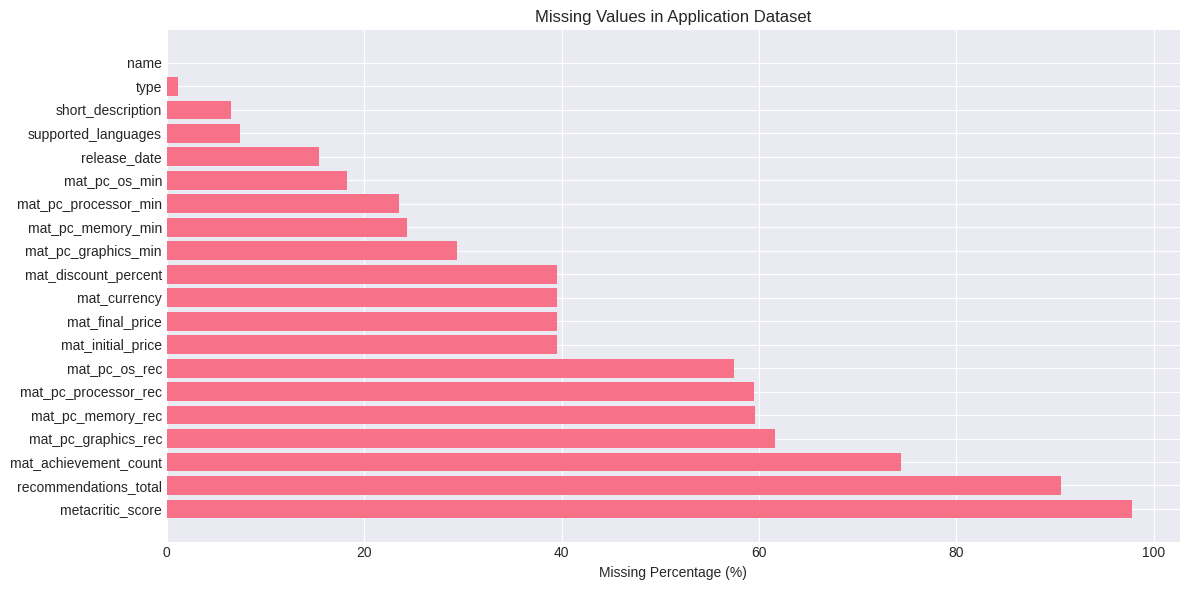

In [ ]:
missing = df_app.isnull().sum()
missing_percent = (missing / len(df_app)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print(missing_df.to_string(index=False))

# Visualisasi
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Column'], missing_df['Missing_Percent'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values in Application Dataset')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/missing_values_app.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n✅ No missing values found!")

##Check Missing Values - Review Dataset

In [ ]:
missing_review = df_review.isnull().sum()
missing_percent_review = (missing_review / len(df_review)) * 100
missing_df_review = pd.DataFrame({
    'Column': missing_review.index,
    'Missing_Count': missing_review.values,
    'Missing_Percent': missing_percent_review.values
})
missing_df_review = missing_df_review[missing_df_review['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print(missing_df_review.to_string(index=False))

                        Column  Missing_Count  Missing_Percent
     author_playtime_at_review         178857        17.064098
                   review_text            779         0.074322
       author_playtime_forever              3         0.000286
author_playtime_last_two_weeks              3         0.000286
            author_last_played              3         0.000286


##Identifikasi Primary & Foreign Key Relationships

In [ ]:
print("\nPrimary Keys:")
print(f"  - application.csv: 'appid' → {df_app['appid'].nunique():,} unique apps")
print(f"  - review.csv: 'recommendationid' → {df_review['recommendationid'].nunique():,} unique reviews")
print(f"  - genre.csv: 'id' → {df_genre['id'].nunique():,} unique genres")
print(f"  - categories.csv: 'id' → {df_categories['id'].nunique():,} unique categories")
print(f"  - platform.csv: 'id' → {df_platform['id'].nunique():,} unique platforms")
print(f"  - developer.csv: 'id' → {df_developer['id'].nunique():,} unique developers")
print(f"  - publisher.csv: 'id' → {df_publisher['id'].nunique():,} unique publishers")

print("\nForeign Key Relationships:")
print(f"  - review.appid → application.appid")
print(f"    Apps in application: {df_app['appid'].nunique():,}")
print(f"    Apps in review: {df_review['appid'].nunique():,}")
print(f"    Apps with reviews: {df_review['appid'].nunique():,} ({df_review['appid'].nunique()/df_app['appid'].nunique()*100:.1f}%)")

# Check berapa banyak game yang tidak punya review
apps_without_reviews = df_app[~df_app['appid'].isin(df_review['appid'])]
print(f"\n Apps without any reviews: {len(apps_without_reviews):,} ({len(apps_without_reviews)/len(df_app)*100:.1f}%)")


Primary Keys:
  - application.csv: 'appid' → 239,664 unique apps
  - review.csv: 'recommendationid' → 1,048,148 unique reviews
  - genre.csv: 'id' → 154 unique genres
  - categories.csv: 'id' → 462 unique categories
  - platform.csv: 'id' → 3 unique platforms
  - developer.csv: 'id' → 101,226 unique developers
  - publisher.csv: 'id' → 85,699 unique publishers

Foreign Key Relationships:
  - review.appid → application.appid
    Apps in application: 239,664
    Apps in review: 117,311
    Apps with reviews: 117,311 (48.9%)

 Apps without any reviews: 122,353 (51.1%)


#**EXPLORATORY DATA ANALYSIS (EDA)**

##Analisis Distribusi - Type Game

type
game     150279
dlc       53792
demo      23521
music      8713
video       692
Name: count, dtype: int64


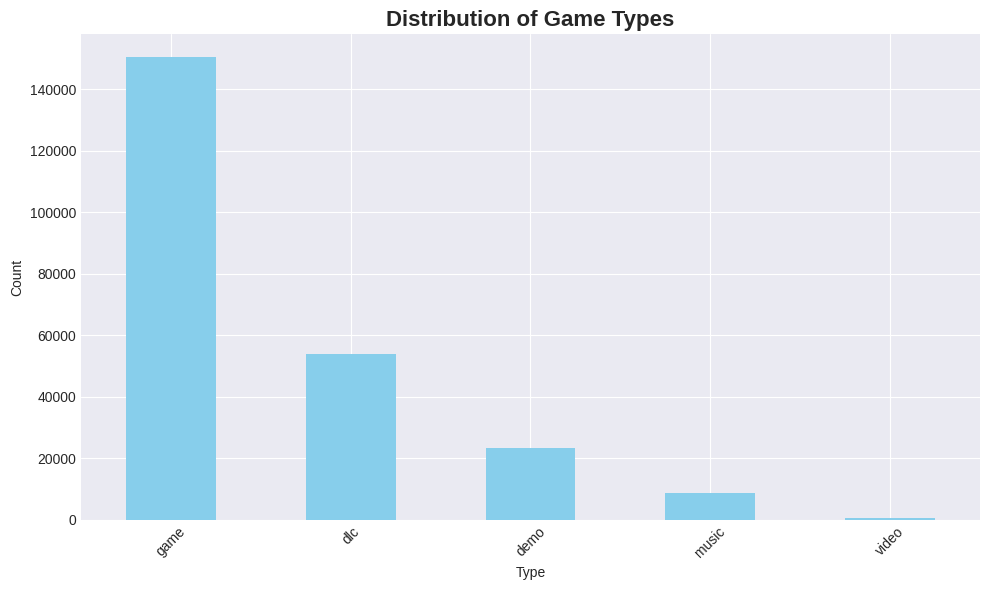


💡 Insight: Mayoritas adalah 'game' (150,279 items)


In [ ]:
if 'type' in df_app.columns:
    type_dist = df_app['type'].value_counts()
    print(type_dist)

    plt.figure(figsize=(10, 6))
    type_dist.plot(kind='bar', color='skyblue')
    plt.title('Distribution of Game Types', fontsize=16, fontweight='bold')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/type_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💡 Insight: Mayoritas adalah '{type_dist.index[0]}' ({type_dist.values[0]:,} items)")

##Analisis Distribusi - Is Free

is_free
False    191390
True      48274
Name: count, dtype: int64


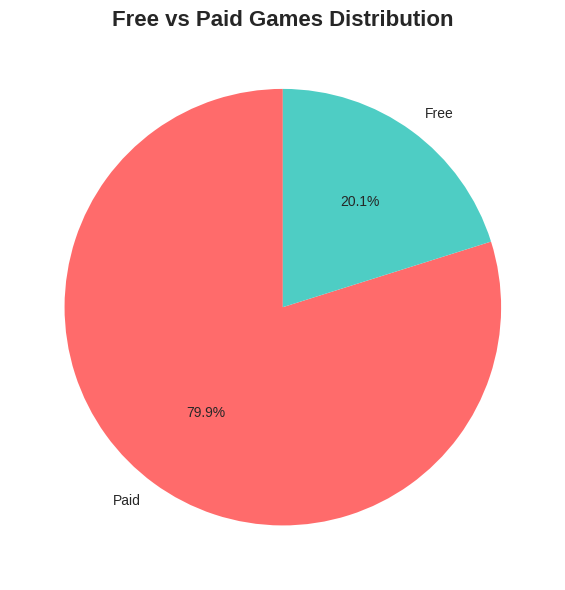

In [ ]:
if 'is_free' in df_app.columns:
    free_dist = df_app['is_free'].value_counts()
    print(free_dist)

    plt.figure(figsize=(8, 6))
    labels = ['Paid', 'Free'] if free_dist.index[0] == False else ['Free', 'Paid']
    colors = ['#FF6B6B', '#4ECDC4']
    plt.pie(free_dist.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Free vs Paid Games Distribution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/free_vs_paid.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Distribusi - Harga (Price)

Total Paid Games: 144,923

Price Statistics:
count    1.449230e+05
mean     2.064869e+04
std      7.796022e+05
min      4.400000e+01
25%      2.990000e+02
50%      4.990000e+02
75%      9.990000e+02
max      8.910000e+07
Name: mat_final_price, dtype: float64

Outlier Analysis:
Max price: $89,100,000.00
99th percentile: $5,999.00
95th percentile: $2,499.00

Games priced > $1000: 31,996 (22.08%)


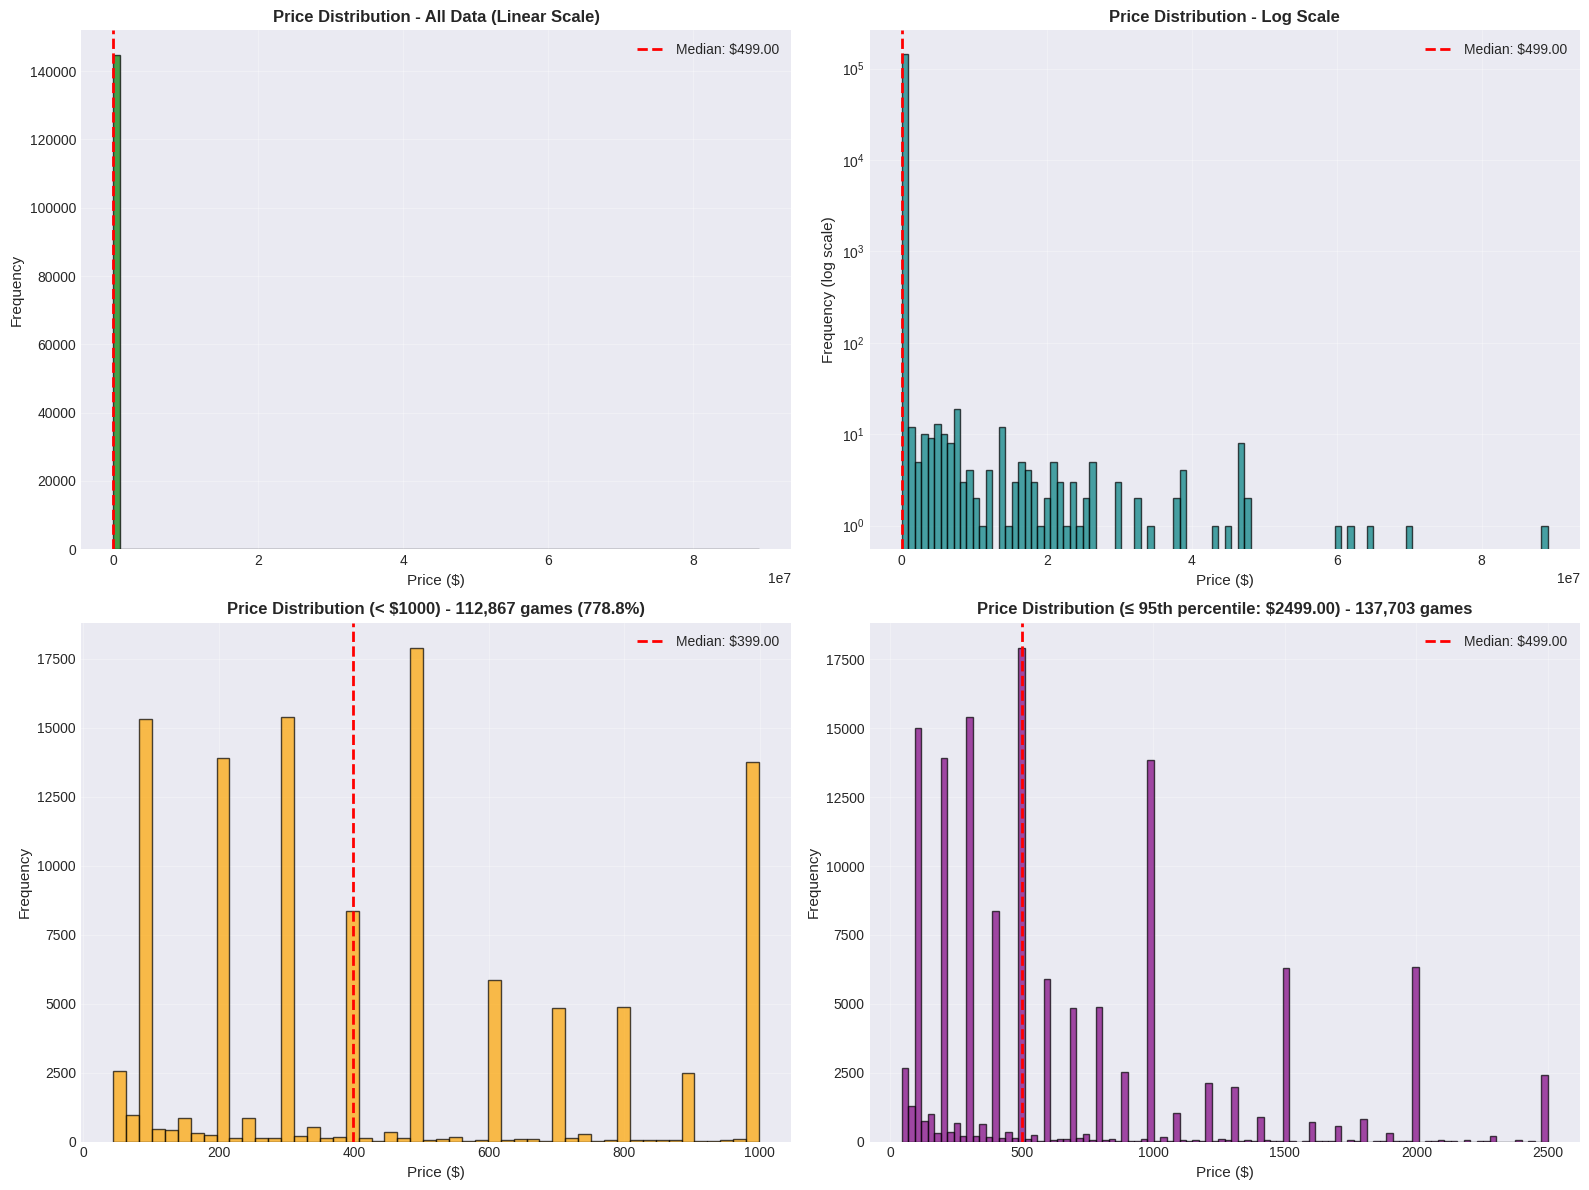

In [ ]:
if 'mat_final_price' in df_app.columns:
    paid_games = df_app[df_app['mat_final_price'] > 0]

    print(f"Total Paid Games: {len(paid_games):,}")
    print(f"\nPrice Statistics:")
    print(paid_games['mat_final_price'].describe())

    # Identifikasi outliers
    print(f"\nOutlier Analysis:")
    print(f"Max price: ${paid_games['mat_final_price'].max():,.2f}")
    print(f"99th percentile: ${paid_games['mat_final_price'].quantile(0.99):,.2f}")
    print(f"95th percentile: ${paid_games['mat_final_price'].quantile(0.95):,.2f}")

    # Hitung game di atas $1000
    expensive_games = paid_games[paid_games['mat_final_price'] > 1000]
    print(f"\nGames priced > $1000: {len(expensive_games):,} ({len(expensive_games)/len(paid_games)*100:.2f}%)")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Full Distribution (dengan log scale)
    axes[0, 0].hist(paid_games['mat_final_price'], bins=100, color='green', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Price ($)', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Price Distribution - All Data (Linear Scale)', fontsize=12, fontweight='bold')
    axes[0, 0].axvline(paid_games['mat_final_price'].median(), color='red', linestyle='--',
                       linewidth=2, label=f'Median: ${paid_games["mat_final_price"].median():.2f}')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # Log Scale Distribution (untuk melihat semua range)
    axes[0, 1].hist(paid_games['mat_final_price'], bins=100, color='teal', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Price ($)', fontsize=11)
    axes[0, 1].set_ylabel('Frequency (log scale)', fontsize=11)
    axes[0, 1].set_title('Price Distribution - Log Scale', fontsize=12, fontweight='bold')
    axes[0, 1].set_yscale('log')
    axes[0, 1].axvline(paid_games['mat_final_price'].median(), color='red', linestyle='--',
                       linewidth=2, label=f'Median: ${paid_games["mat_final_price"].median():.2f}')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)

    # Filtered < $100 (Detail untuk mayoritas game)
    price_under_100 = paid_games[paid_games['mat_final_price'] < 1000]
    axes[1, 0].hist(price_under_100['mat_final_price'], bins=50, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Price ($)', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title(f'Price Distribution (< $1000) - {len(price_under_100):,} games ({len(price_under_100)/len(paid_games)*1000:.1f}%)',
                         fontsize=12, fontweight='bold')
    axes[1, 0].axvline(price_under_100['mat_final_price'].median(), color='red', linestyle='--',
                       linewidth=2, label=f'Median: ${price_under_100["mat_final_price"].median():.2f}')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)

    # Filtered 95th percentile (Menghilangkan top 5% outliers)
    percentile_95 = paid_games['mat_final_price'].quantile(0.95)
    price_95th = paid_games[paid_games['mat_final_price'] <= percentile_95]
    axes[1, 1].hist(price_95th['mat_final_price'], bins=100, color='purple', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Price ($)', fontsize=11)
    axes[1, 1].set_ylabel('Frequency', fontsize=11)
    axes[1, 1].set_title(f'Price Distribution (≤ 95th percentile: ${percentile_95:.2f}) - {len(price_95th):,} games',
                         fontsize=12, fontweight='bold')
    axes[1, 1].axvline(price_95th['mat_final_price'].median(), color='red', linestyle='--',
                       linewidth=2, label=f'Median: ${price_95th["mat_final_price"].median():.2f}')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/price_distribution_detailed.png',
                dpi=300, bbox_inches='tight')
    plt.show()


##Analisis Distribusi - Metacritic Score

Games with Metacritic Score: 5,299 (2.2%)

Metacritic Score Statistics:
count    5299.000000
mean       74.052651
std        10.299116
min         6.000000
25%        69.000000
50%        76.000000
75%        81.000000
max        97.000000
Name: metacritic_score, dtype: float64


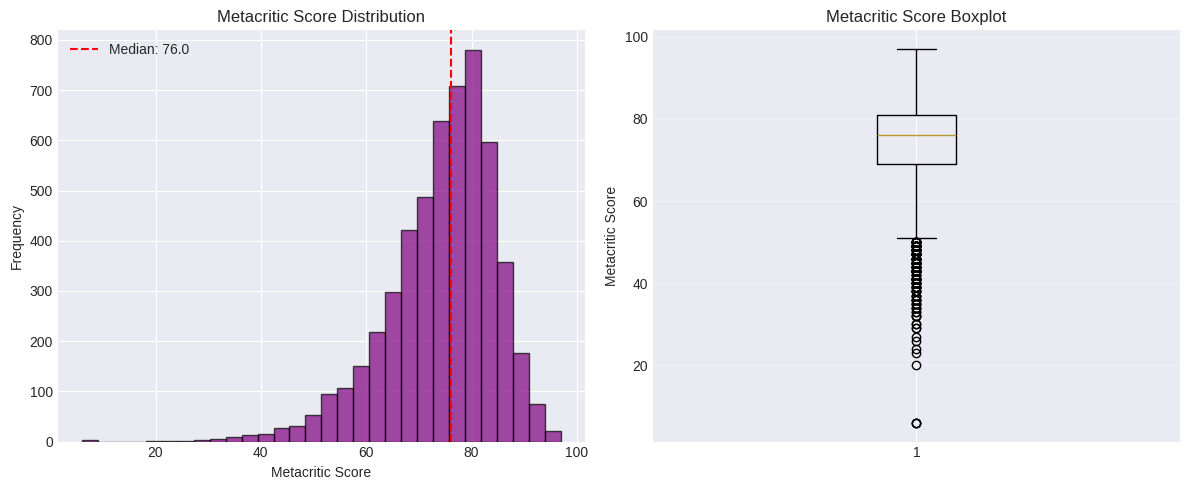

In [ ]:
if 'metacritic_score' in df_app.columns:
    metacritic_data = df_app[df_app['metacritic_score'].notna()]

    print(f"Games with Metacritic Score: {len(metacritic_data):,} ({len(metacritic_data)/len(df_app)*100:.1f}%)")
    print(f"\nMetacritic Score Statistics:")
    print(metacritic_data['metacritic_score'].describe())

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(metacritic_data['metacritic_score'], bins=30, color='purple', alpha=0.7, edgecolor='black')
    plt.xlabel('Metacritic Score')
    plt.ylabel('Frequency')
    plt.title('Metacritic Score Distribution')
    plt.axvline(metacritic_data['metacritic_score'].median(), color='red', linestyle='--', label=f'Median: {metacritic_data["metacritic_score"].median():.1f}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.boxplot(metacritic_data['metacritic_score'], vert=True)
    plt.ylabel('Metacritic Score')
    plt.title('Metacritic Score Boxplot')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/metacritic_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Distribusi - Recommendations Total

Games with Recommendations: 22,560

Recommendations Statistics:
count    2.256000e+04
mean     4.648429e+03
std      4.642273e+04
min      1.010000e+02
25%      1.740000e+02
50%      3.690000e+02
75%      1.205250e+03
max      4.661011e+06
Name: recommendations_total, dtype: float64


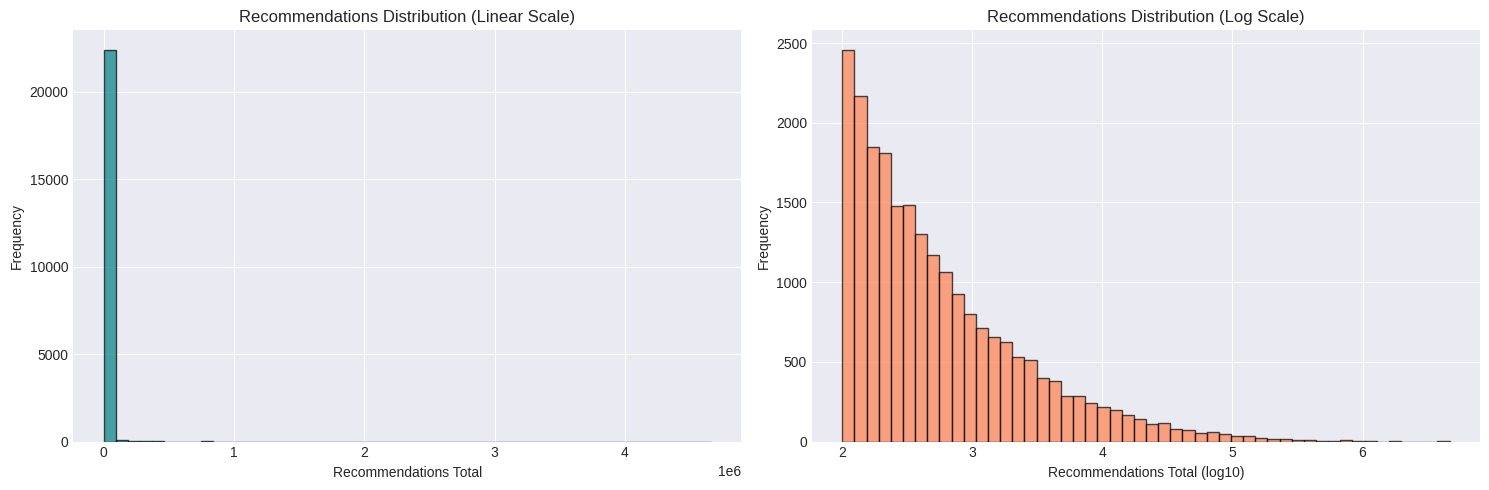


Top 10 Most Recommended Games:
                             name  recommendations_total
                 Counter-Strike 2              4661011.0
        Grand Theft Auto V Legacy              1835735.0
              PUBG: BATTLEGROUNDS              1746923.0
Tom Clancy's Rainbow Six® Siege X              1213861.0
                         Terraria              1143314.0
                             Rust              1043371.0
                      Garry's Mod              1013561.0
               Black Myth: Wukong               855328.0
                 Wallpaper Engine               852300.0
                   Stardew Valley               790798.0


In [ ]:
if 'recommendations_total' in df_app.columns:
    rec_data = df_app[df_app['recommendations_total'].notna()]

    print(f"Games with Recommendations: {len(rec_data):,}")
    print(f"\nRecommendations Statistics:")
    print(rec_data['recommendations_total'].describe())

    # Karena data sangat skewed, gunakan log scale
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Original scale
    axes[0].hist(rec_data['recommendations_total'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Recommendations Total')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Recommendations Distribution (Linear Scale)')

    # Log scale
    rec_filtered = rec_data[rec_data['recommendations_total'] > 0]
    axes[1].hist(np.log10(rec_filtered['recommendations_total']), bins=50, color='coral', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Recommendations Total (log10)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Recommendations Distribution (Log Scale)')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/recommendations_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nTop 10 Most Recommended Games:")
    top_recommended = df_app.nlargest(10, 'recommendations_total')[['name', 'recommendations_total']]
    print(top_recommended.to_string(index=False))

##Analisis Distribusi - Achievement Count

Games with Achievements: 61,401 (25.6%)

Achievement Count Statistics:
count    61401.000000
mean        34.411215
std        197.958850
min          0.000000
25%          9.000000
50%         17.000000
75%         31.000000
max       9821.000000
Name: mat_achievement_count, dtype: float64


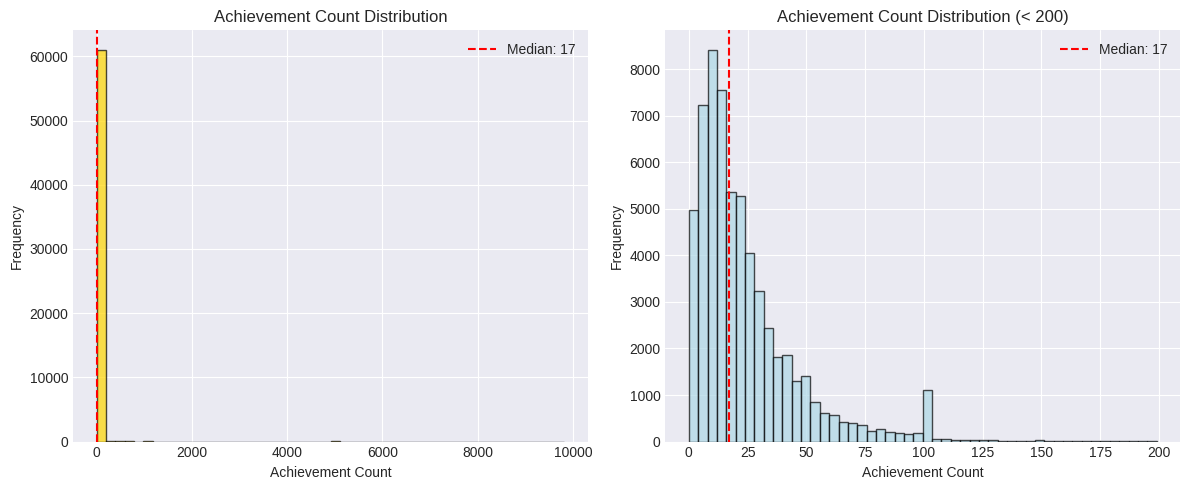

In [ ]:
if 'mat_achievement_count' in df_app.columns:
    ach_data = df_app[df_app['mat_achievement_count'].notna()]

    print(f"Games with Achievements: {len(ach_data):,} ({len(ach_data)/len(df_app)*100:.1f}%)")
    print(f"\nAchievement Count Statistics:")
    print(ach_data['mat_achievement_count'].describe())

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(ach_data['mat_achievement_count'], bins=50, color='gold', alpha=0.7, edgecolor='black')
    plt.xlabel('Achievement Count')
    plt.ylabel('Frequency')
    plt.title('Achievement Count Distribution')
    plt.axvline(ach_data['mat_achievement_count'].median(), color='red', linestyle='--', label=f'Median: {ach_data["mat_achievement_count"].median():.0f}')
    plt.legend()

    # Filter < 200 untuk detail
    ach_filtered = ach_data[ach_data['mat_achievement_count'] < 200]
    plt.subplot(1, 2, 2)
    plt.hist(ach_filtered['mat_achievement_count'], bins=50, color='lightblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Achievement Count')
    plt.ylabel('Frequency')
    plt.title('Achievement Count Distribution (< 200)')
    plt.axvline(ach_filtered['mat_achievement_count'].median(), color='red', linestyle='--', label=f'Median: {ach_filtered["mat_achievement_count"].median():.0f}')
    plt.legend()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/achievement_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Review - Voted Up Ratio

Total Reviews: 1,048,148
Positive Reviews: 797,570 (76.09%)
Negative Reviews: 250,578 (23.91%)


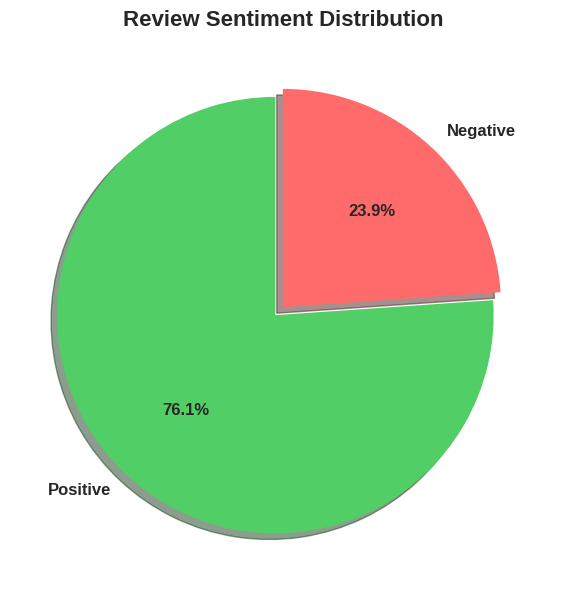

In [ ]:
if 'voted_up' in df_review.columns:
    positive_reviews = df_review['voted_up'].sum()
    total_reviews = len(df_review)
    positive_ratio = (positive_reviews / total_reviews) * 100

    print(f"Total Reviews: {total_reviews:,}")
    print(f"Positive Reviews: {positive_reviews:,} ({positive_ratio:.2f}%)")
    print(f"Negative Reviews: {total_reviews - positive_reviews:,} ({100-positive_ratio:.2f}%)")

    # Visualisasi
    plt.figure(figsize=(8, 6))
    labels = ['Positive', 'Negative']
    sizes = [positive_reviews, total_reviews - positive_reviews]
    colors = ['#51cf66', '#ff6b6b']
    explode = (0.05, 0)

    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    plt.title('Review Sentiment Distribution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/review_sentiment.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Review - Playtime

Reviews with Playtime Data: 870,758

Playtime Statistics (hours):
count    870758.000000
mean         37.138456
std         326.314848
min           0.016667
25%           1.150000
50%           4.433333
75%          15.633333
max       71832.300000
Name: author_playtime_forever, dtype: float64


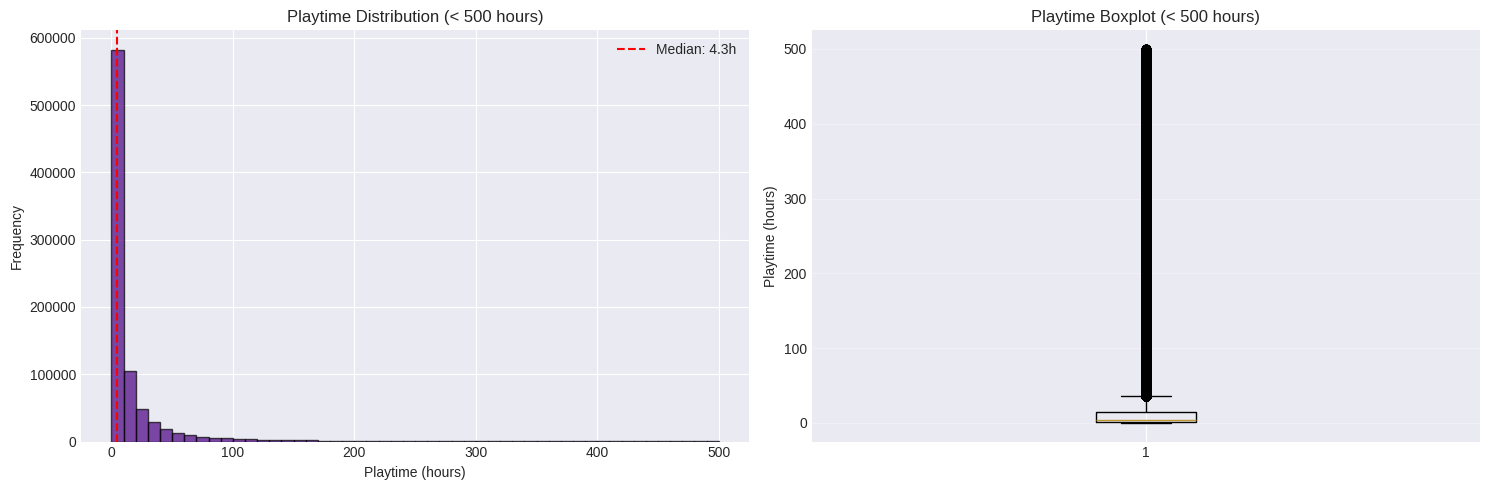

In [ ]:
if 'author_playtime_forever' in df_review.columns:
    playtime_data = df_review[df_review['author_playtime_forever'] > 0]

    # Convert menit ke jam
    playtime_hours = playtime_data['author_playtime_forever'] / 60

    print(f"Reviews with Playtime Data: {len(playtime_data):,}")
    print(f"\nPlaytime Statistics (hours):")
    print(playtime_hours.describe())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram (filtered < 500 hours)
    playtime_filtered = playtime_hours[playtime_hours < 500]
    axes[0].hist(playtime_filtered, bins=50, color='indigo', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Playtime (hours)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Playtime Distribution (< 500 hours)')
    axes[0].axvline(playtime_filtered.median(), color='red', linestyle='--', label=f'Median: {playtime_filtered.median():.1f}h')
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(playtime_filtered, vert=True)
    axes[1].set_ylabel('Playtime (hours)')
    axes[1].set_title('Playtime Boxplot (< 500 hours)')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/playtime_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Korelasi - Fitur Numerik

Correlation Matrix:
                       mat_final_price  metacritic_score  \
mat_final_price               1.000000          0.018779   
metacritic_score              0.018779          1.000000   
recommendations_total         0.031769          0.181735   
mat_achievement_count         0.001166          0.083242   
required_age                  0.013107          0.050868   
mat_discount_percent         -0.005578          0.011868   

                       recommendations_total  mat_achievement_count  \
mat_final_price                     0.031769               0.001166   
metacritic_score                    0.181735               0.083242   
recommendations_total               1.000000               0.007683   
mat_achievement_count               0.007683               1.000000   
required_age                        0.079146               0.006563   
mat_discount_percent                0.012625               0.043282   

                       required_age  mat_discount_percent  
m

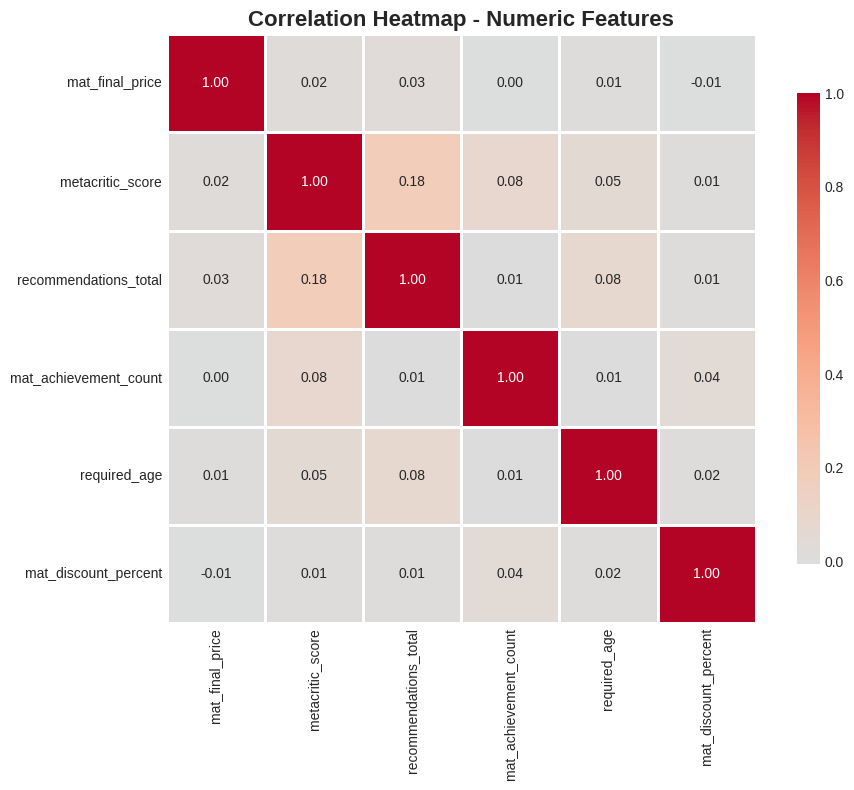


Strong Correlations (|r| > 0.5):


In [ ]:
numeric_cols = ['mat_final_price', 'metacritic_score', 'recommendations_total',
                'mat_achievement_count', 'required_age', 'mat_discount_percent']

# Filter hanya kolom yang benar-benar ada
numeric_cols = [col for col in numeric_cols if col in df_app.columns]

# Konversi ke numeric, error -> NaN
for col in numeric_cols:
    df_app[col] = pd.to_numeric(df_app[col], errors='coerce')

# Hitung korelasi
corr_matrix = df_app[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStrong Correlations (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")


##Identifikasi Outliers - Recommendations

In [ ]:
if 'recommendations_total' in df_app.columns:
    rec_data = df_app[df_app['recommendations_total'] > 0]

    # IQR method
    Q1 = rec_data['recommendations_total'].quantile(0.25)
    Q3 = rec_data['recommendations_total'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = rec_data[(rec_data['recommendations_total'] < lower_bound) |
                        (rec_data['recommendations_total'] > upper_bound)]

    print(f"Total Games with Recommendations: {len(rec_data):,}")
    print(f"Q1: {Q1:.0f}, Q3: {Q3:.0f}, IQR: {IQR:.0f}")
    print(f"Lower Bound: {lower_bound:.0f}, Upper Bound: {upper_bound:.0f}")
    print(f"Outliers Detected: {len(outliers):,} ({len(outliers)/len(rec_data)*100:.2f}%)")

    print(f"\n🔥 Top 10 Outliers (Highest Recommendations):")
    top_outliers = outliers.nlargest(10, 'recommendations_total')[['name', 'recommendations_total', 'metacritic_score']]
    print(top_outliers.to_string(index=False))

Total Games with Recommendations: 22,560
Q1: 174, Q3: 1205, IQR: 1031
Lower Bound: -1373, Upper Bound: 2752
Outliers Detected: 3,306 (14.65%)

🔥 Top 10 Outliers (Highest Recommendations):
                             name  recommendations_total  metacritic_score
                 Counter-Strike 2              4661011.0               NaN
        Grand Theft Auto V Legacy              1835735.0              96.0
              PUBG: BATTLEGROUNDS              1746923.0               NaN
Tom Clancy's Rainbow Six® Siege X              1213861.0               NaN
                         Terraria              1143314.0              83.0
                             Rust              1043371.0              69.0
                      Garry's Mod              1013561.0               NaN
               Black Myth: Wukong               855328.0               NaN
                 Wallpaper Engine               852300.0               NaN
                   Stardew Valley               790798.0      

##Analisis Temporal - Release Date

Games with Valid Release Date: 202,602
Year Range: 1997 - 2025


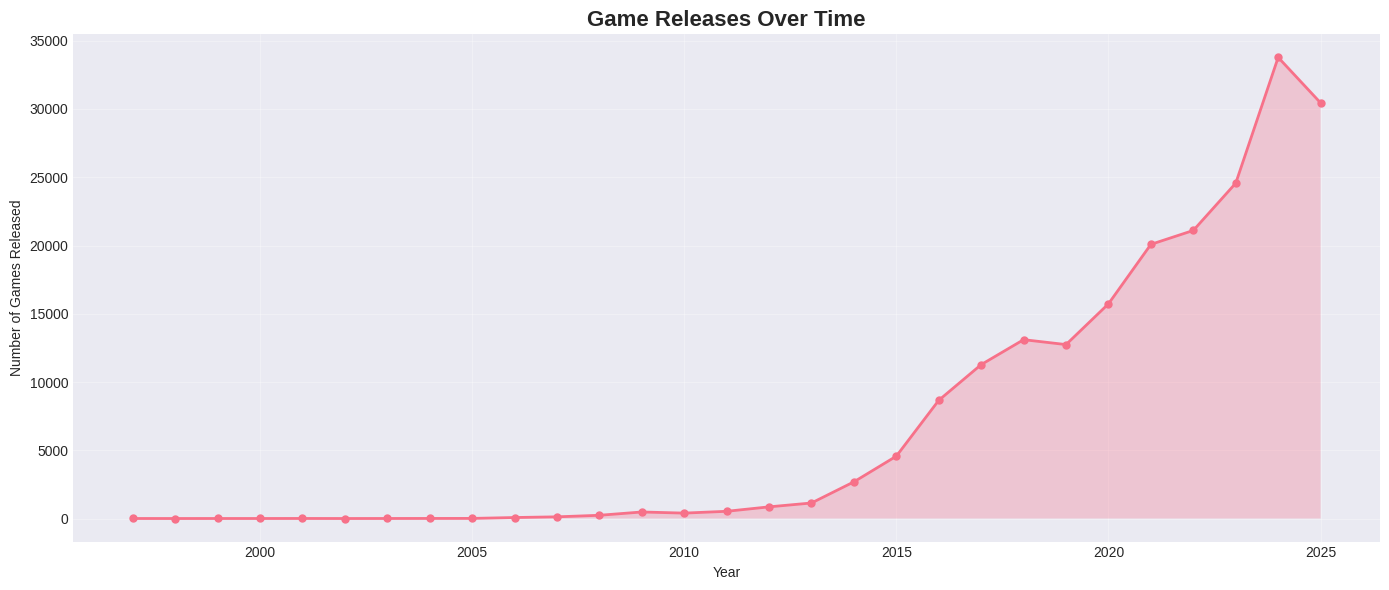


📈 Top 5 Years with Most Releases:
release_year
2024.0    33780
2025.0    30446
2023.0    24567
2022.0    21103
2021.0    20083
dtype: int64


In [ ]:
if 'release_date' in df_app.columns:
    # Convert to datetime
    df_app['release_date_parsed'] = pd.to_datetime(df_app['release_date'], errors='coerce')

    # Extract year
    df_app['release_year'] = df_app['release_date_parsed'].dt.year

    # Filter data yang valid
    valid_years = df_app[(df_app['release_year'] >= 1990) & (df_app['release_year'] <= 2025)]

    print(f"Games with Valid Release Date: {len(valid_years):,}")
    print(f"Year Range: {valid_years['release_year'].min():.0f} - {valid_years['release_year'].max():.0f}")

    # Games per year
    games_per_year = valid_years.groupby('release_year').size()

    plt.figure(figsize=(14, 6))
    plt.plot(games_per_year.index, games_per_year.values, marker='o', linewidth=2, markersize=5)
    plt.fill_between(games_per_year.index, games_per_year.values, alpha=0.3)
    plt.xlabel('Year')
    plt.ylabel('Number of Games Released')
    plt.title('Game Releases Over Time', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/releases_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n📈 Top 5 Years with Most Releases:")
    print(games_per_year.nlargest(5))

##Price vs Recommendations Analysis

Data points for analysis: 11,741


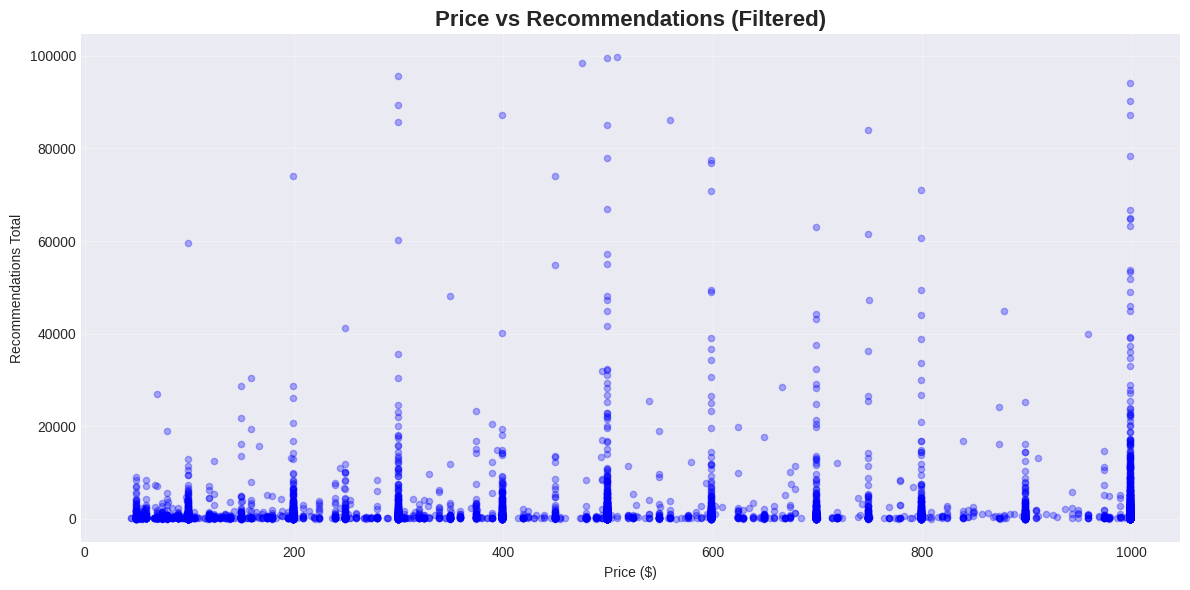


Correlation (Price vs Recommendations): 0.044


In [ ]:
if 'mat_final_price' in df_app.columns and 'recommendations_total' in df_app.columns:
    # Filter data
    price_rec_data = df_app[(df_app['mat_final_price'] > 0) &
                             (df_app['recommendations_total'] > 0) &
                             (df_app['mat_final_price'] < 1000) &
                             (df_app['recommendations_total'] < 100000)]

    print(f"Data points for analysis: {len(price_rec_data):,}")

    # Scatter plot
    plt.figure(figsize=(12, 6))
    plt.scatter(price_rec_data['mat_final_price'],
                price_rec_data['recommendations_total'],
                alpha=0.3, s=20, color='blue')
    plt.xlabel('Price ($)')
    plt.ylabel('Recommendations Total')
    plt.title('Price vs Recommendations (Filtered)', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/price_vs_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

  # Correlation
    corr = price_rec_data[['mat_final_price', 'recommendations_total']].corr().iloc[0, 1]
    print(f"\nCorrelation (Price vs Recommendations): {corr:.3f}")

##Metacritic vs Recommendations Analysis

Data points for analysis: 3,687


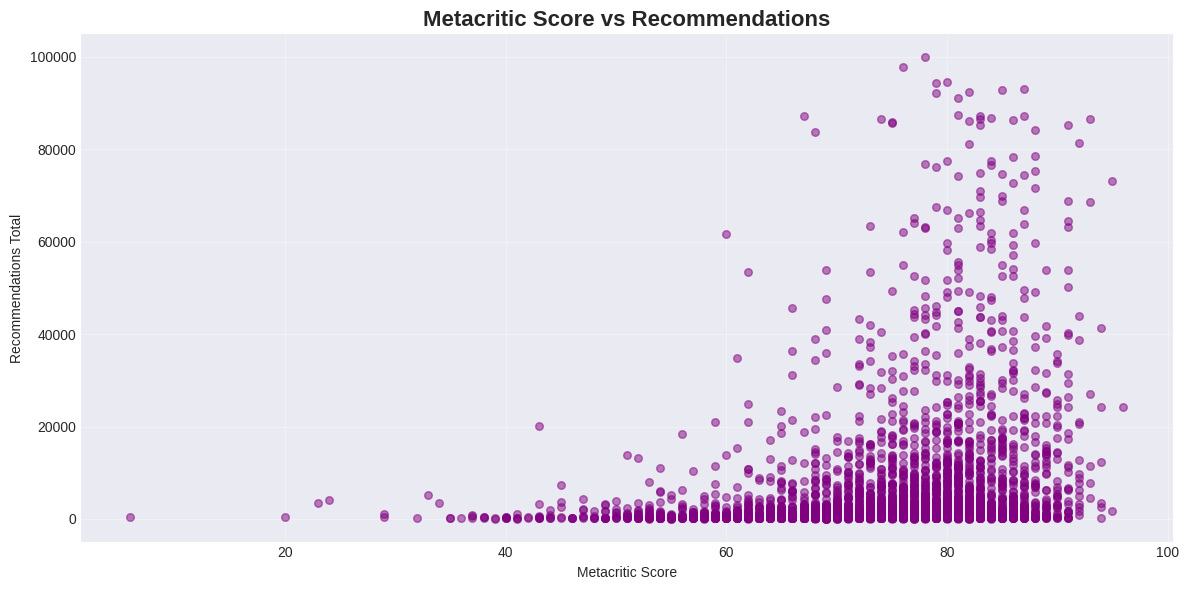


Correlation (Metacritic vs Recommendations): 0.255


In [ ]:
if 'metacritic_score' in df_app.columns and 'recommendations_total' in df_app.columns:
    # Filter data yang valid
    meta_rec_data = df_app[(df_app['metacritic_score'].notna()) &
                            (df_app['recommendations_total'] > 0) &
                            (df_app['recommendations_total'] < 100000)]

    print(f"Data points for analysis: {len(meta_rec_data):,}")

    # Scatter plot
    plt.figure(figsize=(12, 6))
    plt.scatter(meta_rec_data['metacritic_score'],
                meta_rec_data['recommendations_total'],
                alpha=0.5, s=30, color='purple')
    plt.xlabel('Metacritic Score')
    plt.ylabel('Recommendations Total')
    plt.title('Metacritic Score vs Recommendations', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/metacritic_vs_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Correlation
    corr = meta_rec_data[['metacritic_score', 'recommendations_total']].corr().iloc[0, 1]
    print(f"\nCorrelation (Metacritic vs Recommendations): {corr:.3f}")


##Achievement vs Recommendations Analysis

Data points for analysis: 14,992


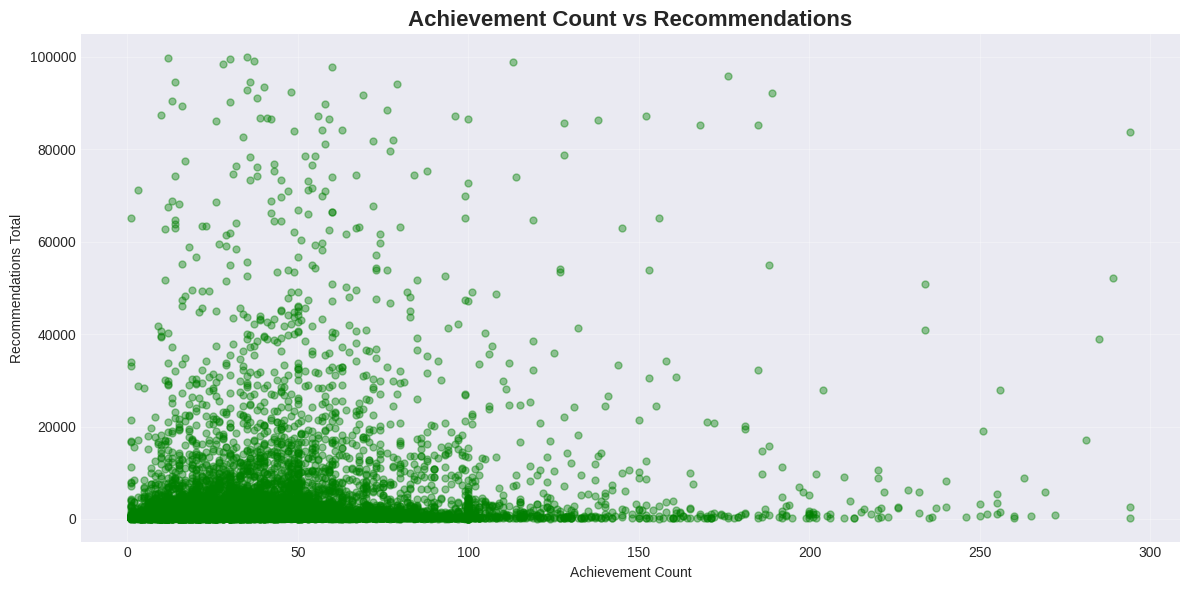


Correlation (Achievement vs Recommendations): 0.179


In [ ]:
if 'mat_achievement_count' in df_app.columns and 'recommendations_total' in df_app.columns:
    # Filter data yang valid
    ach_rec_data = df_app[(df_app['mat_achievement_count'].notna()) &
                           (df_app['mat_achievement_count'] > 0) &
                           (df_app['recommendations_total'] > 0) &
                           (df_app['recommendations_total'] < 100000) &
                           (df_app['mat_achievement_count'] < 300)]

    print(f"Data points for analysis: {len(ach_rec_data):,}")

    # Scatter plot
    plt.figure(figsize=(12, 6))
    plt.scatter(ach_rec_data['mat_achievement_count'],
                ach_rec_data['recommendations_total'],
                alpha=0.4, s=25, color='green')
    plt.xlabel('Achievement Count')
    plt.ylabel('Recommendations Total')
    plt.title('Achievement Count vs Recommendations', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/achievement_vs_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Correlation
    corr = ach_rec_data[['mat_achievement_count', 'recommendations_total']].corr().iloc[0, 1]
    print(f"\nCorrelation (Achievement vs Recommendations): {corr:.3f}")

##Free vs Paid - Recommendations Comparison

Free Games:
  Count: 48,274
  Avg Recommendations: 18194.69
  Median Recommendations: 305.00

Paid Games:
  Count: 191,390
  Avg Recommendations: 4340.77
  Median Recommendations: 370.00


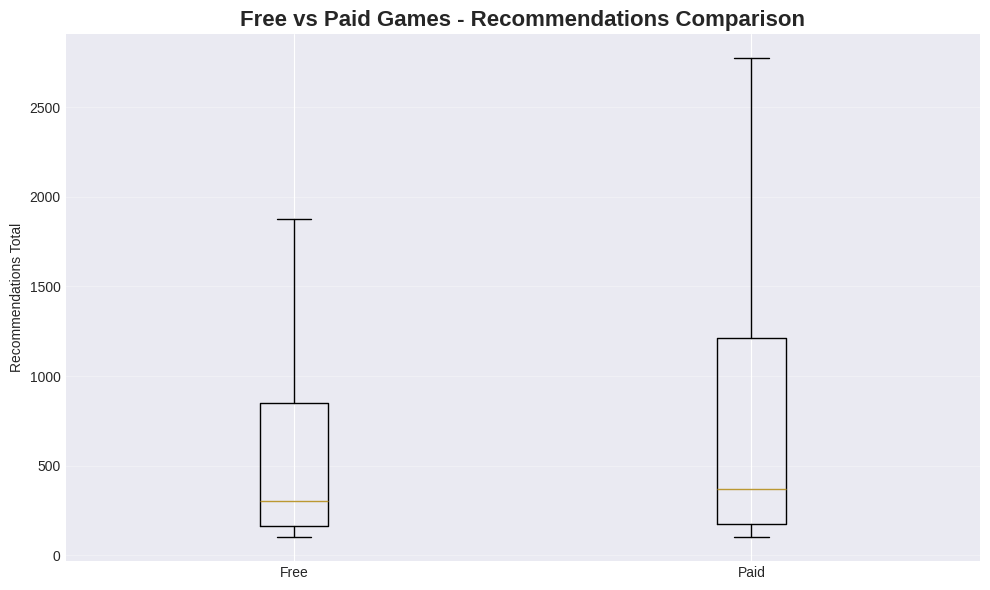

In [ ]:
if 'is_free' in df_app.columns and 'recommendations_total' in df_app.columns:
    free_games = df_app[df_app['is_free'] == True]['recommendations_total']
    paid_games = df_app[df_app['is_free'] == False]['recommendations_total']

    print("Free Games:")
    print(f"  Count: {len(free_games):,}")
    print(f"  Avg Recommendations: {free_games.mean():.2f}")
    print(f"  Median Recommendations: {free_games.median():.2f}")

    print("\nPaid Games:")
    print(f"  Count: {len(paid_games):,}")
    print(f"  Avg Recommendations: {paid_games.mean():.2f}")
    print(f"  Median Recommendations: {paid_games.median():.2f}")

    # Boxplot comparison
    plt.figure(figsize=(10, 6))
    data_to_plot = [free_games[free_games > 0], paid_games[paid_games > 0]]
    plt.boxplot(data_to_plot, labels=['Free', 'Paid'], showfliers=False)
    plt.ylabel('Recommendations Total')
    plt.title('Free vs Paid Games - Recommendations Comparison', fontsize=16, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/free_vs_paid_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

##Platform Support vs Recommendations

Platform Support vs Recommendations:
                        mean  median  count
platform_count                             
0                        NaN     NaN      0
1                1658.794118   265.5     34
2               30022.545455  9698.0     11
3                4640.546791   368.0  22515

Individual Platform Analysis:

Windows:
  Games Supporting: 239,658 (100.0%)
  Avg Recommendations (Supported): 4648.43
  Avg Recommendations (Not Supported): nan

Mac:
  Games Supporting: 239,392 (99.9%)
  Avg Recommendations (Supported): 4653.13
  Avg Recommendations (Not Supported): 1622.34

Linux:
  Games Supporting: 239,364 (99.9%)
  Avg Recommendations (Supported): 4640.36
  Avg Recommendations (Not Supported): 8778.73


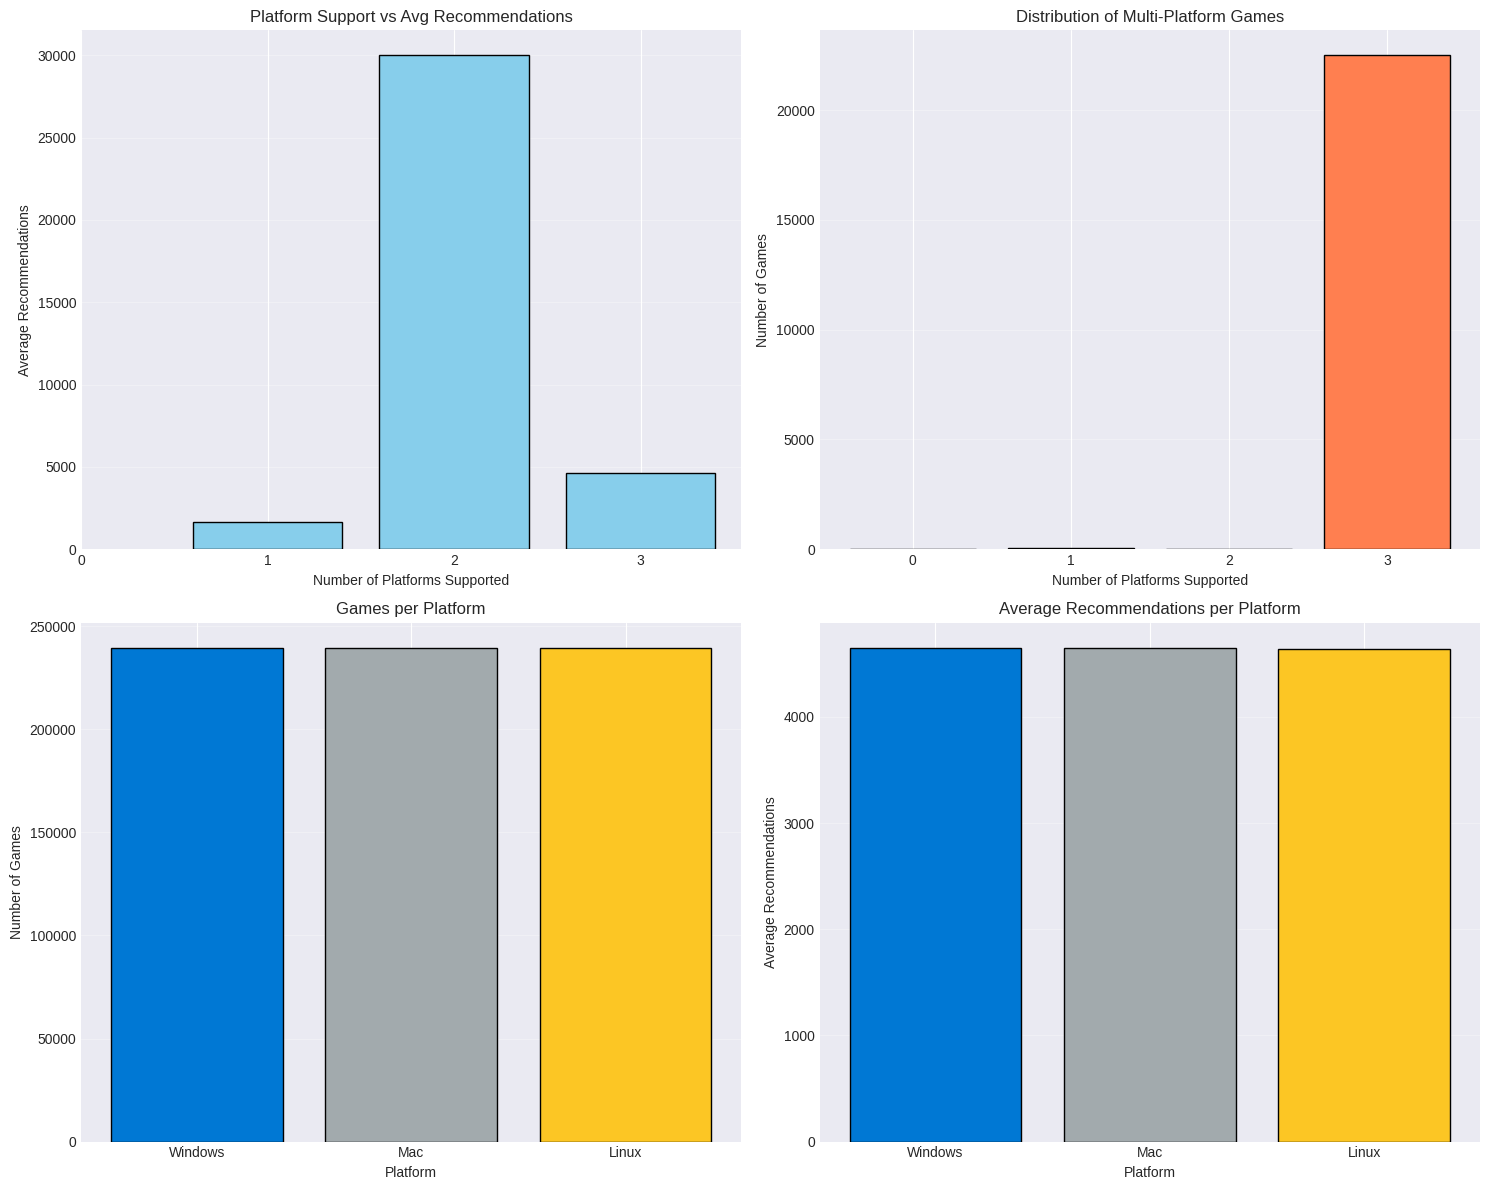


CROSS-PLATFORM COMBINATIONS:
                          count  avg_recommendations
platform_combo_readable                             
All Platforms            239352          4640.546791
Windows Only                254          1658.794118
Windows + Mac                40         32986.500000
Windows + Linux              12           383.000000
None                          6                  NaN


In [ ]:
platform_cols = ['mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux']
has_platform_cols = all(col in df_app.columns for col in platform_cols)

if has_platform_cols and 'recommendations_total' in df_app.columns:
    df_app['platform_count'] = df_app[platform_cols].sum(axis=1)

    # Aggregate recommendations
    platform_rec = df_app.groupby('platform_count')['recommendations_total'].agg(['mean', 'median', 'count'])

    print("Platform Support vs Recommendations:")
    print(platform_rec)
    print()

    print("Individual Platform Analysis:")
    for col in platform_cols:
        platform_name = col.replace('mat_supports_', '').capitalize()
        supported = df_app[df_app[col] == True]
        not_supported = df_app[df_app[col] == False]

        avg_rec_supported = supported['recommendations_total'].mean()
        avg_rec_not_supported = not_supported['recommendations_total'].mean()

        print(f"\n{platform_name}:")
        print(f"  Games Supporting: {len(supported):,} ({len(supported)/len(df_app)*100:.1f}%)")
        print(f"  Avg Recommendations (Supported): {avg_rec_supported:.2f}")
        print(f"  Avg Recommendations (Not Supported): {avg_rec_not_supported:.2f}")

    # Visualisasi
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Platform count vs Average Recommendations
    axes[0, 0].bar(platform_rec.index, platform_rec['mean'], color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Number of Platforms Supported')
    axes[0, 0].set_ylabel('Average Recommendations')
    axes[0, 0].set_title('Platform Support vs Avg Recommendations')
    axes[0, 0].set_xticks([0, 1, 2, 3])
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Plot 2: Distribution of Multi-Platform Games
    axes[0, 1].bar(platform_rec.index, platform_rec['count'], color='coral', edgecolor='black')
    axes[0, 1].set_xlabel('Number of Platforms Supported')
    axes[0, 1].set_ylabel('Number of Games')
    axes[0, 1].set_title('Distribution of Multi-Platform Games')
    axes[0, 1].set_xticks([0, 1, 2, 3])
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Plot 3: Individual Platform Support
    individual_platform_count = []
    platform_names = []
    for col in platform_cols:
        platform_name = col.replace('mat_supports_', '').capitalize()
        platform_names.append(platform_name)
        individual_platform_count.append(df_app[col].sum())

    axes[1, 0].bar(platform_names, individual_platform_count, color=['#0078D4', '#A2AAAD', '#FCC624'], edgecolor='black')
    axes[1, 0].set_xlabel('Platform')
    axes[1, 0].set_ylabel('Number of Games')
    axes[1, 0].set_title('Games per Platform')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Plot 4: Average Recommendations per Platform
    avg_rec_per_platform = []
    for col in platform_cols:
        supported = df_app[df_app[col] == True]
        avg_rec_per_platform.append(supported['recommendations_total'].mean())

    axes[1, 1].bar(platform_names, avg_rec_per_platform, color=['#0078D4', '#A2AAAD', '#FCC624'], edgecolor='black')
    axes[1, 1].set_xlabel('Platform')
    axes[1, 1].set_ylabel('Average Recommendations')
    axes[1, 1].set_title('Average Recommendations per Platform')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('platform_vs_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Cross-platform combinations analysis
    print("\n" + "=" * 80)
    print("CROSS-PLATFORM COMBINATIONS:")
    print("=" * 80)
    df_app['platform_combo'] = ''
    df_app.loc[df_app['mat_supports_windows'] == True, 'platform_combo'] += 'W'
    df_app.loc[df_app['mat_supports_mac'] == True, 'platform_combo'] += 'M'
    df_app.loc[df_app['mat_supports_linux'] == True, 'platform_combo'] += 'L'
    combo_mapping = {
        '': 'None',
        'W': 'Windows Only',
        'M': 'Mac Only',
        'L': 'Linux Only',
        'WM': 'Windows + Mac',
        'WL': 'Windows + Linux',
        'ML': 'Mac + Linux',
        'WML': 'All Platforms'
    }

    df_app['platform_combo_readable'] = df_app['platform_combo'].map(combo_mapping)

    combo_stats = df_app.groupby('platform_combo_readable').agg({
        'appid': 'count',
        'recommendations_total': 'mean'
    }).rename(columns={'appid': 'count', 'recommendations_total': 'avg_recommendations'})
    combo_stats = combo_stats.sort_values('count', ascending=False)

    print(combo_stats)
else:
    print("Required columns not found for platform analysis")

##Review Analysis - Games without Reviews

In [ ]:
apps_with_reviews = df_review['appid'].unique()
df_app['has_reviews'] = df_app['appid'].isin(apps_with_reviews)

games_with_reviews = df_app[df_app['has_reviews'] == True]
games_without_reviews = df_app[df_app['has_reviews'] == False]

print(f"Games WITH Reviews: {len(games_with_reviews):,} ({len(games_with_reviews)/len(df_app)*100:.1f}%)")
print(f"Games WITHOUT Reviews: {len(games_without_reviews):,} ({len(games_without_reviews)/len(df_app)*100:.1f}%)")

# Analisis karakteristik games tanpa review
if len(games_without_reviews) > 0:
    print("\nCharacteristics of Games WITHOUT Reviews:")

    if 'is_free' in df_app.columns:
        free_pct = (games_without_reviews['is_free'].sum() / len(games_without_reviews)) * 100
        print(f"  Free Games: {free_pct:.1f}%")

    if 'mat_final_price' in df_app.columns:
        avg_price = games_without_reviews[games_without_reviews['mat_final_price'] > 0]['mat_final_price'].mean()
        print(f"  Avg Price (paid games): ${avg_price:.2f}")

    if 'release_year' in df_app.columns:
        recent_games = games_without_reviews[games_without_reviews['release_year'] >= 2020]
        print(f"  Released since 2020: {len(recent_games):,} ({len(recent_games)/len(games_without_reviews)*100:.1f}%)")

Games WITH Reviews: 117,311 (48.9%)
Games WITHOUT Reviews: 122,353 (51.1%)

Characteristics of Games WITHOUT Reviews:
  Free Games: 35.7%
  Avg Price (paid games): $4783.13
  Released since 2020: 70,332 (57.5%)


In [ ]:
df_app.to_csv('/content/drive/MyDrive/project_ai/dataset/application_processed.csv', index=False)
df_app.head()

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at,release_date_parsed,release_year,platform_count,platform_combo,platform_combo_readable,has_reviews
0,10,Counter-Strike,game,False,2000-11-01,0.0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,88.0,161854.0,True,True,True,999.0,999.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,2000-11-01,2000.0,3,WML,All Platforms,False
1,20,Team Fortress Classic,game,False,1999-04-01,0.0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,6633.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,1999-04-01,1999.0,3,WML,All Platforms,False
2,30,Day of Defeat,game,False,2003-05-01,0.0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,79.0,4308.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,2003-05-01,2003.0,3,WML,All Platforms,False
3,40,Deathmatch Classic,game,False,2001-06-01,0.0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,2338.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,2001-06-01,2001.0,3,WML,All Platforms,False
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0.0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,22793.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,1999-11-01,1999.0,3,WML,All Platforms,False


#**DATA PREPARATION & FEATURE ENGINEERING**

In [ ]:
DATA_PATH = '/content/drive/MyDrive/project_ai/dataset/'

df_app = pd.read_csv(f'{DATA_PATH}applications.csv')
df_review = pd.read_csv(f'{DATA_PATH}reviews.csv')
df_genre = pd.read_csv(f'{DATA_PATH}genres.csv')
df_categories = pd.read_csv(f'{DATA_PATH}categories.csv')
df_platform = pd.read_csv(f'{DATA_PATH}platforms.csv')
df_developer = pd.read_csv(f'{DATA_PATH}developers.csv')
df_publisher = pd.read_csv(f'{DATA_PATH}publishers.csv')
df_app_genres = pd.read_csv(f'{DATA_PATH}application_genres.csv')
df_app_categories = pd.read_csv(f'{DATA_PATH}application_categories.csv')
df_app_developers = pd.read_csv(f'{DATA_PATH}application_developers.csv')

print(f"Application: {df_app.shape}")
print(f"Review: {df_review.shape}")

Application: (239664, 30)
Review: (1048148, 23)


##1. DATA CLEANING

###Handle Missing Values - Application Dataset

In [ ]:
print("\nMissing Values BEFORE Cleaning:")
missing_before = df_app.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print(missing_before)

print("\nApplying Missing Value Strategies...")

# 1. Metacritic Score: Fill dengan 0
if 'metacritic_score' in df_app.columns:
    df_app['metacritic_score'] = df_app['metacritic_score'].fillna(0)
    print("✅ metacritic_score: Filled with 0")

# 2. Recommendations Total: Fill dengan 0
if 'recommendations_total' in df_app.columns:
    df_app['recommendations_total'] = df_app['recommendations_total'].fillna(0)
    print("✅ recommendations_total: Filled with 0")

# 3. Achievement Count: Fill dengan 0
if 'mat_achievement_count' in df_app.columns:
    df_app['mat_achievement_count'] = df_app['mat_achievement_count'].fillna(0)
    print("✅ mat_achievement_count: Filled with 0")

# 4. Price: Fill dengan 0 untuk game gratis
if 'mat_final_price' in df_app.columns:
    df_app['mat_final_price'] = df_app['mat_final_price'].fillna(0)
    print("✅ mat_final_price: Filled with 0")

if 'mat_initial_price' in df_app.columns:
    df_app['mat_initial_price'] = df_app['mat_initial_price'].fillna(0)
    print("✅ mat_initial_price: Filled with 0")

# 5. Discount: Fill dengan 0
if 'mat_discount_percent' in df_app.columns:
    df_app['mat_discount_percent'] = df_app['mat_discount_percent'].fillna(0)
    print("✅ mat_discount_percent: Filled with 0")

# 6. Platform Support: Fill dengan False
platform_cols = ['mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux']
for col in platform_cols:
    if col in df_app.columns:
        df_app[col] = df_app[col].fillna(False)
        print(f"✅ {col}: Filled with False")

# 7. Required Age: Convert to numeric and fill with median
if 'required_age' in df_app.columns:
    df_app['required_age'] = pd.to_numeric(df_app['required_age'], errors='coerce')
    median_age = df_app['required_age'].median()
    df_app['required_age'] = df_app['required_age'].fillna(median_age)
    print(f"✅ required_age: Converted to numeric and filled with median ({median_age})")

# 8. Text fields: Fill dengan empty string
text_cols = ['short_description', 'supported_languages', 'name']
for col in text_cols:
    if col in df_app.columns:
        df_app[col] = df_app[col].fillna('')
        print(f"✅ {col}: Filled with empty string")

# 9. Type: Fill dengan 'unknown' atau mode
if 'type' in df_app.columns:
    mode_type = df_app['type'].mode()[0] if len(df_app['type'].mode()) > 0 else 'game'
    df_app['type'] = df_app['type'].fillna(mode_type)
    print(f"✅ type: Filled with mode ({mode_type})")

# 10. Currency: Fill dengan 'USD' atau mode
if 'mat_currency' in df_app.columns:
    mode_currency = df_app['mat_currency'].mode()[0] if len(df_app['mat_currency'].mode()) > 0 else 'USD'
    df_app['mat_currency'] = df_app['mat_currency'].fillna(mode_currency)
    print(f"✅ mat_currency: Filled with mode ({mode_currency})")

# 11. Release Date: Fill dengan 'Unknown' atau tanggal default
if 'release_date' in df_app.columns:
    df_app['release_date'] = df_app['release_date'].fillna('Unknown')
    print(f"✅ release_date: Filled with 'Unknown'")

# 12. System Requirements (PC specs): Fill dengan 'Not specified'
pc_spec_cols = [
    'mat_pc_os_min', 'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min',
    'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec', 'mat_pc_graphics_rec'
]
for col in pc_spec_cols:
    if col in df_app.columns:
        df_app[col] = df_app[col].fillna('Not specified')
        print(f"✅ {col}: Filled with 'Not specified'")

print("\nMissing Values AFTER Cleaning:")
missing_after = df_app.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
if len(missing_after) > 0:
    print(missing_after)
    print(f"\nStill {len(missing_after)} columns with missing values")
else:
    print("No missing values")


Missing Values BEFORE Cleaning:
metacritic_score         234365
recommendations_total    217104
mat_achievement_count    178263
mat_pc_graphics_rec      147617
mat_pc_memory_rec        142839
mat_pc_processor_rec     142628
mat_pc_os_rec            137774
mat_initial_price         94741
mat_final_price           94741
mat_currency              94741
mat_discount_percent      94741
mat_pc_graphics_min       70422
mat_pc_memory_min         58390
mat_pc_processor_min      56422
mat_pc_os_min             43790
release_date              36855
supported_languages       17658
short_description         15493
type                       2667
name                          4
dtype: int64

Applying Missing Value Strategies...
✅ metacritic_score: Filled with 0
✅ recommendations_total: Filled with 0
✅ mat_achievement_count: Filled with 0
✅ mat_final_price: Filled with 0
✅ mat_initial_price: Filled with 0
✅ mat_discount_percent: Filled with 0
✅ mat_supports_windows: Filled with False
✅ mat_supports_m

###Handle Duplicates

In [ ]:
# Check duplicates in application
print("Application Dataset:")
app_duplicates = df_app.duplicated(subset=['appid']).sum()
print(f"  Duplicate appids: {app_duplicates}")
if app_duplicates > 0:
    df_app = df_app.drop_duplicates(subset=['appid'], keep='first')
    print(f"  ✅ Removed {app_duplicates} duplicates")

# Check duplicates in review
print("\nReview Dataset:")
review_duplicates = df_review.duplicated(subset=['recommendationid']).sum()
print(f"  Duplicate recommendationids: {review_duplicates}")
if review_duplicates > 0:
    df_review = df_review.drop_duplicates(subset=['recommendationid'], keep='first')
    print(f"  ✅ Removed {review_duplicates} duplicates")

# Check duplicates in supporting datasets
for name, df, id_col in [
    ('Genre', df_genre, 'id'),
    ('Categories', df_categories, 'id'),
    ('Platform', df_platform, 'id'),
    ('Developer', df_developer, 'id'),
    ('Publisher', df_publisher, 'id')
]:
    dups = df.duplicated(subset=[id_col]).sum()
    if dups > 0:
        print(f"\n{name} Dataset:")
        print(f"  Duplicate {id_col}s: {dups}")

Application Dataset:
  Duplicate appids: 0

Review Dataset:
  Duplicate recommendationids: 0


### Filtering Data - Type='game' only

In [ ]:
print(f"Original Application rows: {len(df_app):,}")

# Filter hanya type='game'
if 'type' in df_app.columns:
    type_counts_before = df_app['type'].value_counts()
    print("\nType distribution BEFORE filtering:")
    print(type_counts_before)

    # Filter
    df_app = df_app[df_app['type'] == 'game'].copy()
    print(f"\n✅ Filtered to type='game' only")
    print(f"   Remaining rows: {len(df_app):,}")

    # Calculate removed
    removed = type_counts_before.sum() - len(df_app)
    print(f"   Removed: {removed:,} non-game items ({removed/type_counts_before.sum()*100:.1f}%)")

# Filter out games with no name
if 'name' in df_app.columns:
    no_name = df_app['name'].isna().sum()
    if no_name > 0:
        df_app = df_app[df_app['name'].notna()].copy()
        print(f"\n✅ Removed {no_name} games without name")

print(f"\nFinal Application rows: {len(df_app):,}")

Original Application rows: 239,664

Type distribution BEFORE filtering:
type
game     152946
dlc       53792
demo      23521
music      8713
video       692
Name: count, dtype: int64

✅ Filtered to type='game' only
   Remaining rows: 152,946
   Removed: 86,718 non-game items (36.2%)

Final Application rows: 152,946


###Normalisasi Format Data - Dates

In [ ]:
if 'release_date' in df_app.columns:
    print("Converting release_date to datetime...")
    df_app['release_date_parsed'] = pd.to_datetime(df_app['release_date'], errors='coerce')

    # Extract components
    df_app['release_year'] = df_app['release_date_parsed'].dt.year
    df_app['release_month'] = df_app['release_date_parsed'].dt.month
    df_app['release_day'] = df_app['release_date_parsed'].dt.day

    # Days since release (from today)
    today = pd.Timestamp.now()
    df_app['days_since_release'] = (today - df_app['release_date_parsed']).dt.days

    # Handle negative days (future releases) dan NaT
    df_app['days_since_release'] = df_app['days_since_release'].fillna(0)
    df_app['days_since_release'] = df_app['days_since_release'].clip(lower=0)

    print(f"✅ Date columns created:")
    print(f"   - release_year (range: {df_app['release_year'].min():.0f} - {df_app['release_year'].max():.0f})")
    print(f"   - release_month")
    print(f"   - release_day")
    print(f"   - days_since_release (range: {df_app['days_since_release'].min():.0f} - {df_app['days_since_release'].max():.0f})")

# Review timestamps
if 'timestamp_created' in df_review.columns:
    print("\nConverting review timestamps...")
    df_review['review_date'] = pd.to_datetime(df_review['timestamp_created'], unit='s', errors='coerce')
    df_review['review_year'] = df_review['review_date'].dt.year
    print("✅ Review date columns created")

Converting release_date to datetime...
✅ Date columns created:
   - release_year (range: 1969 - 2099)
   - release_month
   - release_day
   - days_since_release (range: 0 - 20438)

Converting review timestamps...
✅ Review date columns created


###Normalisasi Format Data - Currency & Text

In [ ]:
# Currency: Pastikan semua dalam satu mata uang (assume USD atau convert jika perlu)
if 'mat_currency' in df_app.columns:
    currency_dist = df_app['mat_currency'].value_counts()
    print("Currency distribution:")
    print(currency_dist.head())

    # Untuk simplifikasi, kita akan filter atau convert ke USD
    # Jika mayoritas USD, filter hanya USD. Jika tidak, butuh conversion rate
    if currency_dist.index[0] == 'USD' or currency_dist.iloc[0] / len(df_app) > 0.8:
        print(f"\n✅ Filtering to {currency_dist.index[0]} only")
        df_app = df_app[df_app['mat_currency'] == currency_dist.index[0]].copy()

# Text: Lowercase and clean
text_cols = ['name', 'short_description', 'supported_languages']
for col in text_cols:
    if col in df_app.columns:
        # Convert to string and lowercase
        df_app[col] = df_app[col].astype(str).str.lower().str.strip()

print("✅ Text normalization completed")

print(f"\nFinal cleaned dataset shape: {df_app.shape}")

Currency distribution:
mat_currency
USD    151578
EUR       269
AUD       220
PLN       211
CAD       201
Name: count, dtype: int64

✅ Filtering to USD only
✅ Text normalization completed

Final cleaned dataset shape: (151578, 35)


##2. merge & join tables

###Aggregate Review Metrics

In [ ]:
# Aggregate metrics dari review.csv
review_agg = df_review.groupby('appid').agg({
    'recommendationid': 'count',
    'voted_up': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'weighted_vote_score': 'mean',
    'author_playtime_forever': 'sum',
    'written_during_early_access': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'received_for_free': lambda x: (x == True).sum() / len(x) if len(x) > 0 else 0,
    'votes_up': 'sum',
    'votes_funny': 'sum',
    'comment_count': 'sum',
}).reset_index()

review_agg.columns = [
    'appid',
    'total_reviews',
    'positive_review_ratio',
    'avg_weighted_vote_score',
    'total_playtime_minutes',
    'early_access_review_ratio',
    'free_copy_ratio',
    'total_votes_up',
    'total_votes_funny',
    'total_comment_count'
]

# Additional calculated metrics
review_agg['total_playtime_hours'] = review_agg['total_playtime_minutes'] / 60
review_agg['avg_playtime_per_review'] = review_agg['total_playtime_minutes'] / review_agg['total_reviews']

print(f"✅ Review aggregation completed: {len(review_agg):,} games with reviews")
print(f"\nReview Metrics Preview:")
review_agg.head()

✅ Review aggregation completed: 117,311 games with reviews

Review Metrics Preview:


,appid,total_reviews,positive_review_ratio,avg_weighted_vote_score,total_playtime_minutes,early_access_review_ratio,free_copy_ratio,total_votes_up,total_votes_funny,total_comment_count,total_playtime_hours,avg_playtime_per_review
0,400,100,0.960000,0.512672,58534.0,0.0,0.02,100,17,31,975.566667,585.340000
1,1280,20,0.900000,0.503991,116103.0,0.0,0.00,11,1,2,1935.050000,5805.150000
2,1300,19,0.947368,0.512735,4052.0,0.0,0.00,18,1,5,67.533333,213.263158
3,1313,6,0.333333,0.517133,3494.0,0.0,0.00,10,0,0,58.233333,582.333333
4,1500,2,1.000000,0.500000,1179.0,0.0,0.00,0,0,0,19.650000,589.500000


###Join Application with Review Aggregates

In [ ]:
print(f"Application rows before merge: {len(df_app):,}")

# Left join (keep all applications, even without reviews)
df_main = df_app.merge(review_agg, on='appid', how='left')

print(f"Merged: {len(df_main):,} rows")

# Fill NaN untuk games tanpa review dengan 0
review_cols = [
    'total_reviews', 'positive_review_ratio', 'avg_weighted_vote_score',
    'total_playtime_minutes', 'early_access_review_ratio', 'free_copy_ratio',
    'total_votes_up', 'total_votes_funny', 'total_comment_count',
    'total_playtime_hours', 'avg_playtime_per_review'
]

for col in review_cols:
    if col in df_main.columns:
        df_main[col] = df_main[col].fillna(0)

print("\nMerged Dataset Info:")
print(f"   Total rows: {len(df_main):,}")
print(f"   Games with reviews: {(df_main['total_reviews'] > 0).sum():,}")
print(f"   Games without reviews: {(df_main['total_reviews'] == 0).sum():,}")

Application rows before merge: 151,578
Merged: 151,578 rows

Merged Dataset Info:
   Total rows: 151,578
   Games with reviews: 84,510
   Games without reviews: 67,068


###Join with Genre, Categories, Platform

In [ ]:
##Genre
if len(df_app_genres) > 0 and len(df_genre) > 0:
    # Join correlation table with genre names
    genre_mapping = df_app_genres.merge(
        df_genre.rename(columns={'id': 'genre_id'}),
        on='genre_id',
        how='left'
    )

    # Aggregate to list per appid
    genre_agg = genre_mapping.groupby('appid')['name'].apply(list).reset_index()
    genre_agg.columns = ['appid', 'genres']

    # Count genres per game
    genre_agg['genre_count'] = genre_agg['genres'].apply(len)

    # Merge with main dataset
    df_main = df_main.merge(genre_agg, on='appid', how='left')
    df_main['genres'] = df_main['genres'].apply(lambda x: x if isinstance(x, list) else [])
    df_main['genre_count'] = df_main['genre_count'].fillna(0)

    print(f"✅ Genres merged: {len(genre_agg):,} games with genre data")
    print(f"   Total genre associations: {len(df_app_genres):,}")
else:
    print("⚠️ Genre data not available")
    df_main['genres'] = [[]] * len(df_main)
    df_main['genre_count'] = 0

# categories
if len(df_app_categories) > 0 and len(df_categories) > 0:
    # Join correlation table with category names
    cat_mapping = df_app_categories.merge(
        df_categories.rename(columns={'id': 'category_id'}),
        on='category_id',
        how='left'
    )

    # Aggregate to list per appid
    cat_agg = cat_mapping.groupby('appid')['name'].apply(list).reset_index()
    cat_agg.columns = ['appid', 'categories']

    # Count categories per game
    cat_agg['category_count'] = cat_agg['categories'].apply(len)

    # Merge with main dataset
    df_main = df_main.merge(cat_agg, on='appid', how='left')
    df_main['categories'] = df_main['categories'].apply(lambda x: x if isinstance(x, list) else [])
    df_main['category_count'] = df_main['category_count'].fillna(0)

    print(f"✅ Categories merged: {len(cat_agg):,} games with category data")
    print(f"   Total category associations: {len(df_app_categories):,}")
else:
    print("⚠️ Category data not available")
    df_main['categories'] = [[]] * len(df_main)
    df_main['category_count'] = 0

# Platform
if len(df_platform) > 0:
    plat_agg = df_platform.groupby('id')['name'].apply(list).reset_index()
    plat_agg.columns = ['appid', 'platforms']

    # Merge
    df_main = df_main.merge(plat_agg, on='appid', how='left')
    df_main['platforms'] = df_main['platforms'].apply(lambda x: x if isinstance(x, list) else [])

    print(f"✅ Platforms merged: {len(plat_agg):,} games with platform data")
else:
    print("⚠️ Platform data not available")
    df_main['platforms'] = [[]] * len(df_main)

print(f"\nMain dataset shape after genre/category/platform merge: {df_main.shape}")

✅ Genres merged: 207,942 games with genre data
   Total genre associations: 587,515
✅ Categories merged: 225,663 games with category data
   Total category associations: 1,077,156
✅ Platforms merged: 3 games with platform data

Main dataset shape after genre/category/platform merge: (151578, 51)


###Join with Developer & Publisher

In [ ]:
# Developer: Aggregate to list per appid
if len(df_app_developers) > 0 and len(df_developer) > 0:
    # Join correlation table with developer names
    dev_mapping = df_app_developers.merge(
        df_developer.rename(columns={'id': 'developer_id'}),
        on='developer_id',
        how='left'
    )

    # Aggregate to list per appid
    dev_agg = dev_mapping.groupby('appid')['name'].apply(list).reset_index()
    dev_agg.columns = ['appid', 'developers']

    # Count developers per game
    dev_agg['developer_count'] = dev_agg['developers'].apply(len)

    # Merge with main dataset
    df_main = df_main.merge(dev_agg, on='appid', how='left')
    df_main['developers'] = df_main['developers'].apply(lambda x: x if isinstance(x, list) else [])
    df_main['developer_count'] = df_main['developer_count'].fillna(0)

    print(f"✅ Developers merged: {len(dev_agg):,} games with developer data")
    print(f"   Total developer associations: {len(df_app_developers):,}")
else:
    print("⚠️ Developer data not available")
    df_main['developers'] = [[]] * len(df_main)
    df_main['developer_count'] = 0

# Publisherr
if len(df_publisher) > 0:
    pub_agg = df_publisher.groupby('id')['name'].apply(list).reset_index()
    pub_agg.columns = ['appid', 'publishers']

    # Count publishers per game
    pub_agg['publisher_count'] = pub_agg['publishers'].apply(len)

    # Merge
    df_main = df_main.merge(pub_agg, on='appid', how='left')
    df_main['publishers'] = df_main['publishers'].apply(lambda x: x if isinstance(x, list) else [])
    df_main['publisher_count'] = df_main['publisher_count'].fillna(0)

    print(f"✅ Publishers merged: {len(pub_agg):,} games with publisher data")
else:
    print("⚠️ Publisher data not available")
    df_main['publishers'] = [[]] * len(df_main)
    df_main['publisher_count'] = 0

print(f"\n🎉 All merges completed!")
print(f"Final main dataset shape: {df_main.shape}")
print(f"Total columns: {len(df_main.columns)}")

✅ Developers merged: 228,980 games with developer data
   Total developer associations: 250,817
✅ Publishers merged: 85,699 games with publisher data

🎉 All merges completed!
Final main dataset shape: (151578, 55)
Total columns: 55


##membuat skor popularitas

In [ ]:
# def norm(x):
#     return (x - x.min()) / (x.max() - x.min() + 1e-10)

# # Prepare metrics
# # Ensure these columns exist, fill with 0 if not present
# for col in ['recommendations_total', 'metacritic_score']:
#     if col not in df_main.columns:
#         df_main[col] = 0
#     df_main[col] = df_main[col].fillna(0)

# # Ensure 'total_reviews' and 'positive_ratio' a
# df_main['total_reviews'] = df_main['total_reviews'].fillna(0)
# df_main['positive_review_ratio'] = df_main['positive_review_ratio'].fillna(0.5)

# # Calculate popularity score
# df_main['popularity_score'] = (
#     0.4 * norm(df_main['recommendations_total']) +
#     0.3 * norm(df_main['total_reviews']) +
#     0.2 * df_main['positive_review_ratio'] + # Using positive_review_ratio from aggregated reviews
#     0.1 * (df_main['metacritic_score'] / 100)
# ) * 100

# print(f"Popularity Score created: μ={df_main['popularity_score'].mean():.1f}, σ={df_main['popularity_score'].std():.1f}")

# plt.figure(figsize=(14, 5))

# plt.subplot(1, 2, 1)
# plt.hist(df_main['popularity_score'], bins=50, color='purple', alpha=0.7, edgecolor='black')
# plt.xlabel('Popularity Score')
# plt.ylabel('Frequency')
# plt.title('Popularity Score Distribution')
# plt.axvline(df_main['popularity_score'].median(), color='red', linestyle='--',
#             label=f'Median: {df_main["popularity_score"].median():.2f}')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.boxplot(df_main['popularity_score'], vert=True)
# plt.ylabel('Popularity Score')
# plt.title('Popularity Score Boxplot')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/popularity_score.png', dpi=300, bbox_inches='tight')
# plt.show()

# # Kategori Popularitas
# df_main['popularity_category'] = pd.cut(
#     df_main['popularity_score'],
#     bins=[-0.1, 40, 55, 65, 80],
#     labels=['Kurang Populer', 'Cukup Populer', 'Sukses Sedang', 'Sukses Besar']
# )

# print("\n📊 Popularity Categories:")
# print(df_main['popularity_category'].value_counts().sort_index())

# # Top 10 games
# print("\nTop 10 Most Popular Games:")
# top_games = df_main.nlargest(10, 'popularity_score')[
#     ['name', 'popularity_score', 'recommendations_total', 'total_reviews', 'metacritic_score']
# ]
# print(top_games.to_string(index=False))


# Ensure columns exist, fill missing with 0
for col in ['recommendations_total', 'total_playtime_hours', 'total_reviews', 'total_votes_up']:
    if col not in df_main.columns:
        df_main[col] = 0
    else:
        df_main[col] = df_main[col].fillna(0)

print(" Target columns ready: recommendations_total, total_playtime_hours, total_reviews, total_votes_up")

# Optional: inspect distributions (for potential log-transform)
print("\nTarget summary:")
print(df_main[['recommendations_total','total_playtime_hours','total_reviews','total_votes_up']].describe().T)

# If distributions are heavy-tailed, we'll later apply log1p to targets before training.


 Target columns ready: recommendations_total, total_playtime_hours, total_reviews, total_votes_up

Target summary:
                          count        mean           std  min  25%   50%  \
recommendations_total  151578.0  593.127736  17260.761334  0.0  0.0  0.00   
total_playtime_hours   151578.0  202.622522   2598.965135  0.0  0.0  0.55   
total_reviews          151578.0    5.547071     15.235701  0.0  0.0  1.00   
total_votes_up         151578.0   19.190140    173.180061  0.0  0.0  0.00   

                         75%           max  
recommendations_total   0.00  4.661011e+06  
total_playtime_hours   14.65  4.675436e+05  
total_reviews           3.00  1.000000e+02  
total_votes_up          4.00  2.003700e+04  


Popularity Score created: μ=9.9, σ=11.4


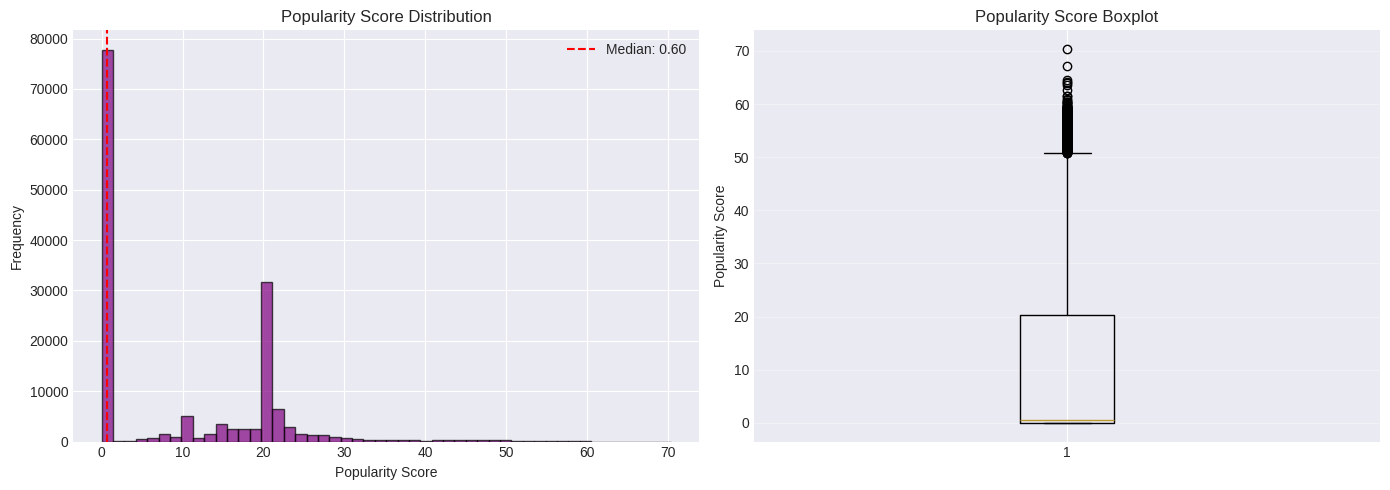


📊 Popularity Categories:
popularity_category
Kurang Populer    148943
Cukup Populer       2295
Sukses Sedang        338
Sukses Besar           2
Name: count, dtype: int64

Top 10 Most Popular Games:
                     name  popularity_score  recommendations_total  total_reviews  metacritic_score
grand theft auto v legacy         70.353964              1835735.0          100.0              96.0
                 terraria         67.111725              1143314.0          100.0              83.0
 the witcher 3: wild hunt         64.522340               784735.0           99.0              93.0
          baldur's gate 3         64.100291               687533.0          100.0              96.0
               elden ring         63.929939               784208.0          100.0              94.0
           cyberpunk 2077         63.551531               786724.0          100.0              86.0
   euro truck simulator 2         62.552481               705267.0          100.0              79.0


In [ ]:
def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

# Prepare metrics
# Ensure these columns exist, fill with 0 if not present
for col in ['recommendations_total', 'metacritic_score']:
    if col not in df_main.columns:
        df_main[col] = 0
    df_main[col] = df_main[col].fillna(0)

# Ensure 'total_reviews' and 'positive_ratio' a
df_main['total_reviews'] = df_main['total_reviews'].fillna(0)
df_main['positive_review_ratio'] = df_main['positive_review_ratio'].fillna(0.5)

# Calculate popularity score
df_main['popularity_score'] = (
    0.4 * norm(df_main['recommendations_total']) +
    0.3 * norm(df_main['total_reviews']) +
    0.2 * df_main['positive_review_ratio'] + # Using positive_review_ratio from aggregated reviews
    0.1 * (df_main['metacritic_score'] / 100)
) * 100

print(f"Popularity Score created: μ={df_main['popularity_score'].mean():.1f}, σ={df_main['popularity_score'].std():.1f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df_main['popularity_score'], bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.title('Popularity Score Distribution')
plt.axvline(df_main['popularity_score'].median(), color='red', linestyle='--',
            label=f'Median: {df_main["popularity_score"].median():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_main['popularity_score'], vert=True)
plt.ylabel('Popularity Score')
plt.title('Popularity Score Boxplot')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/popularity_score.png', dpi=300, bbox_inches='tight')
plt.show()

# Kategori Popularitas
df_main['popularity_category'] = pd.cut(
    df_main['popularity_score'],
    bins=[-0.1, 40, 55, 65, 80],
    labels=['Kurang Populer', 'Cukup Populer', 'Sukses Sedang', 'Sukses Besar']
)

print("\n📊 Popularity Categories:")
print(df_main['popularity_category'].value_counts().sort_index())

# Top 10 games
print("\nTop 10 Most Popular Games:")
top_games = df_main.nlargest(10, 'popularity_score')[
    ['name', 'popularity_score', 'recommendations_total', 'total_reviews', 'metacritic_score']
]
print(top_games.to_string(index=False))

##3. feature engineering

###Feature Engineering - Price Categories

In [ ]:
if 'mat_final_price' in df_main.columns:
    # Define price categories
    df_main['price_category'] = pd.cut(
        df_main['mat_final_price'],
        bins=[-0.1, 0.01, 10, 30, 60, float('inf')],
        labels=['Free', 'Budget', 'Mid-tier', 'Premium', 'AAA']
    )

    print("Price Categories:")
    print(df_main['price_category'].value_counts().sort_index())

    # Price-to-value ratio
    df_main['price_to_popularity_ratio'] = df_main['mat_final_price'] / (df_main['total_playtime_hours'] + 1)

    print("\n✅ Price category features created")


Price Categories:
price_category
Free        62626
Budget          0
Mid-tier        0
Premium      1745
AAA         87207
Name: count, dtype: int64

✅ Price category features created


###Feature Engineering - Achievement Density

In [ ]:
if 'mat_achievement_count' in df_main.columns:
    # Achievement density (achievements per popularity point)
    df_main['achievement_density'] = df_main['mat_achievement_count'] / (df_main['total_playtime_hours'] + 1)

    # Has achievements (binary)
    df_main['has_achievements'] = (df_main['mat_achievement_count'] > 0).astype(int)

    # Achievement categories
    df_main['achievement_category'] = pd.cut(
        df_main['mat_achievement_count'],
        bins=[-0.1, 0, 20, 50, 100, float('inf')],
        labels=['None', 'Few', 'Moderate', 'Many', 'Extensive']
    )

    print("Achievement Categories:")
    print(df_main['achievement_category'].value_counts().sort_index())

    print("\n✅ Achievement features created")

Achievement Categories:
achievement_category
None         93852
Few          32609
Moderate     18579
Many          5586
Extensive      952
Name: count, dtype: int64

✅ Achievement features created


###Feature Engineering - Platform Support

In [ ]:
platform_cols = ['mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux']
if all(col in df_main.columns for col in platform_cols):
    df_main['platform_count'] = df_main[platform_cols].sum(axis=1)

    # Is multi-platform
    df_main['is_multiplatform'] = (df_main['platform_count'] > 1).astype(int)

    # Platform combination string
    df_main['platform_combo'] = ''
    df_main.loc[df_main['mat_supports_windows'] == True, 'platform_combo'] += 'W'
    df_main.loc[df_main['mat_supports_mac'] == True, 'platform_combo'] += 'M'
    df_main.loc[df_main['mat_supports_linux'] == True, 'platform_combo'] += 'L'

    print("Platform Count Distribution:")
    print(df_main['platform_count'].value_counts().sort_index())

    print("\n✅ Platform support features created")

Platform Count Distribution:
platform_count
0         2
1       173
2        42
3    151361
Name: count, dtype: int64

✅ Platform support features created


###Feature Engineering - Time-based Features

In [ ]:
if 'days_since_release' in df_main.columns:
    # Years since release
    df_main['years_since_release'] = df_main['days_since_release'] / 365.25

    # Release era categories
    df_main['release_era'] = pd.cut(
        df_main['release_year'],
        bins=[0, 2010, 2015, 2020, 2025, 2100],
        labels=['Before 2010', '2010-2014', '2015-2019', '2020-2024', '2025+']
    )

    # Is recent (released in last 2 years)
    df_main['is_recent'] = (df_main['years_since_release'] <= 2).astype(int)

    print("Release Era Distribution:")
    print(df_main['release_era'].value_counts().sort_index())

    print("\n✅ Time-based features created")

Release Era Distribution:
release_era
Before 2010      973
2010-2014       4991
2015-2019      35564
2020-2024      75316
2025+            195
Name: count, dtype: int64

✅ Time-based features created


### Feature Engineering - Review Velocity

In [ ]:
if 'total_reviews' in df_main.columns and 'days_since_release' in df_main.columns:
    # Reviews per month since release
    df_main['review_velocity'] = (df_main['total_reviews'] / (df_main['days_since_release'] / 30 + 1))

    # Handle inf values
    df_main['review_velocity'] = df_main['review_velocity'].replace([np.inf, -np.inf], 0)

    print(f"Review Velocity Statistics:")
    print(df_main['review_velocity'].describe())

Review Velocity Statistics:
count    151578.000000
mean          0.210160
std           1.377781
min           0.000000
25%           0.000000
50%           0.013749
75%           0.091455
max         100.000000
Name: review_velocity, dtype: float64


###Feature Engineering - Engagement Score

In [ ]:
if 'total_votes_up' in df_main.columns and 'total_votes_funny' in df_main.columns:
    # Total engagement (votes)
    df_main['total_engagement_votes'] = df_main['total_votes_up'] + df_main['total_votes_funny']

    # Engagement per review
    df_main['engagement_per_review'] = df_main['total_engagement_votes'] / (df_main['total_reviews'] + 1)

    # Controversy score (high comment count relative to reviews)
    if 'total_comment_count' in df_main.columns:
        df_main['controversy_score'] = df_main['total_comment_count'] / (df_main['total_reviews'] + 1)

    print(f"Engagement per Review Statistics:")
    print(df_main['engagement_per_review'].describe())

Engagement per Review Statistics:
count    1.515780e+05
mean     1.166253e+04
std      2.846277e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.073742e+09
Name: engagement_per_review, dtype: float64


###Feature Engineering - Developer/Publisher Reputation

In [ ]:
# Developer Reputation: Average popularity of their games
if 'developers' in df_main.columns:
    # Explode developers list to individual rows
    dev_exploded = df_main[['appid', 'developers', 'recommendations_total']].explode('developers')
    dev_exploded = dev_exploded[dev_exploded['developers'].notna()]

    # Calculate average popularity per developer
    dev_reputation = dev_exploded.groupby('developers')['recommendations_total'].agg(['mean', 'count']).reset_index()
    dev_reputation.columns = ['developer', 'dev_avg_popularity', 'dev_game_count']

    # Filter developers with at least 2 games
    dev_reputation = dev_reputation[dev_reputation['dev_game_count'] >= 2]

    # Map back to main dataframe
    df_main['primary_developer'] = df_main['developers'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
    df_main = df_main.merge(
        dev_reputation[['developer', 'dev_avg_popularity', 'dev_game_count']],
        left_on='primary_developer',
        right_on='developer',
        how='left'
    )

    # Fill missing with median
    df_main['dev_avg_popularity'] = df_main['dev_avg_popularity'].fillna(df_main['dev_avg_popularity'].median())
    df_main['dev_game_count'] = df_main['dev_game_count'].fillna(1)

    # Drop temporary column
    df_main = df_main.drop('developer', axis=1)
    print(f"   Unique developers with reputation: {len(dev_reputation)}")

# Publisher Size: Number of games published
if 'publishers' in df_main.columns:
    # Explode publishers list
    pub_exploded = df_main[['appid', 'publishers']].explode('publishers')
    pub_exploded = pub_exploded[pub_exploded['publishers'].notna()]

    # Count games per publisher
    pub_size = pub_exploded.groupby('publishers').size().reset_index()
    pub_size.columns = ['publisher', 'pub_game_count']

    # Map back to main dataframe
    df_main['primary_publisher'] = df_main['publishers'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
    df_main = df_main.merge(
        pub_size,
        left_on='primary_publisher',
        right_on='publisher',
        how='left'
    )

    # Fill missing with 1
    df_main['pub_game_count'] = df_main['pub_game_count'].fillna(1)

    # Drop temporary column
    df_main = df_main.drop('publisher', axis=1)

    # Publisher size category
    df_main['publisher_size'] = pd.cut(
        df_main['pub_game_count'],
        bins=[0, 1, 5, 10, float('inf')],
        labels=['Indie', 'Small', 'Medium', 'Large']
    )

    print(f"\nPublisher Size Distribution:")
    print(df_main['publisher_size'].value_counts().sort_index())

   Unique developers with reputation: 22230

Publisher Size Distribution:
publisher_size
Indie     151578
Small          0
Medium         0
Large          0
Name: count, dtype: int64


##4. encoding

###One-Hot Encoding - Top Genres

In [ ]:
if 'genres' in df_main.columns:
    all_genres = []
    for genres_list in df_main['genres']:
        if isinstance(genres_list, list):
            all_genres.extend(genres_list)

    # Count genre frequency
    from collections import Counter
    genre_counts = Counter(all_genres)

    # Take top 20 most common genres
    top_genres = [genre for genre, count in genre_counts.most_common(20)]

    print(f"Total unique genres: {len(genre_counts)}")
    print(f"Top 20 genres selected for encoding")
    print(f"\nTop 10 Most Common Genres:")
    for genre, count in genre_counts.most_common(10):
        print(f"  {genre}: {count:,} games")

    # Create binary columns for top genres
    for genre in top_genres:
        col_name = f"genre_{genre.lower().replace(' ', '_').replace('-', '_')}"
        df_main[col_name] = df_main['genres'].apply(
            lambda x: 1 if isinstance(x, list) and genre in x else 0
        )

Total unique genres: 66
Top 20 genres selected for encoding

Top 10 Most Common Genres:
  Indie: 100,382 games
  Action: 59,990 games
  Adventure: 58,547 games
  Casual: 57,995 games
  Simulation: 30,065 games
  Strategy: 28,458 games
  RPG: 28,209 games
  Early Access: 14,487 games
  Free To Play: 13,807 games
  Sports: 5,493 games


###One-Hot Encoding - Top Categories

In [ ]:
if 'categories' in df_main.columns:
    all_categories = []
    for cat_list in df_main['categories']:
        if isinstance(cat_list, list):
            all_categories.extend(cat_list)

    # Count category frequency
    from collections import Counter
    cat_counts = Counter(all_categories)

    # Take top 20 most common categories
    top_categories = [cat for cat, count in cat_counts.most_common(20)]

    print(f"Total unique categories: {len(cat_counts)}")
    print(f"Top 15 categories selected for encoding")
    print(f"\nTop 10 Most Common Categories:")
    for cat, count in cat_counts.most_common(10):
        print(f"  {cat}: {count:,} games")

    # Create binary columns for top categories
    for cat in top_categories:
        col_name = f"cat_{cat.lower().replace(' ', '_').replace('-', '_')}"
        df_main[col_name] = df_main['categories'].apply(
            lambda x: 1 if isinstance(x, list) and cat in x else 0
        )

Total unique categories: 137
Top 15 categories selected for encoding

Top 10 Most Common Categories:
  Single-player: 133,066 games
  Family Sharing: 120,989 games
  Steam Achievements: 64,032 games
  Full controller support: 37,497 games
  Steam Cloud: 33,643 games
  Multi-player: 27,220 games
  PvP: 16,577 games
  Partial Controller Support: 16,511 games
  Co-op: 15,663 games
  Online PvP: 12,301 games


###Label Encoding - Developer & Publisher

In [ ]:
if 'primary_developer' in df_main.columns:
    df_main['has_known_developer'] = (df_main['primary_developer'] != 'Unknown').astype(int)
    print(" has_known_developer created")

if 'primary_publisher' in df_main.columns:
    df_main['has_known_publisher'] = (df_main['primary_publisher'] != 'Unknown').astype(int)
    print(" has_known_publisher created")

# Encode categorical features
label_encoder = LabelEncoder()

categorical_to_encode = ['price_category', 'achievement_category', 'release_era', 'publisher_size']

for col in categorical_to_encode:
    if col in df_main.columns:
        # Create encoded version
        encoded_col = f"{col}_encoded"
        df_main[encoded_col] = label_encoder.fit_transform(df_main[col].astype(str))
        print(f" {col} encoded as {encoded_col}")


 has_known_developer created
 has_known_publisher created
 price_category encoded as price_category_encoded
 achievement_category encoded as achievement_category_encoded
 release_era encoded as release_era_encoded
 publisher_size encoded as publisher_size_encoded


###Handle Remaining Categorical Features

In [ ]:
# One-hot encode is_free
if 'is_free' in df_main.columns:
    df_main['is_free_encoded'] = df_main['is_free'].astype(int)
    print(" is_free encoded")

# Platform combo - one-hot encode common combinations
if 'platform_combo' in df_main.columns:
    combo_counts = df_main['platform_combo'].value_counts()
    top_combos = combo_counts.head(5).index.tolist()

    for combo in top_combos:
        col_name = f"platform_combo_{combo.lower()}" if combo else "platform_combo_none"
        df_main[col_name] = (df_main['platform_combo'] == combo).astype(int)

    print(f" Created {len(top_combos)} platform combination features")

 is_free encoded
 Created 5 platform combination features


###Final Feature Set

In [ ]:
numeric_features = [
    # Original numeric features
    'mat_final_price', 'mat_initial_price', 'mat_discount_percent',
    'required_age', 'mat_achievement_count',
    'metacritic_score',

    # Review aggregated features - REMOVE target-like features from X:
    # do NOT include 'recommendations_total','total_reviews','total_playtime_hours','total_votes_up'
    'positive_review_ratio', 'avg_weighted_vote_score',
    'early_access_review_ratio', 'free_copy_ratio',
    'total_votes_funny', 'total_comment_count',

    # Count features
    'genre_count', 'category_count', 'developer_count', 'publisher_count',
    'platform_count',

    # Engineered features (avoid ones that use targets)
    'days_since_release', 'years_since_release',
    'review_velocity',  # only if constructed without leaking (it used total_reviews; consider removing if leaking)
    'price_per_playtime_hour',
    'dev_avg_recommendations', 'dev_game_count', 'pub_game_count',

    # Binary features
    'is_free_encoded', 'has_achievements', 'is_multiplatform', 'is_recent',
    'has_known_developer', 'has_known_publisher',

    # Platform support
    'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',

    # Encoded categorical
    'price_category_encoded', 'achievement_category_encoded',
    'release_era_encoded', 'publisher_size_encoded'
]

# Add genre features and category features (as before)
genre_cols = [col for col in df_main.columns if col.startswith('genre_')]
numeric_features.extend(genre_cols)
category_cols = [col for col in df_main.columns if col.startswith('cat_')]
numeric_features.extend(category_cols)
platform_combo_cols = [col for col in df_main.columns if col.startswith('platform_combo_')]
numeric_features.extend(platform_combo_cols)

# Filter only existing columns
numeric_features = [f for f in numeric_features if f in df_main.columns]

print(f"Total features selected: {len(numeric_features)}")

# Convert boolean to int
for col in numeric_features:
    if df_main[col].dtype == 'bool':
        df_main[col] = df_main[col].astype(int)

non_numeric = []
for col in numeric_features:
    if df_main[col].dtype not in ['int64', 'float64', 'int32', 'float32']:
        non_numeric.append(col)

if len(non_numeric) > 0:
    print(f" Non-numeric columns found: {non_numeric}")
    numeric_features = [f for f in numeric_features if f not in non_numeric]
else:
    print(" All features are numeric")

print(f"\nFinal feature count: {len(numeric_features)}")

Total features selected: 81
 All features are numeric

Final feature count: 81


##5. feature selection

###Correlation Analysis

Final X shape: (151578, 81)
Final y_multi shape: (151578, 4)
Targets: ['recommendations_total', 'total_playtime_hours', 'total_reviews', 'total_votes_up']
            feature1            feature2  correlation
  days_since_release years_since_release     1.000000
     publisher_count has_known_publisher     1.000000
         genre_count         genre_count     1.000000
      platform_count  platform_combo_wml     0.975309
      platform_count  mat_supports_linux     0.972884
  mat_supports_linux  platform_combo_wml     0.971918
      platform_count    mat_supports_mac     0.970634
      platform_count    is_multiplatform     0.970286
    is_multiplatform    mat_supports_mac     0.967344
     mat_final_price   mat_initial_price     0.937021
    mat_supports_mac  platform_combo_wml     0.928214
    is_multiplatform  mat_supports_linux     0.923845
  mat_supports_linux    platform_combo_w    -0.918545
      platform_count    platform_combo_w    -0.959231
    mat_supports_mac    platform_co

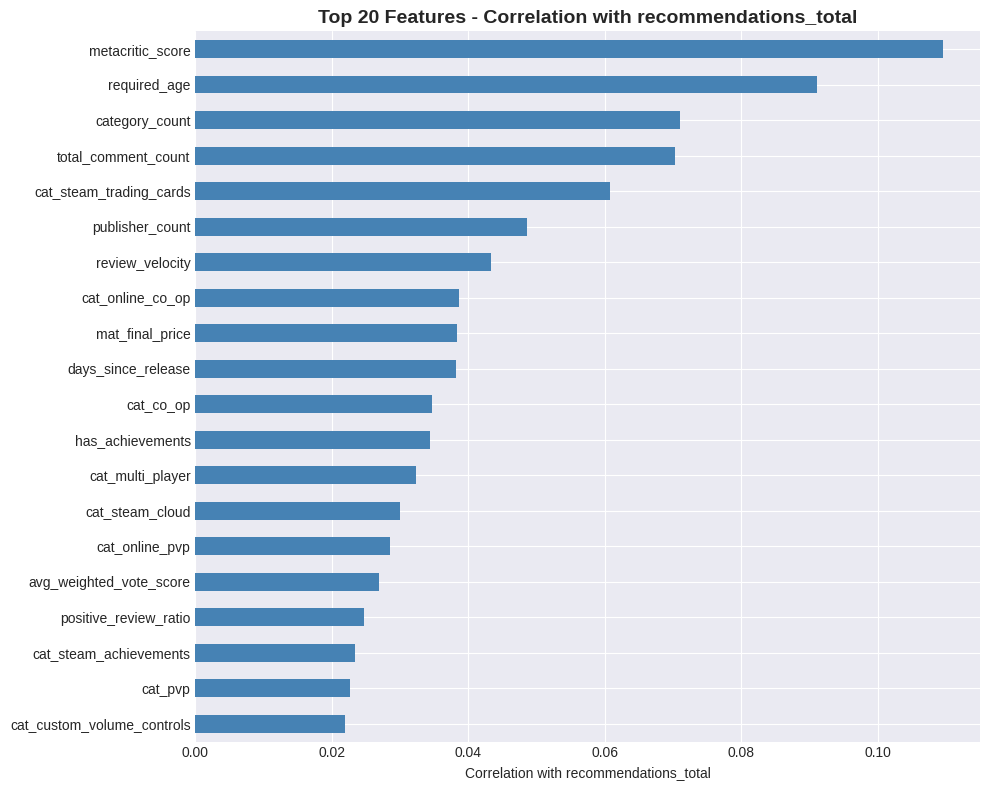

In [ ]:
# Create X from numeric_features
X = df_main[numeric_features].copy()

# Fill NaN and replace inf
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# Create multi-output target
# targets: recommendations_total, total_playtime_hours, total_reviews, total_votes_up
targets = ['recommendations_total','total_playtime_hours','total_reviews','total_votes_up']

# Ensure these exist
for t in targets:
    if t not in df_main.columns:
        df_main[t] = 0

y_multi = df_main[targets].copy()

# Optionally apply log1p transform to stabilize heavy tails (common for counts)
# We'll keep both versions: raw and log-transformed. For training, use log1p.
y_multi_log = np.log1p(y_multi)

print(f"Final X shape: {X.shape}")
print(f"Final y_multi shape: {y_multi.shape}")
print("Targets:", targets)

corr_matrix = X.corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
    print(high_corr_df.to_string(index=False))

    # Remove one feature from each highly correlated pair
    features_to_remove = set()
    for pair in high_corr_pairs:
        features_to_remove.add(pair['feature2'])

    print(f"\n Removing {len(features_to_remove)} highly correlated features:")
    for feat in features_to_remove:
        print(f"  - {feat}")

    # Update feature list
    numeric_features = [f for f in numeric_features if f not in features_to_remove]
    X = X.drop(columns=list(features_to_remove))

    print(f"\n Features after removing high correlation: {len(numeric_features)}")
else:
    print(" No highly correlated features")

# Visualize top correlations with target
primary_target = 'recommendations_total'

target_corr = X.corrwith(y_multi[primary_target]).sort_values(ascending=False)
print(f"\n Top 20 Features Correlated with {primary_target}:")
print(target_corr.head(20))

plt.figure(figsize=(10, 8))
target_corr.head(20).plot(kind='barh', color='steelblue')
plt.xlabel(f'Correlation with {primary_target}')
plt.title(f'Top 20 Features - Correlation with {primary_target}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/feature_correlation_with_target.png', dpi=300, bbox_inches='tight')
plt.show()


###Feature Importance using Random Forest

Using sample of 100,000 rows for faster computation

 Feature importance calculated!

 Top 20 Most Important Features:
                    feature  importance
           metacritic_score    0.107112
            publisher_count    0.099092
      mat_achievement_count    0.078665
             category_count    0.062450
             dev_game_count    0.058826
         days_since_release    0.056624
          total_votes_funny    0.049934
    avg_weighted_vote_score    0.041721
          cat_single_player    0.029366
                  is_recent    0.026357
            mat_final_price    0.025998
                  cat_stats    0.024571
            free_copy_ratio    0.021041
         genre_free_to_play    0.020194
               required_age    0.020028
        total_comment_count    0.019520
genre_massively_multiplayer    0.018143
      positive_review_ratio    0.017627
           cat_multi_player    0.016600
           cat_online_co_op    0.015509


<Figure size 1000x1000 with 0 Axes>

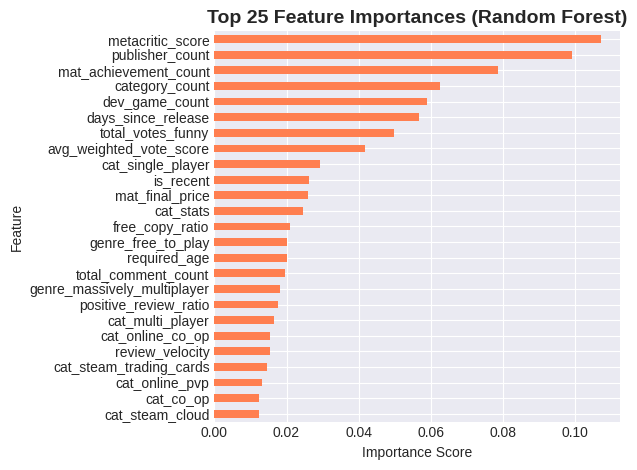

In [ ]:
# subset for faster computation
# y_single = y_multi['recommendations_total']
# if len(X) > 100000:
#     sample_size = 100000
#     sample_indices = np.random.choice(X.index, size=sample_size, replace=False)
#     X_sample = X.loc[sample_indices]
#     y_sample = y.loc[sample_indices]
#     print(f"Using sample of {sample_size:,} rows for faster computation")
# else:
#     X_sample = X
#     y_sample = y

# # Train Random Forest
# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_sample, y_sample)

# # feature importances
# feature_importance = pd.DataFrame({
#     'feature': X.columns,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)

# print("\n Feature importance calculated!")
# print(f"\n Top 20 Most Important Features:")
# print(feature_importance.head(20).to_string(index=False))

# Use single target for feature importance
y_single = y_multi['recommendations_total']

# subset for faster computation
if len(X) > 100000:
    sample_size = 100000
    sample_indices = np.random.choice(X.index, size=sample_size, replace=False)
    X_sample = X.loc[sample_indices]
    y_sample = y_single.loc[sample_indices]
    print(f"Using sample of {sample_size:,} rows for faster computation")
else:
    X_sample = X
    y_sample = y_single

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_sample, y_sample)

# feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Feature importance calculated!")
print(f"\n Top 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))


# Visualize
plt.figure(figsize=(10, 10))
feature_importance.head(25).plot(x='feature', y='importance', kind='barh', color='coral', legend=False)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 25 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project_ai/Visualisasi/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()


###Select Top Features

In [ ]:
TOP_N_FEATURES = 50

# Combine importance and correlation
# Normalize both metrics
feature_importance['importance_norm'] = (feature_importance['importance'] - feature_importance['importance'].min()) / \
                                        (feature_importance['importance'].max() - feature_importance['importance'].min())

target_corr_abs = target_corr.abs()
target_corr_norm = (target_corr_abs - target_corr_abs.min()) / (target_corr_abs.max() - target_corr_abs.min())

# Combine scores
combined_scores = pd.DataFrame({
    'feature': feature_importance['feature'],
    'combined_score': 0.5 * feature_importance['importance_norm'] + \
                      0.5 * target_corr_norm[feature_importance['feature']].values
}).sort_values('combined_score', ascending=False)

# Select top N features
selected_features = combined_scores.head(TOP_N_FEATURES)['feature'].tolist()

print(f"Selected top {TOP_N_FEATURES} features based on combined score")
print(f"\n Selected Features:")
for i, feat in enumerate(selected_features[:30], 1):
    score = combined_scores[combined_scores['feature'] == feat]['combined_score'].values[0]
    print(f"  {i}. {feat} (score: {score:.4f})")


# Create final feature matrix
X_final = X[selected_features].copy()

print(f"\n Final feature matrix shape: {X_final.shape}")
print(f"   Features: {X_final.shape[1]}")
print(f"   Samples: {X_final.shape[0]}")

Selected top 50 features based on combined score

 Selected Features:
  1. metacritic_score (score: 1.0000)
  2. publisher_count (score: 0.6840)
  3. category_count (score: 0.6155)
  4. required_age (score: 0.5090)
  5. days_since_release (score: 0.4385)
  6. mat_achievement_count (score: 0.4332)
  7. total_comment_count (score: 0.4119)
  8. cat_steam_trading_cards (score: 0.3445)
  9. avg_weighted_vote_score (score: 0.3173)
  10. dev_game_count (score: 0.3072)
  11. mat_final_price (score: 0.2958)
  12. review_velocity (score: 0.2694)
  13. cat_online_co_op (score: 0.2482)
  14. total_votes_funny (score: 0.2333)
  15. cat_multi_player (score: 0.2243)
  16. is_recent (score: 0.2199)
  17. cat_co_op (score: 0.2155)
  18. positive_review_ratio (score: 0.1948)
  19. cat_steam_cloud (score: 0.1944)
  20. cat_online_pvp (score: 0.1914)
  21. has_achievements (score: 0.1614)
  22. cat_stats (score: 0.1588)
  23. cat_single_player (score: 0.1584)
  24. achievement_category_encoded (score: 0.1

In [ ]:
proces_path = '/content/drive/MyDrive/project_ai/pre-processing/'

df_main.to_csv(f'{proces_path}processed_main_dataset.csv', index=False)

X.to_csv(f'{proces_path}X_features.csv', index=False)
y_multi.to_csv(f'{proces_path}y_targets_raw.csv', index=False)

y_multi_log.to_csv(f'{proces_path}y_targets_log1p.csv', index=False)
with open(f'{proces_path}selected_features.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

feature_importance.to_csv(f'{proces_path}feature_importance.csv', index=False)
combined_scores.to_csv(f'{proces_path}feature_combined_scores.csv', index=False)

#**MODELING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import joblib
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:

# X = pd.read_csv(f'{proces_path}X_features.csv')
# y = pd.read_csv(f'{proces_path}y_target.csv').values.ravel()  # Convert to 1D array

# # Load full dataset for stratification
# df_main = pd.read_csv(f'{proces_path}processed_main_dataset.csv')

# print(f"   Feature matrix shape: {X.shape}")
# print(f"   Target shape: {y.shape}")
# print(f"Target Statistics:")
# print(f"   Mean: {y.mean():.2f}")
# print(f"   Median: {np.median(y):.2f}")
# print(f"   Std: {y.std():.2f}")
# print(f"   Min: {y.min():.2f}")
# print(f"   Max: {y.max():.2f}")

#code 2
X = pd.read_csv(f'{proces_path}X_features.csv')
y = pd.read_csv(f'{proces_path}y_targets_log1p.csv').values  # shape (n_samples, 4)

print(f"Loaded X: {X.shape}, y: {y.shape}")

# Stratify? Multi-output stratify is tricky. We'll stratify on recommendations_total raw binned for splits.
y_primary = pd.read_csv(f'{proces_path}y_targets_raw.csv')['recommendations_total'].values
strata = pd.qcut(y_primary + 1, q=4, labels=False, duplicates='drop')

# # Load feature matrix and target
# X = pd.read_csv(f'{proces_path}X_features.csv')

# # Load full dataset for targets
# df_main = pd.read_csv(f'{proces_path}processed_main_dataset.csv')

# # Define multi-output targets
# target_columns = ['recommendations_total', 'total_playtime_hours', 'total_reviews', 'total_votes_up']

# # Ensure all target columns exist
# for col in target_columns:
#     if col not in df_main.columns:
#         df_main[col] = 0
#     else:
#         df_main[col] = df_main[col].fillna(0)

# # Extract targets as multi-output (shape: n_samples, 4)
# y = df_main[target_columns].values

# print(f"✅ Data loaded successfully!")
# print(f"   Feature matrix shape: {X.shape}")
# print(f"   Target shape: {y.shape}")
# print(f"   Target columns: {target_columns}")

# print(f"\n📊 Target Statistics:")
# target_stats = pd.DataFrame(y, columns=target_columns).describe()
# print(target_stats)

Loaded X: (151578, 70), y: (151578, 4)


##1. DATA SPLITTING

###Popularity Categories for Stratification

Stratification Groups:
recommendations_total
Low          132235
Medium            0
High              0
Very High         0
Name: count, dtype: int64


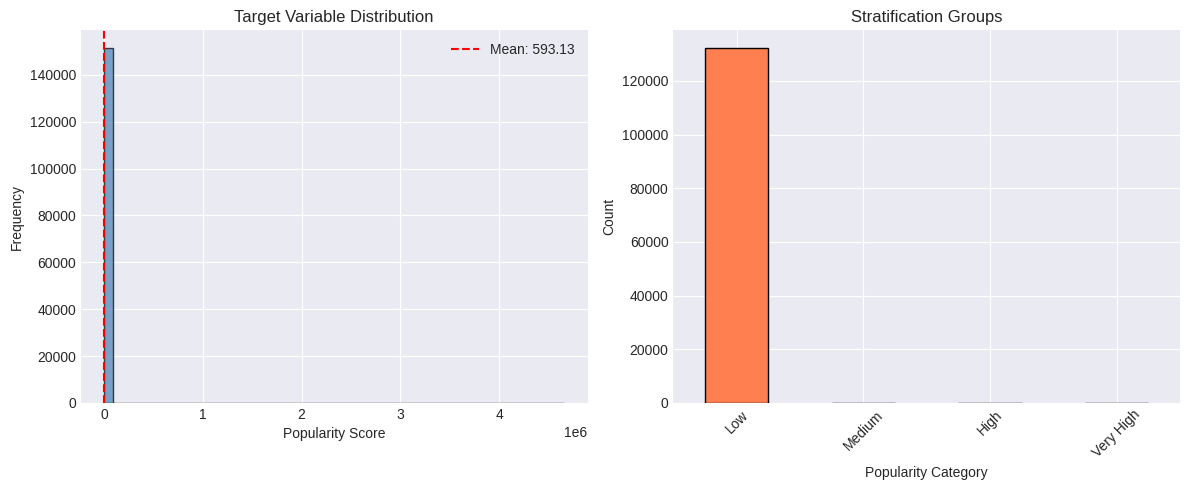

In [ ]:
visualisasi_path = '/content/drive/MyDrive/project_ai/Visualisasi/'


primary_target = y_multi['recommendations_total']

stratify_bins = pd.cut(
    primary_target,
    bins=[-0.1, 20, 40, 60, 80],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("Stratification Groups:")
print(stratify_bins.value_counts().sort_index())

# Visualize distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(primary_target, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.title('Target Variable Distribution')
plt.axvline(primary_target.mean(), color='red', linestyle='--', label=f'Mean: {primary_target.mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
stratify_bins.value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Popularity Category')
plt.ylabel('Count')
plt.title('Stratification Groups')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}target_distribution_stratified.png', dpi=300, bbox_inches='tight')
plt.show()

###Split Data - Train/Validation/Test

In [ ]:
# First split: 70% train, 30% temp (for validation + test)
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, strata,
    test_size=0.30,
    random_state=42,
    stratify=strata
)

# Second split: Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 50% of 30% = 15%
    random_state=42,
    stratify=strat_temp
)

print(f"\nDataset Sizes:")
print(f"   Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f} generalised_percentage)")
print(f"   Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f} generalised_percentage)")
print(f"   Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f} generalised_percentage)")

print(f"\nTarget Distribution Check:")
print(f"   Train mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"   Val mean: {y_val.mean():.2f}, std: {y_val.std():.2f}")
print(f"   Test mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

# X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
#     X, y, stratify_bins,
#     test_size=0.30,
#     random_state=42,
#     stratify=stratify_bins
# )

# # Second split: Split temp into validation (15%) and test (15%)
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,  # 50% of 30% = 15%
#     random_state=42,
#     stratify=strat_temp
# )

# print("✅ Data split completed!")
# print(f"\nDataset Sizes:")
# print(f"   Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
# print(f"   Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
# print(f"   Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# print(f"\nTarget Distribution Check (means per output):")
# print(f"   Train: {y_train.mean(axis=0)}")
# print(f"   Val: {y_val.mean(axis=0)}")
# print(f"   Test: {y_test.mean(axis=0)}")


Dataset Sizes:
   Train: 106,104 samples (70.0 generalised_percentage)
   Validation: 22,737 samples (15.0 generalised_percentage)
   Test: 22,737 samples (15.0 generalised_percentage)

Target Distribution Check:
   Train mean: 1.07, std: 1.81
   Val mean: 1.09, std: 1.84
   Test mean: 1.06, std: 1.80


###Feature Normalization/Scaling

In [ ]:
# scaler = StandardScaler()
model_path= '/content/drive/MyDrive/project_ai/models/'

# # # Fit on training data only
# # X_train_scaled = scaler.fit_transform(X_train)
# # X_val_scaled = scaler.transform(X_val)
# # X_test_scaled = scaler.transform(X_test)
# scaler = StandardScaler()
# scaler.fit(X_train)

# X_train_scaled = scaler.transform(X_train)
# X_val_scaled   = scaler.transform(X_val)

# print("Features scaled using StandardScaler")
# print(f"\nScaled Training Data:")
# print(f"   Mean: {X_train_scaled.mean():.6f} (should be ~0)")
# print(f"   Std: {X_train_scaled.std():.6f} (should be ~1)")

# # Save scaler for future use
# joblib.dump(scaler, f'{model_path}scaler.pkl')
# Stratify? Multi-output stratify is tricky. We'll stratify on recommendations_total raw binned for splits.
y_primary = pd.read_csv(f'{proces_path}y_targets_raw.csv')['recommendations_total'].values
strata = pd.qcut(y_primary + 1, q=4, labels=False, duplicates='drop')  # quartiles

# Train/Val/Test split: 70/15/15
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, strata, test_size=0.30, random_state=42, stratify=strata
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=strat_temp
)

print("Splits:", X_train.shape, X_val.shape, X_test.shape)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, f'{model_path}scaler.pkl')
print("✅ Scaler saved")

Splits: (106104, 70) (22737, 70) (22737, 70)
✅ Scaler saved


##2. BASELINE MODEL

###Baseline Model - Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_val_pred_lr = lr_model.predict(X_val_scaled)

# Metrics
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)

val_mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
val_rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
val_r2_lr = r2_score(y_val, y_val_pred_lr)

print("\nLinear Regression Results:")
print(f"\n Training Set:")
print(f"   MAE:  {train_mae_lr:.4f}")
print(f"   RMSE: {train_rmse_lr:.4f}")
print(f"   R²:   {train_r2_lr:.4f}")

print(f"\n Validation Set:")
print(f"   MAE:  {val_mae_lr:.4f}")
print(f"   RMSE: {val_rmse_lr:.4f}")
print(f"   R²:   {val_r2_lr:.4f}")

# Save baseline model
joblib.dump(lr_model, f'{model_path}baseline_linear_regression.pkl')


Linear Regression Results:

 Training Set:
   MAE:  0.7681
   RMSE: 1.2438
   R²:   0.5318

 Validation Set:
   MAE:  0.7751
   RMSE: 1.2433
   R²:   0.5455


['/content/drive/MyDrive/project_ai/models/baseline_linear_regression.pkl']

###desiciosn tree

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_val_pred_dt = dt_model.predict(X_val_scaled)

# Metrics
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
train_rmse_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
train_r2_dt = r2_score(y_train, y_train_pred_dt)

val_mae_dt = mean_absolute_error(y_val, y_val_pred_dt)
val_rmse_dt = np.sqrt(mean_squared_error(y_val, y_val_pred_dt))
val_r2_dt = r2_score(y_val, y_val_pred_dt)

print("\n Decision Tree Results:")
print(f"\n Training Set:")
print(f"   MAE:  {train_mae_dt:.4f}")
print(f"   RMSE: {train_rmse_dt:.4f}")
print(f"   R²:   {train_r2_dt:.4f}")

print(f"\n Validation Set:")
print(f"   MAE:  {val_mae_dt:.4f}")
print(f"   RMSE: {val_rmse_dt:.4f}")
print(f"   R²:   {val_r2_dt:.4f}")


 Decision Tree Results:

 Training Set:
   MAE:  0.3804
   RMSE: 0.8635
   R²:   0.8199

 Validation Set:
   MAE:  0.4067
   RMSE: 0.9324
   R²:   0.7990


###Baseline Comparison

            Model  Train_MAE  Train_RMSE  Train_R2  Val_MAE  Val_RMSE   Val_R2
Linear Regression   0.768059    1.243811  0.531800 0.775079  1.243272 0.545527
    Decision Tree   0.380417    0.863534  0.819947 0.406711  0.932425 0.799039


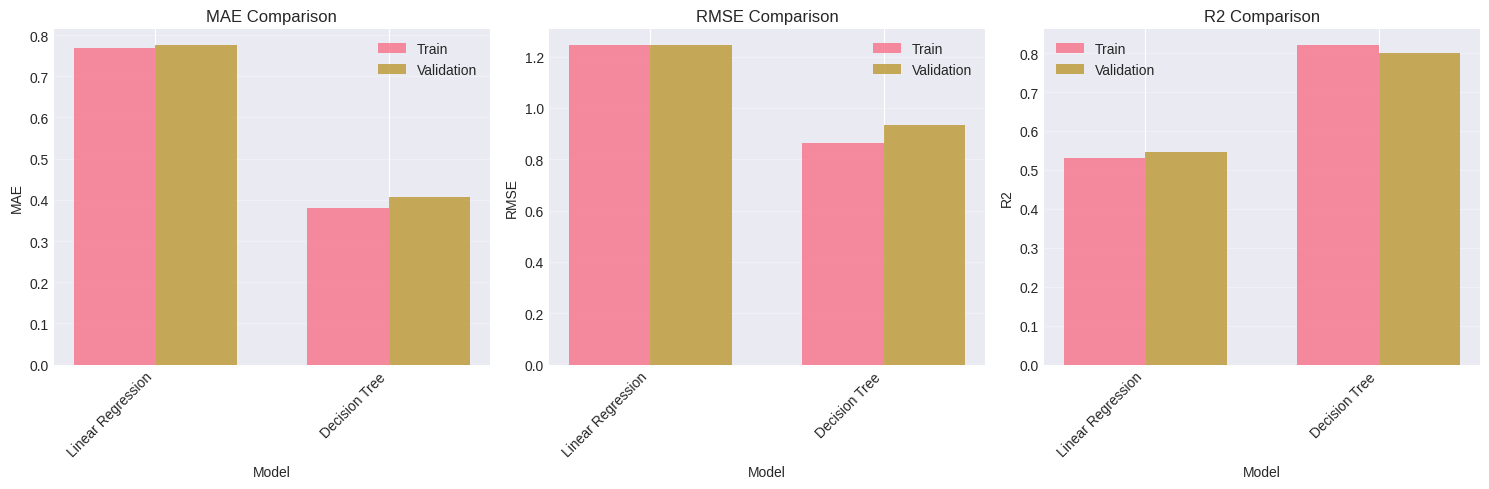

In [ ]:
baseline_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'Train_MAE': [train_mae_lr, train_mae_dt],
    'Train_RMSE': [train_rmse_lr, train_rmse_dt],
    'Train_R2': [train_r2_lr, train_r2_dt],
    'Val_MAE': [val_mae_lr, val_mae_dt],
    'Val_RMSE': [val_rmse_lr, val_rmse_dt],
    'Val_R2': [val_r2_lr, val_r2_dt]
})

print(baseline_results.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'R2']
for idx, metric in enumerate(metrics):
    train_col = f'Train_{metric}'
    val_col = f'Val_{metric}'

    x = np.arange(len(baseline_results))
    width = 0.35

    axes[idx].bar(x - width/2, baseline_results[train_col], width, label='Train', alpha=0.8)
    axes[idx].bar(x + width/2, baseline_results[val_col], width, label='Validation', alpha=0.8)
    axes[idx].set_xlabel('Model')
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(baseline_results['Model'], rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

##3. ADVANCED MODELS

###Random Forest - Hyperparameter Tuning

In [ ]:
# # from sklearn.model_selection import RandomizedSearchCV
# rf_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# # Initialize Random Forest
# rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# # Grid Search with Cross-Validation
# rf_grid_search = GridSearchCV(
#     rf_base,
#     rf_param_grid,
#     cv=3,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )

# rf_grid_search.fit(X_train_scaled, y_train)

# print("\n Hyperparameter tuning completed!")
# print(f"\n Best Parameters:")
# for param, value in rf_grid_search.best_params_.items():
#     print(f"   {param}: {value}")

# print(f"\n Best CV Score (R²): {rf_grid_search.best_score_:.4f}")

# # Get best model
# rf_model = rf_grid_search.best_estimator_
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Randomized Search (lebih cepat daripada Grid Search)
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit model
rf_random_search.fit(X_train_scaled, y_train)

print("\n Hyperparameter tuning completed!")
print(f"\n Best Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Best CV Score (R²): {rf_random_search.best_score_:.4f}")

# Get best model
rf_model = rf_random_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Hyperparameter tuning completed!

 Best Parameters:
   n_estimators: 200
   min_samples_split: 2
   min_samples_leaf: 2
   max_depth: 20

 Best CV Score (R²): 0.8568


###Random Forest - Evaluation

In [ ]:
# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)

# Metrics
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)

val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
val_r2_rf = r2_score(y_val, y_val_pred_rf)

print("\n Random Forest Results:")
print(f"\n Training Set:")
print(f"   MAE:  {train_mae_rf:.4f}")
print(f"   RMSE: {train_rmse_rf:.4f}")
print(f"   R²:   {train_r2_rf:.4f}")

print(f"\n📉 Validation Set:")
print(f"   MAE:  {val_mae_rf:.4f}")
print(f"   RMSE: {val_rmse_rf:.4f}")
print(f"   R²:   {val_r2_rf:.4f}")

# Overfitting check
r2_gap = train_r2_rf - val_r2_rf
print(f"\n🔍 Overfitting Check:")
print(f"   R² Gap (Train - Val): {r2_gap:.4f}")
if r2_gap > 0.1:
    print("   Warning: Possible overfitting detected")
else:
    print("   Good generalization")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n Top 10 Most Important Features:")
print(feature_importance_rf.head(10).to_string(index=False))

# Save model
joblib.dump(rf_model, f'{model_path}random_forest_model.pkl')


 Random Forest Results:

 Training Set:
   MAE:  0.1877
   RMSE: 0.4600
   R²:   0.9510

📉 Validation Set:
   MAE:  0.3162
   RMSE: 0.7882
   R²:   0.8645

🔍 Overfitting Check:
   R² Gap (Train - Val): 0.0866
   Good generalization

 Top 10 Most Important Features:
                feature  importance
  positive_review_ratio    0.360362
        review_velocity    0.190553
     days_since_release    0.075152
      total_votes_funny    0.071888
avg_weighted_vote_score    0.062125
cat_steam_trading_cards    0.054414
        mat_final_price    0.052487
       metacritic_score    0.033537
  mat_achievement_count    0.019066
         dev_game_count    0.012036


['/content/drive/MyDrive/project_ai/models/random_forest_model.pkl']

###XGBoost - Hyperparameter Tuning

In [ ]:
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0]
# }

# # Initialize XGBoost
# xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# # Grid Search with Cross-Validation
# xgb_grid_search = GridSearchCV(
#     xgb_base,
#     xgb_param_grid,
#     cv=3,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )

# xgb_grid_search.fit(X_train_scaled, y_train)

# print("\n Hyperparameter tuning completed!")
# print(f"\n Best Parameters:")
# for param, value in xgb_grid_search.best_params_.items():
#     print(f"   {param}: {value}")

# print(f"\n Best CV Score (R²): {xgb_grid_search.best_score_:.4f}")

# # Get best model
# xgb_model = xgb_grid_search.best_estimator_

from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize XGBoost
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Randomized Search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random_search.fit(X_train_scaled, y_train)

print("\n Hyperparameter tuning completed!")
print(f"\n Best Parameters:")
for param, value in xgb_random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n Best CV Score (R²): {xgb_random_search.best_score_:.4f}")

# Best model
xgb_model = xgb_random_search.best_estimator_


Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Hyperparameter tuning completed!

 Best Parameters:
   subsample: 0.9
   n_estimators: 300
   max_depth: 7
   learning_rate: 0.1
   colsample_bytree: 1.0

 Best CV Score (R²): 0.8748


###evaluasi


✅ XGBoost Results:

📈 Training Set:
   MAE:  0.2241
   RMSE: 0.5739
   R²:   0.9267

📉 Validation Set:
   MAE:  0.2943
   RMSE: 0.7459
   R²:   0.8807

🔍 Overfitting Check:
   R² Gap (Train - Val): 0.0460
   ✅ Good generalization!

🏆 Top 10 Most Important Features:
                feature  importance
              is_recent    0.262785
cat_steam_trading_cards    0.230992
  positive_review_ratio    0.066552
      total_votes_funny    0.057347
       metacritic_score    0.053614
        review_velocity    0.035067
avg_weighted_vote_score    0.015187
        cat_steam_cloud    0.012529
     days_since_release    0.011238
     cat_family_sharing    0.010933


<Figure size 1000x800 with 0 Axes>

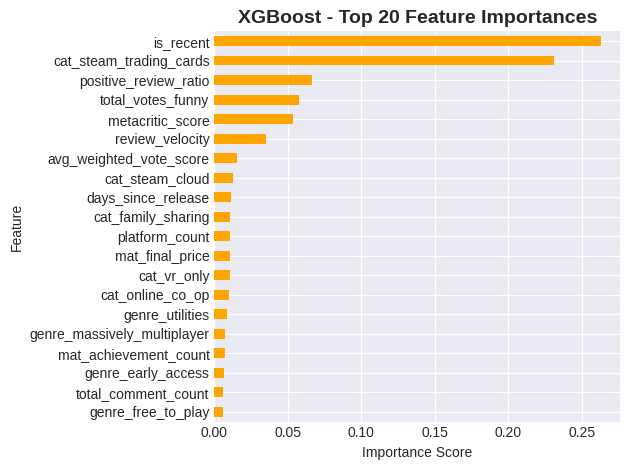

In [ ]:
# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

# Metrics
train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)

val_mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
val_rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
val_r2_xgb = r2_score(y_val, y_val_pred_xgb)

print("\n✅ XGBoost Results:")
print(f"\n📈 Training Set:")
print(f"   MAE:  {train_mae_xgb:.4f}")
print(f"   RMSE: {train_rmse_xgb:.4f}")
print(f"   R²:   {train_r2_xgb:.4f}")

print(f"\n📉 Validation Set:")
print(f"   MAE:  {val_mae_xgb:.4f}")
print(f"   RMSE: {val_rmse_xgb:.4f}")
print(f"   R²:   {val_r2_xgb:.4f}")

# Overfitting check
r2_gap_xgb = train_r2_xgb - val_r2_xgb
print(f"\n🔍 Overfitting Check:")
print(f"   R² Gap (Train - Val): {r2_gap_xgb:.4f}")
if r2_gap_xgb > 0.1:
    print("   ⚠️ Warning: Possible overfitting detected!")
else:
    print("   ✅ Good generalization!")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🏆 Top 10 Most Important Features:")
print(feature_importance_xgb.head(10).to_string(index=False))

# Save model
joblib.dump(xgb_model, f'{model_path}xgboost_model.pkl')

plt.figure(figsize=(10, 8))
feature_importance_xgb.head(20).plot(x='feature', y='importance', kind='barh', color='orange', legend=False)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('XGBoost - Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{visualisasi_path}xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("recommendation_total" in X.columns)


False


In [ ]:
print("\n🔥 Full Feature Importance Ranking (All Features):")
print(feature_importance_xgb.to_string(index=False))



🔥 Full Feature Importance Ranking (All Features):
                         feature  importance
                       is_recent    0.262785
         cat_steam_trading_cards    0.230992
           positive_review_ratio    0.066552
               total_votes_funny    0.057347
                metacritic_score    0.053614
                 review_velocity    0.035067
         avg_weighted_vote_score    0.015187
                 cat_steam_cloud    0.012529
              days_since_release    0.011238
              cat_family_sharing    0.010933
                  platform_count    0.010813
                 mat_final_price    0.010795
                     cat_vr_only    0.010455
                cat_online_co_op    0.010014
                 genre_utilities    0.008721
     genre_massively_multiplayer    0.007485
           mat_achievement_count    0.006954
              genre_early_access    0.006762
             total_comment_count    0.006157
              genre_free_to_play    0.005978
    

###Neural Network (MLP) - Build Architecture

In [ ]:
# # Define model architecture
# nn_model = keras.Sequential([
#     layers.Input(shape=(X_train_scaled.shape[1],)),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(64, activation='relu'),
#     layers.Dropout(0.2),
#     layers.Dense(32, activation='relu'),
#     layers.Dropout(0.1),
#     layers.Dense(1, activation='linear')  # Output layer for regression
# ])

# # Compile model
# nn_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss='mse',
#     metrics=['mae']
# )

# print("\n✅ Neural Network Architecture:")
# nn_model.summary()

# # Callbacks
# early_stopping = callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=20,
#     restore_best_weights=True,
#     verbose=1
# )

# reduce_lr = callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=10,
#     min_lr=0.00001,
#     verbose=1
# )

# # Create checkpoint directory
# import os
# os.makedirs('models/checkpoints', exist_ok=True)

# model_checkpoint = callbacks.ModelCheckpoint(
#     'models/checkpoints/nn_best_model.h5',
#     monitor='val_loss',
#     save_best_only=True,
#     verbose=1
# )
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(4, activation='linear')  # 🆕 4 outputs instead of 1
])

# Compile model
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n✅ Neural Network Architecture (Multi-Output):")
nn_model.summary()

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Create checkpoint directory
import os
os.makedirs('models/checkpoints', exist_ok=True)

model_checkpoint = callbacks.ModelCheckpoint(
    'models/checkpoints/nn_best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


✅ Neural Network Architecture (Multi-Output):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,556 (76.39 KB)

 Trainable params: 19,556 (76.39 KB)

 Non-trainable params: 0 (0.00 B)

###Neural Network - Training

In [ ]:
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

Epoch 1/100
3300/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8648 - mae: 0.7714
Epoch 1: val_loss improved from inf to 1.02622, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1.8629 - mae: 0.7709 - val_loss: 1.0262 - val_mae: 0.5186 - learning_rate: 0.0010
Epoch 2/100
3294/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0822 - mae: 0.5557
Epoch 2: val_loss improved from 1.02622 to 0.89990, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1.0820 - mae: 0.5557 - val_loss: 0.8999 - val_mae: 0.4673 - learning_rate: 0.0010
Epoch 3/100
3306/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9772 - mae: 0.5147
Epoch 3: val_loss improved from 0.89990 to 0.83929, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.9771 - mae: 0.5147 - val_loss: 0.8393 - val_mae: 0.4475 - learning_rate: 0.0010
Epoch 4/100
3294/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9072 - mae: 0.4918
Epoch 4: val_loss improved from 0.83929 to 0.80670, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.9072 - mae: 0.4918 - val_loss: 0.8067 - val_mae: 0.4322 - learning_rate: 0.0010
Epoch 5/100
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8839 - mae: 0.4817
Epoch 5: val_loss improved from 0.80670 to 0.80207, saving model to models/checkpoints/nn_best_model.h5


...

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.6273 - mae: 0.3809 - val_loss: 0.6390 - val_mae: 0.3416 - learning_rate: 2.5000e-04
Epoch 83/100
3302/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6289 - mae: 0.3827
Epoch 83: val_loss did not improve from 0.63896
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6289 - mae: 0.3827 - val_loss: 0.6446 - val_mae: 0.3378 - learning_rate: 2.5000e-04
Epoch 84/100
3299/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6334 - mae: 0.3829
Epoch 84: val_loss did not improve from 0.63896
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.6334 - mae: 0.3829 - val_loss: 0.6410 - val_mae: 0.3560 - learning_rate: 2.5000e-04
Epoch 85/100
3309/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6263 - mae: 0.3806
Epoch 85: val_loss improved from 0.63896 to 0.63807, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.6263 - mae: 0.3806 - val_loss: 0.6381 - val_mae: 0.3415 - learning_rate: 2.5000e-04
Epoch 86/100
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6222 - mae: 0.3790
Epoch 86: val_loss improved from 0.63807 to 0.63706, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.6222 - mae: 0.3790 - val_loss: 0.6371 - val_mae: 0.3406 - learning_rate: 2.5000e-04
Epoch 87/100
3311/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6246 - mae: 0.3798
Epoch 87: val_loss did not improve from 0.63706
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6246 - mae: 0.3798 - val_loss: 0.6398 - val_mae: 0.3458 - learning_rate: 2.5000e-04
Epoch 88/100
3304/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6258 - mae: 0.3817
Epoch 88: val_loss did not improve from 0.63706
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.6258 - mae: 0.3817 - val_loss: 0.6428 - val_mae: 0.3389 - learning_rate: 2.5000e-04
Epoch 89/100
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6243 - mae: 0.3799
Epoch 89: val_loss did not improve from 0.63706
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6243 - mae: 0.3799 - val_loss: 0.6410 - val_mae: 0.3437 - learning_rate: 2.5000e-04
Epoch 90/100
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6133 - mae: 0.3764 - val_loss: 0.6344 - val_mae: 0.3412 - learning_rate: 1.2500e-04
Epoch 98/100
3307/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6256 - mae: 0.3800
Epoch 98: val_loss did not improve from 0.63443
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.6256 - mae: 0.3800 - val_loss: 0.6356 - val_mae: 0.3414 - learning_rate: 1.2500e-04
Epoch 99/100
3305/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6125 - mae: 0.3758
Epoch 99: val_loss improved from 0.63443 to 0.63379, saving model to models/checkpoints/nn_best_model.h5


3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6125 - mae: 0.3758 - val_loss: 0.6338 - val_mae: 0.3339 - learning_rate: 1.2500e-04
Epoch 100/100
3301/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6121 - mae: 0.3741
Epoch 100: val_loss did not improve from 0.63379
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.6121 - mae: 0.3741 - val_loss: 0.6343 - val_mae: 0.3283 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 99.


###Neural Network - Evaluation & Visualization


✅ Neural Network Results (Per Output):

📈 Training Set:

  Recommendations:
    MAE:  0.4619
    RMSE: 1.0976
    R²:   0.7498

  Playtime:
    MAE:  0.4381
    RMSE: 0.7622
    R²:   0.8670

  Reviews:
    MAE:  0.0863
    RMSE: 0.1422
    R²:   0.9844

  Votes Up:
    MAE:  0.2291
    RMSE: 0.4107
    R²:   0.9271

📉 Validation Set:

  Recommendations:
    MAE:  0.5512
    RMSE: 1.3005
    R²:   0.6663

  Playtime:
    MAE:  0.4563
    RMSE: 0.7989
    R²:   0.8565

  Reviews:
    MAE:  0.0888
    RMSE: 0.1487
    R²:   0.9832

  Votes Up:
    MAE:  0.2392
    RMSE: 0.4283
    R²:   0.9208

📊 Average Validation R²: 0.8567

💾 Model saved to: models/neural_network_model.h5


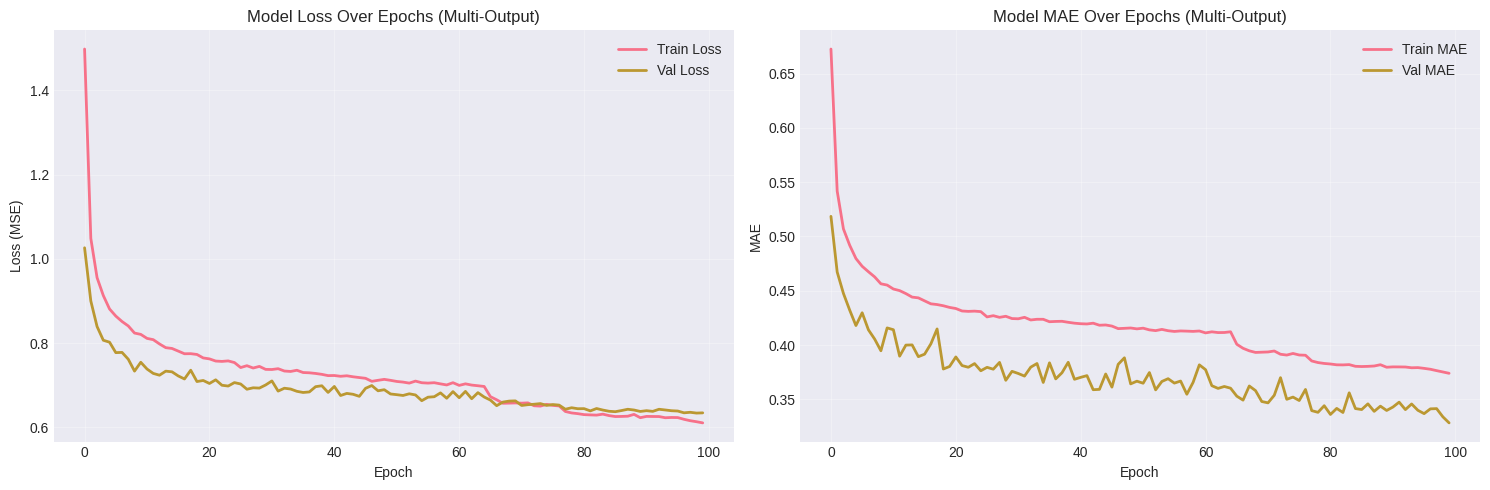

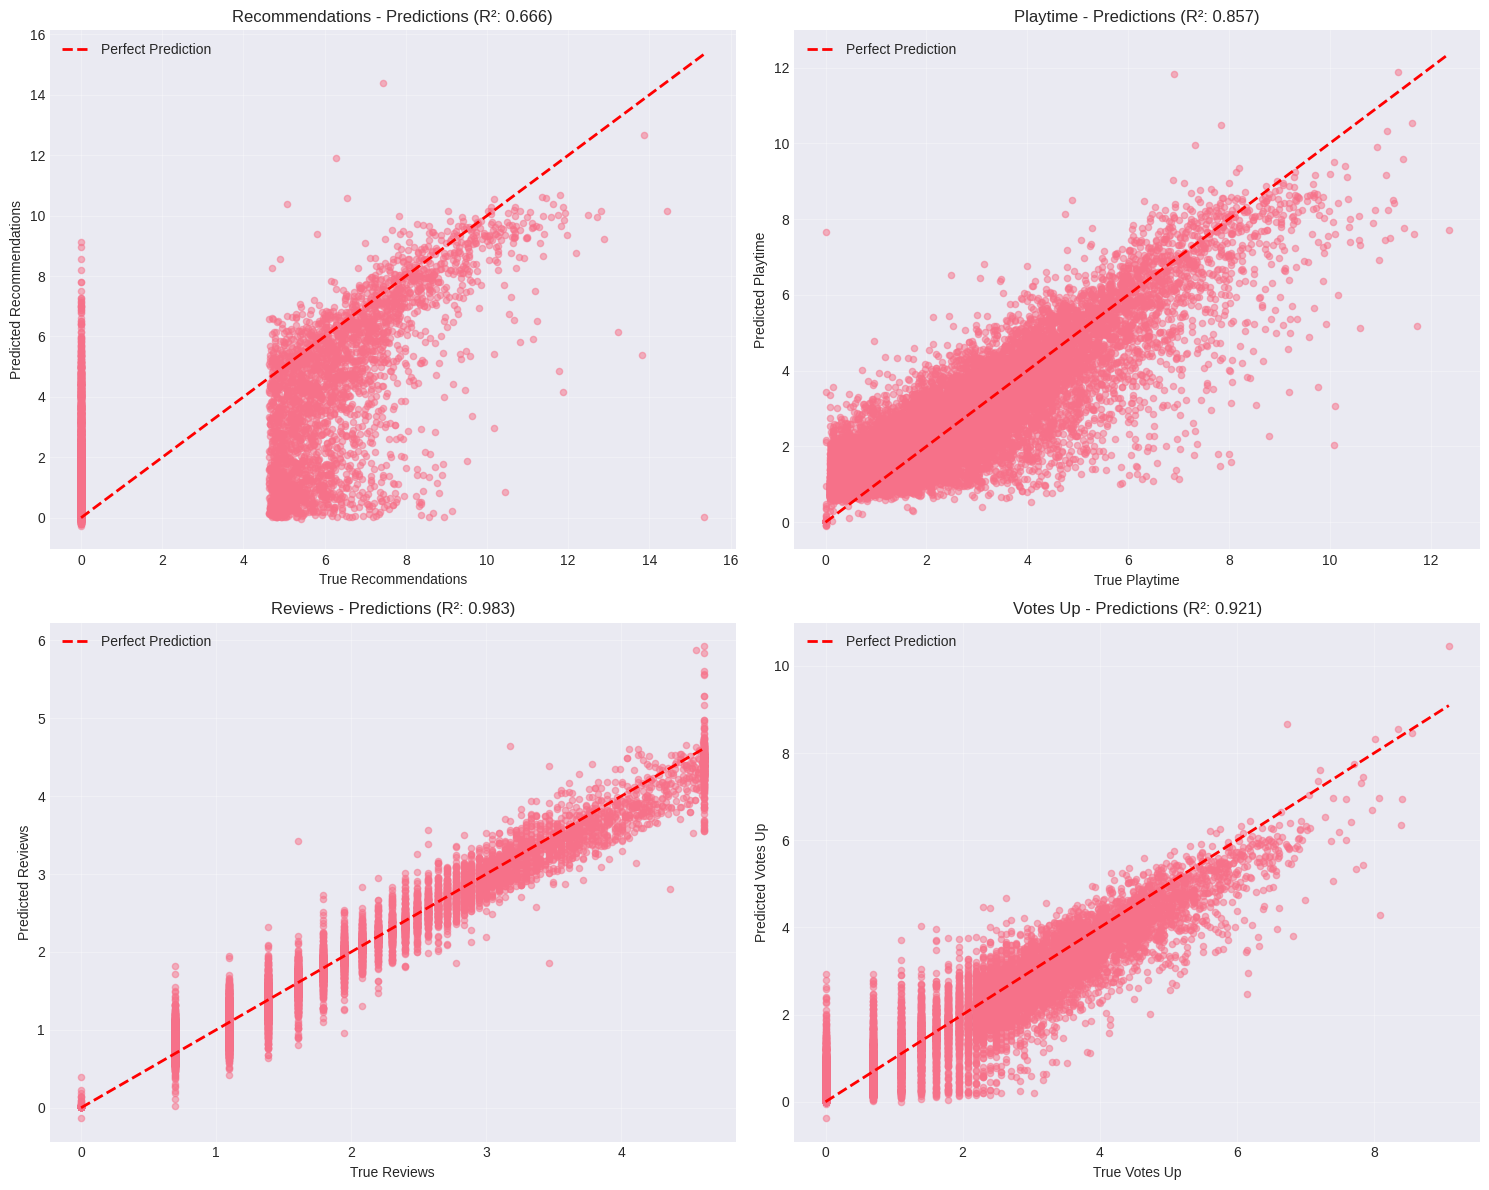

In [ ]:
# Predictions - shape: (n_samples, 4)
y_train_pred_nn = nn_model.predict(X_train_scaled, verbose=0)
y_val_pred_nn = nn_model.predict(X_val_scaled, verbose=0)

# Calculate metrics for EACH output
target_names = ['Recommendations', 'Playtime', 'Reviews', 'Votes Up']

print("\n✅ Neural Network Results (Per Output):")
print("\n📈 Training Set:")
for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_train[:, i], y_train_pred_nn[:, i])
    rmse = np.sqrt(mean_squared_error(y_train[:, i], y_train_pred_nn[:, i]))
    r2 = r2_score(y_train[:, i], y_train_pred_nn[:, i])
    print(f"\n  {name}:")
    print(f"    MAE:  {mae:.4f}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    R²:   {r2:.4f}")

print("\n📉 Validation Set:")
val_r2_scores_nn = []
for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_val[:, i], y_val_pred_nn[:, i])
    rmse = np.sqrt(mean_squared_error(y_val[:, i], y_val_pred_nn[:, i]))
    r2 = r2_score(y_val[:, i], y_val_pred_nn[:, i])
    val_r2_scores_nn.append(r2)
    print(f"\n  {name}:")
    print(f"    MAE:  {mae:.4f}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    R²:   {r2:.4f}")

# Average R² across all outputs
avg_val_r2_nn = np.mean(val_r2_scores_nn)
print(f"\n📊 Average Validation R²: {avg_val_r2_nn:.4f}")

# Save model
nn_model.save(f'{model_path}neural_network_model.h5')
print("\n💾 Model saved to: models/neural_network_model.h5")

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Model Loss Over Epochs (Multi-Output)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Model MAE Over Epochs (Multi-Output)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{model_path}nn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize predictions for each output
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, (name, ax) in enumerate(zip(target_names, axes.flat)):
    ax.scatter(y_val[:, i], y_val_pred_nn[:, i], alpha=0.5, s=20)
    ax.plot([y_val[:, i].min(), y_val[:, i].max()],
            [y_val[:, i].min(), y_val[:, i].max()],
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name} - Predictions (R²: {val_r2_scores_nn[i]:.3f})')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}nn_multi_output_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

##4. MODEL EVALUATION & SELECTION

###Compare All Models


📊 Model Comparison Table:
            Model  Train_MAE  Train_RMSE  Train_R2  Val_MAE  Val_RMSE   Val_R2    R2_Gap
Linear Regression   0.768059    1.243811  0.531800 0.775079  1.243272 0.545527 -0.013728
    Decision Tree   0.380417    0.863534  0.819947 0.406711  0.932425 0.799039  0.020908
    Random Forest   0.187722    0.460033  0.951043 0.316217  0.788200 0.864484  0.086559
          XGBoost   0.224065    0.573910  0.926658 0.294281  0.745871 0.880704  0.045954
   Neural Network   0.303852    0.603191  0.882068 0.333869  0.669109 0.856732  0.025336

 BEST MODEL: XGBoost
   Validation R²: 0.8807
   Validation MAE: 0.2943
   Validation RMSE: 0.7459


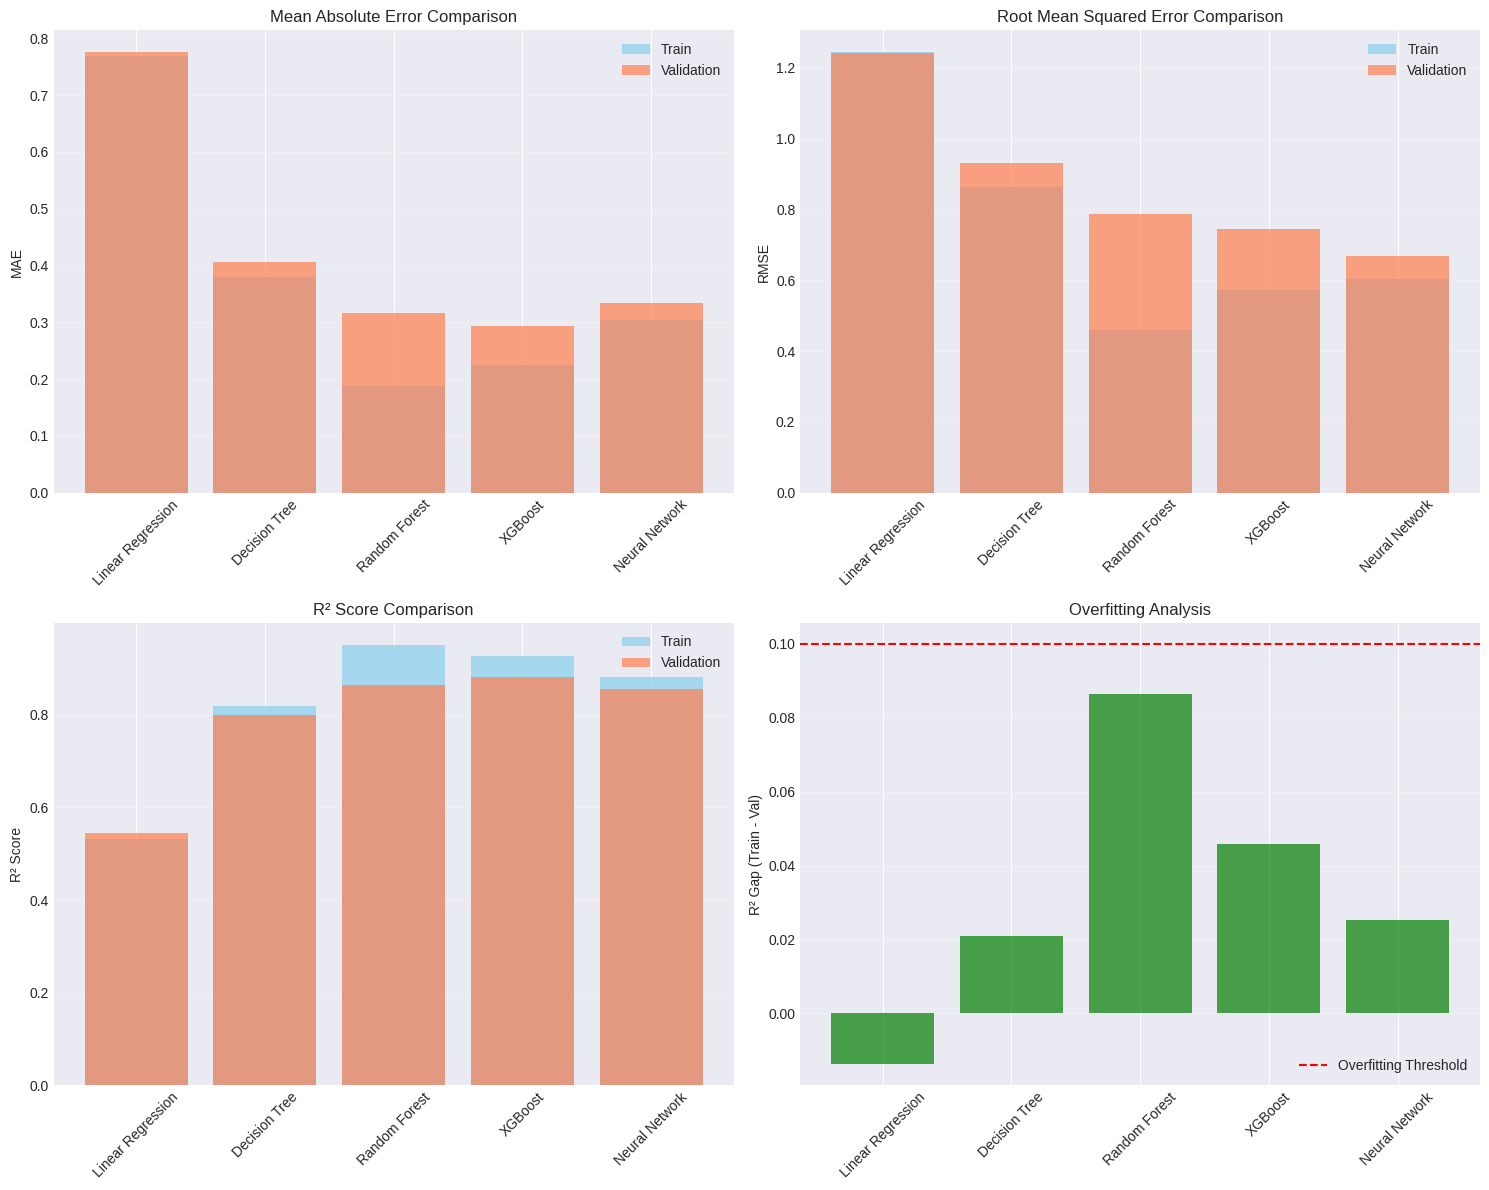

In [ ]:
y_train_pred_nn = nn_model.predict(X_train_scaled, verbose=0)
y_val_pred_nn = nn_model.predict(X_val_scaled, verbose=0)

# Calculate aggregated metrics for NN
train_mae_nn = np.mean([mean_absolute_error(y_train[:, i], y_train_pred_nn[:, i]) for i in range(y_train.shape[1])])
train_rmse_nn = np.mean([np.sqrt(mean_squared_error(y_train[:, i], y_train_pred_nn[:, i])) for i in range(y_train.shape[1])])
train_r2_nn = np.mean([r2_score(y_train[:, i], y_train_pred_nn[:, i]) for i in range(y_train.shape[1])])

val_mae_nn = np.mean([mean_absolute_error(y_val[:, i], y_val_pred_nn[:, i]) for i in range(y_val.shape[1])])
val_rmse_nn = np.mean([np.sqrt(mean_squared_error(y_val[:, i], y_val_pred_nn[:, i])) for i in range(y_val.shape[1])])
val_r2_nn = np.mean([r2_score(y_val[:, i], y_val_pred_nn[:, i]) for i in range(y_val.shape[1])])

all_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Train_MAE': [train_mae_lr, train_mae_dt, train_mae_rf, train_mae_xgb, train_mae_nn],
    'Train_RMSE': [train_rmse_lr, train_rmse_dt, train_rmse_rf, train_rmse_xgb, train_rmse_nn],
    'Train_R2': [train_r2_lr, train_r2_dt, train_r2_rf, train_r2_xgb, train_r2_nn],
    'Val_MAE': [val_mae_lr, val_mae_dt, val_mae_rf, val_mae_xgb, val_mae_nn],
    'Val_RMSE': [val_rmse_lr, val_rmse_dt, val_rmse_rf, val_rmse_xgb, val_rmse_nn],
    'Val_R2': [val_r2_lr, val_r2_dt, val_r2_rf, val_r2_xgb, val_r2_nn],
    'R2_Gap': [
        train_r2_lr - val_r2_lr,
        train_r2_dt - val_r2_dt,
        train_r2_rf - val_r2_rf,
        train_r2_xgb - val_r2_xgb,
        train_r2_nn - val_r2_nn
    ]
})

print("\n📊 Model Comparison Table:")
print(all_results.to_string(index=False))

# Save results
all_results.to_csv(f'{model_path}model_comparison.csv', index=False)

# Find best model
best_model_idx = all_results['Val_R2'].idxmax()
best_model_name = all_results.loc[best_model_idx, 'Model']
best_model_r2 = all_results.loc[best_model_idx, 'Val_R2']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Validation R²: {best_model_r2:.4f}")
print(f"   Validation MAE: {all_results.loc[best_model_idx, 'Val_MAE']:.4f}")
print(f"   Validation RMSE: {all_results.loc[best_model_idx, 'Val_RMSE']:.4f}")

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# MAE Comparison
axes[0, 0].bar(all_results['Model'], all_results['Train_MAE'], alpha=0.7, label='Train', color='skyblue')
axes[0, 0].bar(all_results['Model'], all_results['Val_MAE'], alpha=0.7, label='Validation', color='coral')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Mean Absolute Error Comparison')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# RMSE Comparison
axes[0, 1].bar(all_results['Model'], all_results['Train_RMSE'], alpha=0.7, label='Train', color='skyblue')
axes[0, 1].bar(all_results['Model'], all_results['Val_RMSE'], alpha=0.7, label='Validation', color='coral')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('Root Mean Squared Error Comparison')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1, 0].bar(all_results['Model'], all_results['Train_R2'], alpha=0.7, label='Train', color='skyblue')
axes[1, 0].bar(all_results['Model'], all_results['Val_R2'], alpha=0.7, label='Validation', color='coral')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score Comparison')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Overfitting Gap (R² Gap)
colors = ['red' if gap > 0.1 else 'green' for gap in all_results['R2_Gap']]
axes[1, 1].bar(all_results['Model'], all_results['R2_Gap'], color=colors, alpha=0.7)
axes[1, 1].axhline(y=0.1, color='red', linestyle='--', label='Overfitting Threshold')
axes[1, 1].set_ylabel('R² Gap (Train - Val)')
axes[1, 1].set_title('Overfitting Analysis')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}model_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

###Prediction Visualization - Best Model

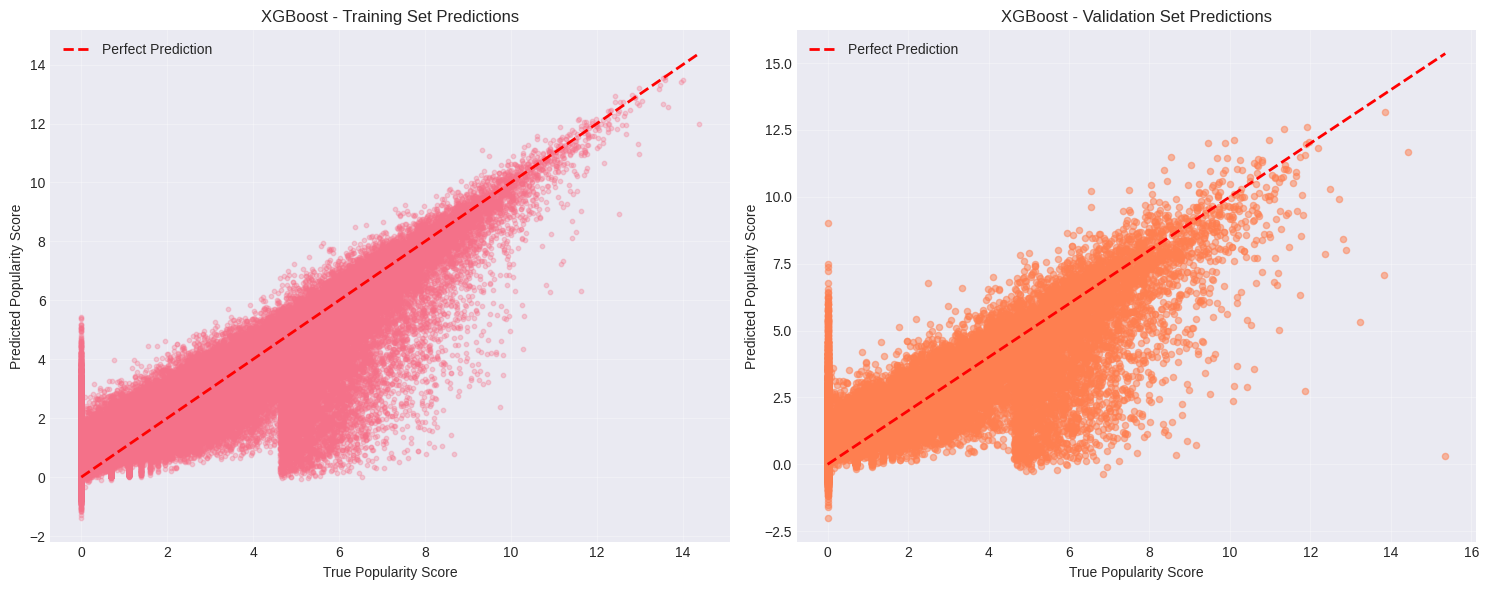

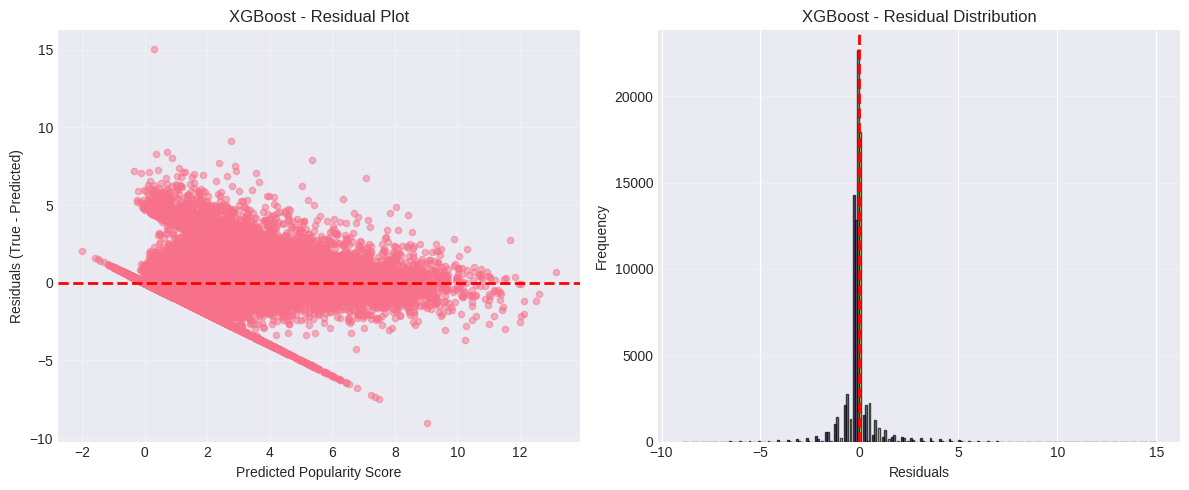

In [ ]:
# Get predictions from best model
if best_model_name == 'Random Forest':
    y_val_pred_best = y_val_pred_rf
    y_train_pred_best = y_train_pred_rf
elif best_model_name == 'XGBoost':
    y_val_pred_best = y_val_pred_xgb
    y_train_pred_best = y_train_pred_xgb
elif best_model_name == 'Neural Network':
    y_val_pred_best = y_val_pred_nn
    y_train_pred_best = y_train_pred_nn
elif best_model_name == 'Decision Tree':
    y_val_pred_best = y_val_pred_dt
    y_train_pred_best = y_train_pred_dt
else:
    y_val_pred_best = y_val_pred_lr
    y_train_pred_best = y_train_pred_lr

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training predictions
axes[0].scatter(y_train, y_train_pred_best, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True Popularity Score')
axes[0].set_ylabel('Predicted Popularity Score')
axes[0].set_title(f'{best_model_name} - Training Set Predictions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation predictions
axes[1].scatter(y_val, y_val_pred_best, alpha=0.5, s=20, color='coral')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('True Popularity Score')
axes[1].set_ylabel('Predicted Popularity Score')
axes[1].set_title(f'{best_model_name} - Validation Set Predictions')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}best_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Residual plot
residuals = y_val - y_val_pred_best

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val_pred_best, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Popularity Score')
plt.ylabel('Residuals (True - Predicted)')
plt.title(f'{best_model_name} - Residual Plot')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Determine number of targets for color list
num_targets = y_val.shape[1]
# Generate a list of distinct colors for each target's residuals
hist_colors = plt.cm.viridis(np.linspace(0, 1, num_targets)) # Using a colormap for distinct colors

plt.hist(residuals, bins=50, color=hist_colors, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title(f'{best_model_name} - Residual Distribution')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

##5. ENSEMBLE MODELS

###Ensemble - Weighted Average

In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasRegressor

voting_model = VotingRegressor(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('nn', KerasRegressor(
                model=nn_model,
                epochs=1,
                batch_size=32,
                verbose=0
            )
        )
    ],
    weights=[0.4, 0.4, 0.2]
)

# Manual weighted average
print("\nCalculating weighted average predictions...")
y_train_pred_ensemble = (0.4 * y_train_pred_rf +
                          0.4 * y_train_pred_xgb +
                          0.2 * y_train_pred_nn)

y_val_pred_ensemble = (0.4 * y_val_pred_rf +
                        0.4 * y_val_pred_xgb +
                        0.2 * y_val_pred_nn)

# Metrics
train_mae_ensemble = mean_absolute_error(y_train, y_train_pred_ensemble)
train_rmse_ensemble = np.sqrt(mean_squared_error(y_train, y_train_pred_ensemble))
train_r2_ensemble = r2_score(y_train, y_train_pred_ensemble)

val_mae_ensemble = mean_absolute_error(y_val, y_val_pred_ensemble)
val_rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_val_pred_ensemble))
val_r2_ensemble = r2_score(y_val, y_val_pred_ensemble)

print("\n Ensemble (Voting) Results:")
print(f"\n Training Set:")
print(f"   MAE:  {train_mae_ensemble:.4f}")
print(f"   RMSE: {train_rmse_ensemble:.4f}")
print(f"   R²:   {train_r2_ensemble:.4f}")

print(f"\n Validation Set:")
print(f"   MAE:  {val_mae_ensemble:.4f}")
print(f"   RMSE: {val_rmse_ensemble:.4f}")
print(f"   R²:   {val_r2_ensemble:.4f}")


Calculating weighted average predictions...

 Ensemble (Voting) Results:

 Training Set:
   MAE:  0.2152
   RMSE: 0.5296
   R²:   0.9364

 Validation Set:
   MAE:  0.2974
   RMSE: 0.7434
   R²:   0.8806


###Ensemble - Stacking Regressor

In [ ]:
from sklearn.multioutput import MultiOutputRegressor

# Base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1))
]

# Meta model
meta_model = LinearRegression()

# Create stacking regressor, wrapped with MultiOutputRegressor
stacking_model = MultiOutputRegressor(
    StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        cv=3,
        n_jobs=-1
    )
)

# Train
stacking_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_stack = stacking_model.predict(X_train_scaled)
y_val_pred_stack = stacking_model.predict(X_val_scaled)

# Metrics
train_mae_stack = np.mean([mean_absolute_error(y_train[:, i], y_train_pred_stack[:, i]) for i in range(y_train.shape[1])])
train_rmse_stack = np.mean([np.sqrt(mean_squared_error(y_train[:, i], y_train_pred_stack[:, i])) for i in range(y_train.shape[1])])
train_r2_stack = np.mean([r2_score(y_train[:, i], y_train_pred_stack[:, i]) for i in range(y_train.shape[1])])

val_mae_stack = np.mean([mean_absolute_error(y_val[:, i], y_val_pred_stack[:, i]) for i in range(y_val.shape[1])])
val_rmse_stack = np.mean([np.sqrt(mean_squared_error(y_val[:, i], y_val_pred_stack[:, i])) for i in range(y_val.shape[1])])
val_r2_stack = np.mean([r2_score(y_val[:, i], y_val_pred_stack[:, i]) for i in range(y_val.shape[1])])

print("\n Stacking Regressor Results:")
print(f"\nTraining Set:")
print(f"   MAE:  {train_mae_stack:.4f}")
print(f"   RMSE: {train_rmse_stack:.4f}")
print(f"   R²:   {train_r2_stack:.4f}")

print(f"\n Validation Set:")
print(f"   MAE:  {val_mae_stack:.4f}")
print(f"   RMSE: {val_rmse_stack:.4f}")
print(f"   R²:   {val_r2_stack:.4f}")

# Save stacking model
joblib.dump(stacking_model, f'{model_path}stacking_model.pkl')


 Stacking Regressor Results:

Training Set:
   MAE:  0.2348
   RMSE: 0.4508
   R²:   0.9271

 Validation Set:
   MAE:  0.3063
   RMSE: 0.5978
   R²:   0.8746


['/content/drive/MyDrive/project_ai/models/stacking_model.pkl']

###Final Model Comparison


 Final Model Comparison Table:
              Model  Avg_Train_R2  Avg_Val_R2
  Linear Regression      0.531800    0.545527
      Decision Tree      0.819947    0.799039
      Random Forest      0.951043    0.864484
            XGBoost      0.926658    0.880704
     Neural Network      0.882068    0.856732
  Ensemble (Voting)      0.936418    0.880627
Ensemble (Stacking)      0.927074    0.874578

 FINAL BEST MODEL: XGBoost
   Average Validation R²: 0.8807


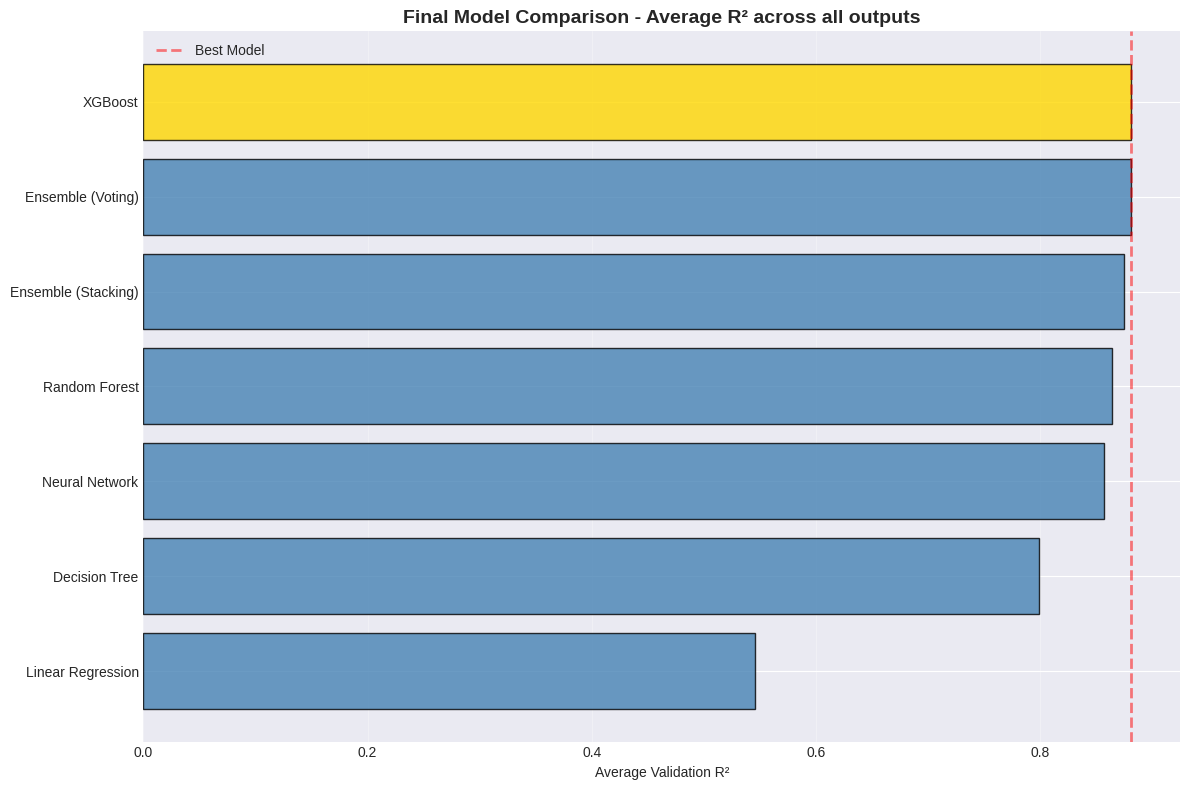

In [ ]:
final_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost',
              'Neural Network', 'Ensemble (Voting)', 'Ensemble (Stacking)'],
    'Avg_Train_R2': [train_r2_lr, train_r2_dt, train_r2_rf, train_r2_xgb,
                     np.mean([r2_score(y_train[:, i], y_train_pred_nn[:, i]) for i in range(4)]),
                     train_r2_ensemble, train_r2_stack],
    'Avg_Val_R2': [val_r2_lr, val_r2_dt, val_r2_rf, val_r2_xgb,
                   avg_val_r2_nn, val_r2_ensemble, val_r2_stack]
})

print("\n Final Model Comparison Table:")
print(final_results.to_string(index=False))

# Save results
final_results.to_csv(f'{model_path}final_model_comparison.csv', index=False)

# Find absolute best model
best_final_idx = final_results['Avg_Val_R2'].idxmax()
best_final_name = final_results.loc[best_final_idx, 'Model']
best_final_r2 = final_results.loc[best_final_idx, 'Avg_Val_R2']

print(f"\n FINAL BEST MODEL: {best_final_name}")
print(f"   Average Validation R²: {best_final_r2:.4f}")

# Visualize final comparison
plt.figure(figsize=(12, 8))
sorted_df = final_results.sort_values('Avg_Val_R2')

colors = ['gold' if model == best_final_name else 'steelblue' for model in sorted_df['Model']]

plt.barh(sorted_df['Model'], sorted_df['Avg_Val_R2'], color=colors, alpha=0.8, edgecolor='black')
plt.xlabel('Average Validation R²')
plt.title('Final Model Comparison - Average R² across all outputs', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.axvline(x=best_final_r2, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Best Model')
plt.legend()
plt.tight_layout()
plt.savefig(f'{visualisasi_path}final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


###Test Set Evaluation


Test Set Results:
   MAE:  0.2918
   RMSE: 0.7441
   R²:   0.8747

 Validation vs Test Comparison:
   Validation R²: 0.8807
   Test R²: 0.8747
   Difference: 0.0060
    Good consistency between validation and test


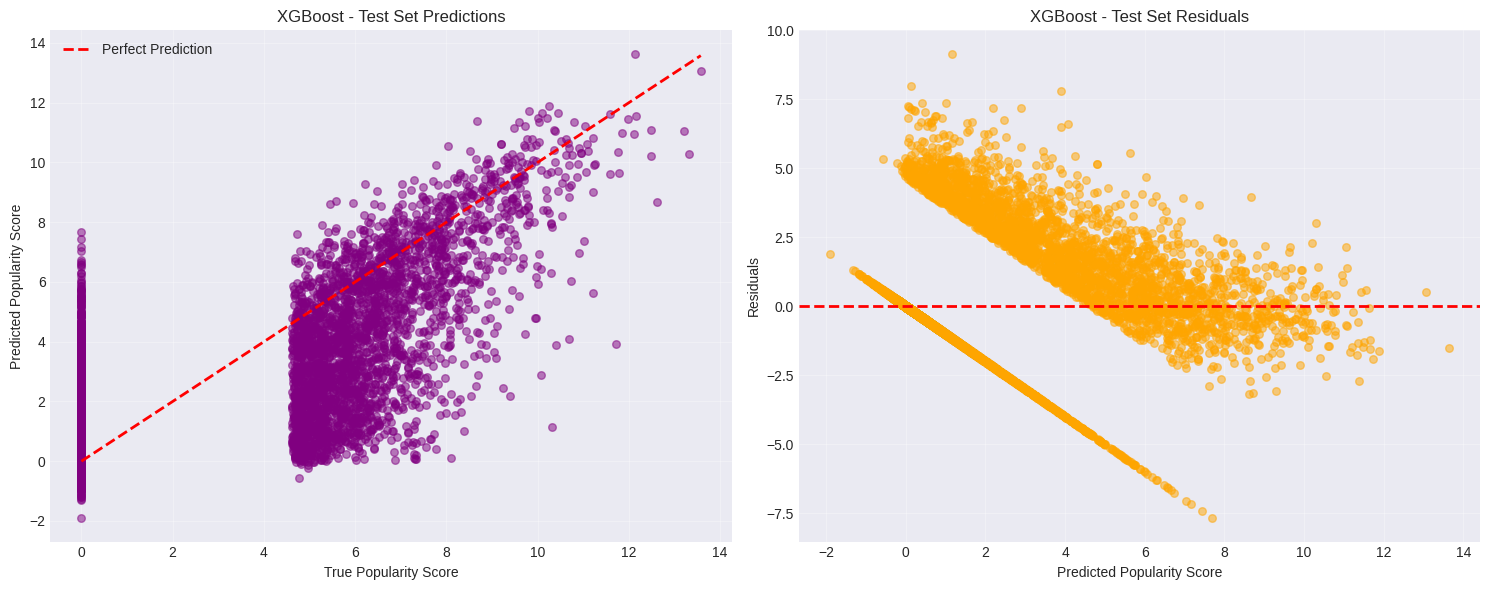

In [ ]:
if best_final_name == 'Random Forest':
    y_test_pred = rf_model.predict(X_test_scaled)
elif best_final_name == 'XGBoost':
    y_test_pred = xgb_model.predict(X_test_scaled)
elif best_final_name == 'Neural Network':
    # Removed .ravel() to maintain multi-output shape
    y_test_pred = nn_model.predict(X_test_scaled, verbose=0)
elif best_final_name == 'Ensemble (Voting)':
    y_test_pred_rf = rf_model.predict(X_test_scaled)
    y_test_pred_xgb = xgb_model.predict(X_test_scaled)
    # Removed .ravel() to maintain multi-output shape
    y_test_pred_nn = nn_model.predict(X_test_scaled, verbose=0)
    y_test_pred = 0.4 * y_test_pred_rf + 0.4 * y_test_pred_xgb + 0.2 * y_test_pred_nn
elif best_final_name == 'Ensemble (Stacking)':
    y_test_pred = stacking_model.predict(X_test_scaled)
else:
    y_test_pred = lr_model.predict(X_test_scaled)

# Calculate metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Set Results:")
print(f"   MAE:  {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   R²:   {test_r2:.4f}")

# Comparison with validation
print("\n Validation vs Test Comparison:")
val_r2 = final_results.loc[best_final_idx, 'Avg_Val_R2']
print(f"   Validation R²: {val_r2:.4f}")
print(f"   Test R²: {test_r2:.4f}")
print(f"   Difference: {abs(val_r2 - test_r2):.4f}")

if abs(val_r2 - test_r2) < 0.05:
    print("    Good consistency between validation and test")
else:
    print("    Some variation between validation and test")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
# Adjusted for multi-output: plotting only the first target for visualization example
axes[0].scatter(y_test[:, 0], y_test_pred[:, 0], alpha=0.5, s=30, color='purple')
axes[0].plot([y_test[:, 0].min(), y_test[:, 0].max()], [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True Popularity Score')
axes[0].set_ylabel('Predicted Popularity Score')
axes[0].set_title(f'{best_final_name} - Test Set Predictions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
# Adjusted for multi-output: plotting residuals for the first target
test_residuals = y_test[:, 0] - y_test_pred[:, 0]
axes[1].scatter(y_test_pred[:, 0], test_residuals, alpha=0.5, s=30, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Popularity Score')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{best_final_name} - Test Set Residuals')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}test_set_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

###Save Final Results & Model Info

In [ ]:
test_results = pd.DataFrame({
    'Model': [best_final_name],
    'Test_MAE': [test_mae],
    'Test_RMSE': [test_rmse],
    'Test_R2': [test_r2],
    'Val_R2': [val_r2],
    'R2_Difference': [abs(val_r2 - test_r2)]
})

test_results.to_csv(f'{model_path}test_set_results.csv', index=False)

# Save model metadata
model_metadata = {
    'best_model': best_final_name,
    'test_r2': float(test_r2),
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'val_r2': float(val_r2),
    'features_used': X.columns.tolist(),
    'n_features': X.shape[1],
    'n_training_samples': X_train.shape[0],
    'n_validation_samples': X_val.shape[0],
    'n_test_samples': X_test.shape[0]
}

import json
with open(f'{model_path}model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)


#**PREDIKSI DETAIL & INSIGHT**

In [ ]:
model_path= '/content/drive/MyDrive/project_ai/models/'
proces_path = '/content/drive/MyDrive/project_ai/pre-processing/'
visualisasi_path = '/content/drive/MyDrive/project_ai/Visualisasi/'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow import keras
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

##1. Build Prediction Pipeline

###Load best model and scaler

In [ ]:
scaler = joblib.load(f'{model_path}scaler.pkl')
print("✅ Scaler loaded")

# Load model (adjust based on your best model from Fase 3)
# Option 1: If best model is Neural Network (multi-output)
try:
    best_model = keras.models.load_model(f'{model_path}neural_network_model.h5')
    model_type = 'neural_network'
    print("✅ Neural Network (multi-output) loaded")
except:
    # Option 2: If best model is tree-based
    try:
        best_model = joblib.load(f'{model_path}xgboost_model.pkl')
        model_type = 'xgboost'
        print("✅ XGBoost model loaded")
    except:
        best_model = joblib.load(f'{model_path}random_forest_model.pkl')
        model_type = 'random_forest'
        print("✅ Random Forest model loaded")

# Load processed dataset for analysis
df_main = pd.read_csv(f'{proces_path}processed_main_dataset.csv')
print("✅ Main dataset loaded for reference")

# Define target names
target_names = ['recommendations_total', 'total_playtime_hours', 'total_reviews', 'total_votes_up']
print(f"\n📊 Multi-Output Targets: {target_names}")


✅ Scaler loaded
✅ XGBoost model loaded
✅ Main dataset loaded for reference

📊 Multi-Output Targets: ['recommendations_total', 'total_playtime_hours', 'total_reviews', 'total_votes_up']


###Helper Function - Predict

In [ ]:
def predict_multi_output(features_df, model, scaler, model_type='neural_network'):
    # Scale features
    features_scaled = scaler.transform(features_df)

    # Predict based on model type
    if model_type == 'neural_network':
        predictions = model.predict(features_scaled, verbose=0)
    else:
        # For tree-based models, need to wrap with MultiOutputRegressor if not already
        predictions = model.predict(features_scaled)
        # Ensure shape is (n_samples, 4)
        if len(predictions.shape) == 1:
            predictions = np.column_stack([predictions] * 4)

    # Convert to dictionary
    result = {
        'recommendations': predictions[0, 0],
        'playtime_hours': predictions[0, 1],
        'reviews': predictions[0, 2],
        'votes_up': predictions[0, 3]
    }

    return result

print("✅ Multi-output prediction function created")

✅ Multi-output prediction function created


###Derive Additional Metrics

In [ ]:
def calculate_derived_metrics(predictions, input_features):

    # Extract predictions
    recommendations = max(0, predictions['recommendations'])
    playtime_hours = max(0, predictions['playtime_hours'])
    reviews = max(0, predictions['reviews'])
    votes_up = max(0, predictions['votes_up'])

    # 1. Estimate Player Count (First Month)
    platform_count = input_features.get('platform_count', 1)
    is_free = input_features.get('is_free', 0)

    base_players = recommendations * 15  # Rough estimate: 15 players per recommendation
    platform_multiplier = 1 + (platform_count - 1) * 0.3  # +30% per additional platform
    free_multiplier = 2.0 if is_free else 1.0

    player_count_estimate = base_players * platform_multiplier * free_multiplier
    player_count_min = player_count_estimate * 0.7
    player_count_max = player_count_estimate * 1.5

    # 2. Estimate Peak Player
    peak_player_estimate = player_count_estimate * 0.18

    # 3. Estimate Positive Review Ratio
    if reviews > 0:
        positive_ratio = min(votes_up / reviews, 1.0)
    else:
        positive_ratio = 0.75  # Default assumption

    # 4. Average Playtime per Player
    if reviews > 0:
        avg_playtime_per_player = playtime_hours / reviews
    else:
        avg_playtime_per_player = playtime_hours / max(recommendations, 1)

    # 5. Engagement Score (0-100)
    engagement_score = min((votes_up / max(reviews, 1)) * 50, 100)

    # Compile all metrics
    metrics = {
        # Raw predictions
        'recommendations': int(recommendations),
        'playtime_hours': int(playtime_hours),
        'total_reviews': int(reviews),
        'votes_up': int(votes_up),

        # Derived metrics
        'player_count_min': int(player_count_min),
        'player_count_max': int(player_count_max),
        'player_count_estimate': int(player_count_estimate),
        'peak_player': int(peak_player_estimate),
        'positive_review_ratio': round(positive_ratio * 100, 1),
        'avg_playtime_per_player': round(avg_playtime_per_player, 1),
        'engagement_score': round(engagement_score, 1)
    }

    return metrics

###Complete Prediction Pipeline Function

In [ ]:
def predict_game_success(input_features_dict, model, scaler, model_type='neural_network'):

    # Load feature names from training
    feature_names = pd.read_csv(f'{proces_path}X_features.csv', nrows=0).columns.tolist()

    # Create feature vector (ensure all features are present)
    feature_vector = pd.DataFrame([input_features_dict], columns=feature_names)

    # Fill missing features with 0
    for col in feature_names:
        if col not in feature_vector.columns:
            feature_vector[col] = 0

    # Reorder to match training
    feature_vector = feature_vector[feature_names]

    # Get multi-output predictions
    predictions = predict_multi_output(feature_vector, model, scaler, model_type)

    # Calculate derived metrics
    metrics = calculate_derived_metrics(predictions, input_features_dict)

    return metrics


In [ ]:
feature_names2 = pd.read_csv(f'{proces_path}X_features.csv', nrows=0).columns.tolist()

print("Features yang MODEL expect:")
print([f for f in feature_names2 if 'genre' in f])

Features yang MODEL expect:
['genre_indie', 'genre_action', 'genre_adventure', 'genre_casual', 'genre_simulation', 'genre_strategy', 'genre_rpg', 'genre_early_access', 'genre_free_to_play', 'genre_sports', 'genre_racing', 'genre_massively_multiplayer', 'genre_utilities', 'genre_design_&_illustration', 'genre_animation_&_modeling', 'genre_education', 'genre_violent', 'genre_game_development', 'genre_video_production', 'genre_gore']


###Test Prediction Pipeline with Example

In [ ]:
example_game = {
    'mat_final_price': 19.99,
    'mat_achievement_count': 50,
    'is_free': 0,
    'mat_supports_windows': 1,
    'mat_supports_mac': 1,
    'mat_supports_linux': 1,
    'platform_count': 3,
    'genre_action': 1,
    'genre_rpg': 1,
    'genre_indie': 0,
    'cat_single_player': 1,
    'cat_multiplayer': 1,
    'cat_achievements': 1,
    'has_achievements': 1,
    'is_multiplatform': 1,
    'price_category_encoded': 2,  # Mid-tier
    'dev_avg_popularity': 65.0,
    'dev_game_count': 5,
    # Add other features as needed...
}

print("Example Game Input:")
print(f"  Genre: Action, RPG")
print(f"  Price: ${example_game['mat_final_price']}")
print(f"  Platforms: Windows, Mac, Linux")
print(f"  Achievements: {example_game['mat_achievement_count']}")

# Make prediction
try:
    prediction_result = predict_game_success(example_game, best_model, scaler, model_type)

    print("\n" + "=" * 80)
    print("🎮 PREDICTION RESULTS")
    print("=" * 80)

    print(f"\n📈 CORE PREDICTIONS:")
    print(f"  • Total Recommendations: {prediction_result['recommendations']:,}")
    print(f"  • Total Playtime: {prediction_result['playtime_hours']:,} hours")
    print(f"  • Total Reviews (3 months): {prediction_result['total_reviews']:,}")
    print(f"  • Positive Votes: {prediction_result['votes_up']:,}")

    print(f"\n👥 PLAYER ESTIMATES:")
    print(f"  • First Month Players: {prediction_result['player_count_min']:,} - {prediction_result['player_count_max']:,}")
    print(f"  • Best Estimate: {prediction_result['player_count_estimate']:,}")
    print(f"  • Peak Concurrent Players: {prediction_result['peak_player']:,}")

    print(f"\n💬 ENGAGEMENT METRICS:")
    print(f"  • Positive Review Ratio: {prediction_result['positive_review_ratio']}%")
    print(f"  • Avg Playtime per Player: {prediction_result['avg_playtime_per_player']:.1f} hours")
    print(f"  • Engagement Score: {prediction_result['engagement_score']} / 100")

except Exception as e:
    print(f"❌ Error in prediction: {e}")
    print("Note: Make sure all required features are present in example_game dict")


Example Game Input:
  Genre: Action, RPG
  Price: $19.99
  Platforms: Windows, Mac, Linux
  Achievements: 50

🎮 PREDICTION RESULTS

📈 CORE PREDICTIONS:
  • Total Recommendations: 12
  • Total Playtime: 11 hours
  • Total Reviews (3 months): 4
  • Positive Votes: 7

👥 PLAYER ESTIMATES:
  • First Month Players: 209 - 449
  • Best Estimate: 299
  • Peak Concurrent Players: 53

💬 ENGAGEMENT METRICS:
  • Positive Review Ratio: 100.0%
  • Avg Playtime per Player: 2.4 hours
  • Engagement Score: 83.0999984741211 / 100


##2. BUILD RECOMMENDATION SYSTEM

###Analyze Historical Data for Recommendations

In [ ]:
def analyze_genre_price_optimization(df):

    genre_cols = [col for col in df.columns if col.startswith('genre_')]
    genre_price_analysis = []

    for genre_col in genre_cols:
        genre_name = genre_col.replace('genre_', '').replace('_', ' ').title()
        genre_games = df[(df[genre_col] == 1) & (df['mat_final_price'] > 0)]

        if len(genre_games) > 20:  # Minimum 20 games
            # Create price bins
            genre_games['price_bin'] = pd.cut(
                genre_games['mat_final_price'],
                bins=[0, 30, 60, 90, 150, 1000],
                labels=['$0-30', '$30-60', '$60-90', '$90-150', '$150+']
            )

            # Find best performing price range
            price_performance = genre_games.groupby('price_bin')['recommendations_total'].mean()
            optimal_price_bin = price_performance.idxmax() if len(price_performance) > 0 else 'N/A'

            # Calculate statistics
            genre_price_analysis.append({
                'genre': genre_name,
                'optimal_price_range': optimal_price_bin,
                'avg_price': genre_games['mat_final_price'].mean(),
                'median_price': genre_games['mat_final_price'].median(),
                'avg_recommendations': genre_games['recommendations_total'].mean(),
                'count': len(genre_games)
            })

    return pd.DataFrame(genre_price_analysis).sort_values('avg_recommendations', ascending=False)

genre_price_data = analyze_genre_price_optimization(df_main)
print("\n💰 Optimal Price Range per Genre:")
print(genre_price_data.head(15)[['genre', 'optimal_price_range', 'median_price', 'avg_recommendations']].to_string(index=False))


# Analyze genre combinations
def analyze_genre_combinations(df):
    """Find best genre combinations"""

    genre_cols = [col for col in df.columns if col.startswith('genre_') and 'count' not in col]

    # Count how many genres each game has
    df['genre_count_temp'] = df[genre_cols].sum(axis=1)

    # Analyze multi-genre games
    combination_analysis = []

    for genre_col in genre_cols:
        # Bersihkan nama genre
        main_genre = genre_col.replace('genre_', '').replace('_', ' ').title()

        # Skip jika ini adalah kolom temporary (Safety check double)
        if 'count' in genre_col or 'temp' in genre_col:
            continue

        games_with_genre = df[df[genre_col] == 1]

        if len(games_with_genre) < 10:
            continue

        single_genre = games_with_genre[games_with_genre['genre_count_temp'] == 1]
        single_avg = single_genre['recommendations_total'].mean() if len(single_genre) > 0 else 0

        # Multi-genre performance
        multi_genre = games_with_genre[games_with_genre['genre_count_temp'] > 1]
        multi_avg = multi_genre['recommendations_total'].mean() if len(multi_genre) > 0 else 0

        # Find best companion genres
        companion_genres = []
        for other_genre_col in genre_cols:
            if other_genre_col != genre_col:
                combined = games_with_genre[games_with_genre[other_genre_col] == 1]

                if len(combined) >= 5:
                    companion_genre_name = other_genre_col.replace('genre_', '').replace('_', ' ').title()
                    companion_avg = combined['recommendations_total'].mean()

                    companion_genres.append({
                        'companion': companion_genre_name,
                        'avg_recommendations': companion_avg,
                        'count': len(combined)
                    })

        # Sort and get top 3
        companion_genres = sorted(companion_genres, key=lambda x: x['avg_recommendations'], reverse=True)[:3]

        combination_analysis.append({
            'genre': main_genre,
            'single_genre_avg': single_avg,
            'multi_genre_avg': multi_avg,
            'best_companions': [c['companion'] for c in companion_genres],
            'best_companion_performance': [c['avg_recommendations'] for c in companion_genres],
            'single_count': len(single_genre),
            'multi_count': len(multi_genre)
        })

    df.drop(columns=['genre_count_temp'], inplace=True)

    return pd.DataFrame(combination_analysis).sort_values('multi_genre_avg', ascending=False)

genre_combination_data = analyze_genre_combinations(df_main)
print("\n🎮 Best Genre Combinations:")
print(genre_combination_data.head(10)[['genre', 'single_genre_avg', 'multi_genre_avg', 'best_companions']].to_string(index=False))


# Analyze platform preference per genre
def analyze_genre_platform_preference(df):
    """Find best platform combinations for each genre"""

    genre_cols = [col for col in df.columns if col.startswith('genre_')]
    genre_platform_analysis = []

    for genre_col in genre_cols:
        genre_name = genre_col.replace('genre_', '').replace('_', ' ').title()
        genre_games = df[df[genre_col] == 1]

        if len(genre_games) < 20:
            continue

        # Analyze by platform count
        platform_performance = genre_games.groupby('platform_count').agg({
            'recommendations_total': 'mean',
            'appid': 'count'
        }).rename(columns={'appid': 'count'})

        # Find best platform count
        best_platform_count = platform_performance['recommendations_total'].idxmax() if len(platform_performance) > 0 else 1

        # Specific platform analysis
        windows_only = genre_games[(genre_games['mat_supports_windows'] == 1) &
                                   (genre_games['platform_count'] == 1)]
        all_platforms = genre_games[genre_games['platform_count'] == 3]

        genre_platform_analysis.append({
            'genre': genre_name,
            'best_platform_count': int(best_platform_count),
            'windows_only_avg': windows_only['recommendations_total'].mean() if len(windows_only) > 0 else 0,
            'all_platforms_avg': all_platforms['recommendations_total'].mean() if len(all_platforms) > 0 else 0,
            'improvement_multiplatform': ((all_platforms['recommendations_total'].mean() /
                                          max(windows_only['recommendations_total'].mean(), 1)) - 1) * 100
                                         if len(windows_only) > 0 and len(all_platforms) > 0 else 0
        })

    return pd.DataFrame(genre_platform_analysis).sort_values('improvement_multiplatform', ascending=False)

genre_platform_data = analyze_genre_platform_preference(df_main)
print("\n🖥️ Platform Recommendations per Genre:")
print(genre_platform_data.head(15)[['genre', 'best_platform_count', 'improvement_multiplatform']].to_string(index=False))


# Save for later use
genre_price_data.to_csv(f'{model_path}genre_price_optimization.csv', index=False)
genre_combination_data.to_csv(f'{model_path}genre_combinations.csv', index=False)
genre_platform_data.to_csv(f'{model_path}genre_platform_preferences.csv', index=False)


💰 Optimal Price Range per Genre:
                genre optimal_price_range  median_price  avg_recommendations
Massively Multiplayer              $30-60         599.0          4495.833022
                  Rpg               $150+         699.0          1574.868434
               Action               $150+         499.0          1281.681982
                Count               $150+         499.0          1249.598404
           Simulation               $150+         599.0           992.419495
            Adventure               $150+         599.0           974.701775
             Strategy               $150+         599.0           818.000454
         Early Access              $30-60         799.0           661.755194
                Indie               $150+         499.0           576.999418
               Racing               $150+         499.0           550.631451
               Sports              $30-60         599.0           421.501402
            Utilities               $150+ 

###Price Optimization Analysis


💵 Price Point Performance:
           recommendations_total  total_reviews  total_playtime_hours  count
price_bin                                                                   
$0-30                        NaN            NaN                   NaN      0
$30-60                127.714040       6.085387             75.688825   1745
$60-90                189.460067       5.879640             88.014417    889
$90-150                68.826187       5.595529             80.072660  10379
$150+                 405.262039       7.228114            134.710762  56213


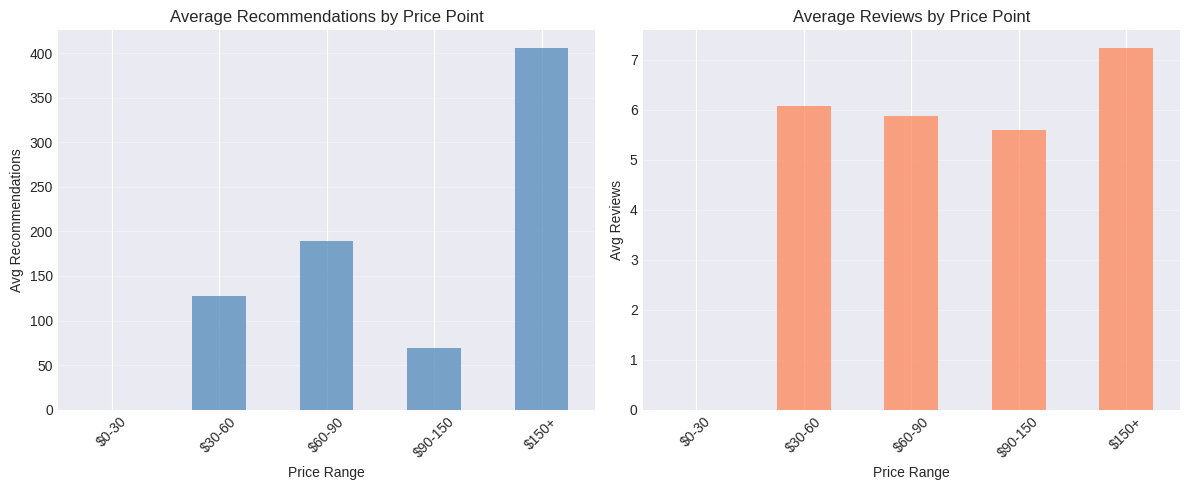

In [ ]:
def analyze_optimal_pricing(df):

    # Filter paid games only
    paid_games = df[df['mat_final_price'] > 0].copy()

    # Create price bins
    paid_games['price_bin'] = pd.cut(
        paid_games['mat_final_price'],
        bins=[0, 30, 60, 90, 150, 1000],
        labels=['$0-30', '$30-60', '$60-90', '$90-150', '$150+']
    )

    # Calculate average success per price bin
    price_performance = paid_games.groupby('price_bin').agg({
        'recommendations_total': 'mean',
        'total_reviews': 'mean',
        'total_playtime_hours': 'mean',
        'mat_final_price': 'count'
    }).rename(columns={'mat_final_price': 'count'})

    return price_performance

price_analysis = analyze_optimal_pricing(df_main)
print("\n💵 Price Point Performance:")
print(price_analysis)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
price_analysis['recommendations_total'].plot(kind='bar', color='steelblue', alpha=0.7)
plt.xlabel('Price Range')
plt.ylabel('Avg Recommendations')
plt.title('Average Recommendations by Price Point')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
price_analysis['total_reviews'].plot(kind='bar', color='coral', alpha=0.7)
plt.xlabel('Price Range')
plt.ylabel('Avg Reviews')
plt.title('Average Reviews by Price Point')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}price_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

###Category Combination Analysis


🏅 Top 10 Most Impactful Categories:
                    category      impact  count_with
         Steam Trading Cards 4038.381923       11007
                Online Co Op 2617.664675       10553
                       Co Op 1962.047330       15663
Playable Without Timed Input 1820.967609        6649
                  Online Pvp 1803.591505       12301
      Custom Volume Controls 1803.196231        7013
                Multi Player 1450.362657       27220
                         Pvp 1252.082701       16577
                 Steam Cloud 1248.068348       33643
                       Stats  836.427481        6431


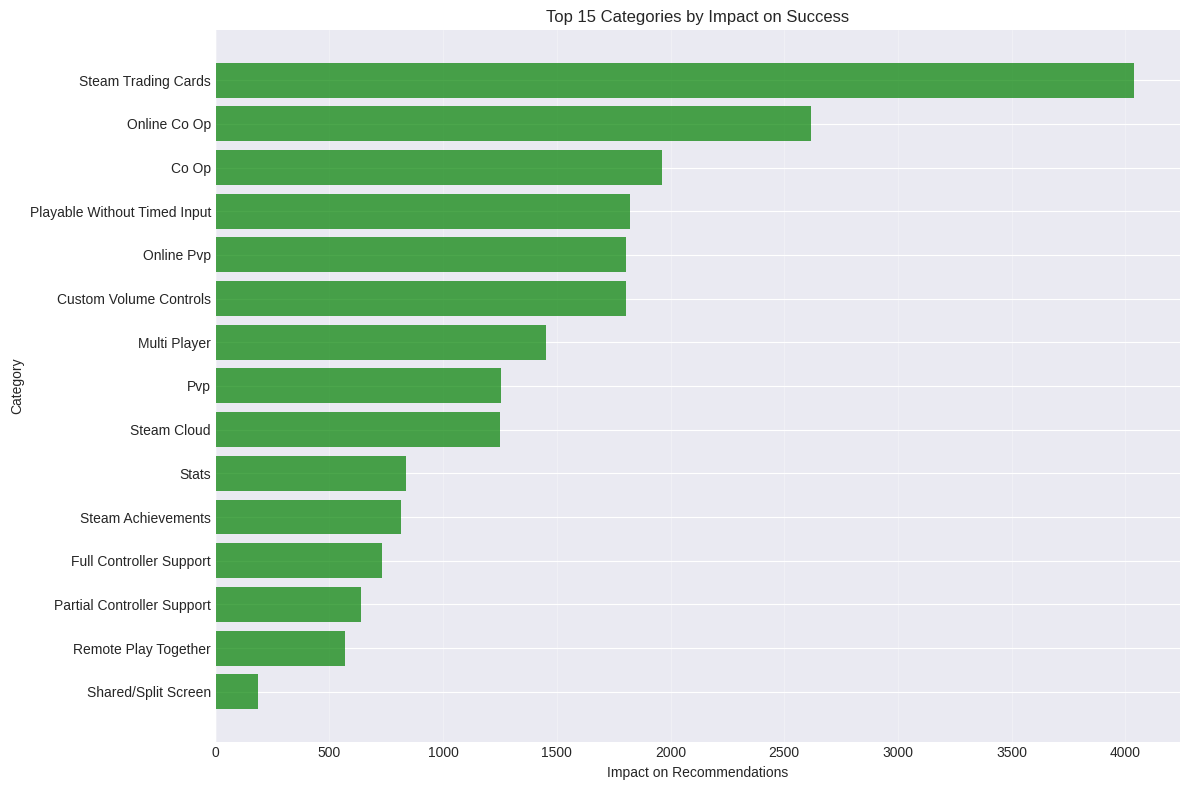

In [ ]:
def analyze_category_combinations(df):

    category_cols = [col for col in df.columns if col.startswith('cat_')]

    # Top individual categories
    category_impact = []

    for cat_col in category_cols:
        cat_name = cat_col.replace('cat_', '').replace('_', ' ').title()

        with_cat = df[df[cat_col] == 1]
        without_cat = df[df[cat_col] == 0]

        if len(with_cat) > 50 and len(without_cat) > 50:
            impact = (with_cat['recommendations_total'].mean() -
                     without_cat['recommendations_total'].mean())

            category_impact.append({
                'category': cat_name,
                'avg_with': with_cat['recommendations_total'].mean(),
                'avg_without': without_cat['recommendations_total'].mean(),
                'impact': impact,
                'count_with': len(with_cat)
            })

    return pd.DataFrame(category_impact).sort_values('impact', ascending=False)

category_analysis = analyze_category_combinations(df_main)
print("\n🏅 Top 10 Most Impactful Categories:")
print(category_analysis.head(10)[['category', 'impact', 'count_with']].to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
top_categories = category_analysis.head(15)
plt.barh(top_categories['category'], top_categories['impact'], color='green', alpha=0.7)
plt.xlabel('Impact on Recommendations')
plt.ylabel('Category')
plt.title('Top 15 Categories by Impact on Success')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{visualisasi_path}category_impact.png', dpi=300, bbox_inches='tight')
plt.show()


###Platform Support Analysis


🎮 Platform Support Impact:
               recommendations_total                total_reviews  \
                                mean median   count          mean   
platform_count                                                      
0                           0.000000    0.0       2      0.000000   
1                         320.601156    0.0     173      0.000000   
2                        7863.047619    0.0      42      0.000000   
3                         591.429787    0.0  151361      5.555024   

               total_playtime_hours  
                               mean  
platform_count                       
0                          0.000000  
1                          0.000000  
2                          0.000000  
3                        202.913013  


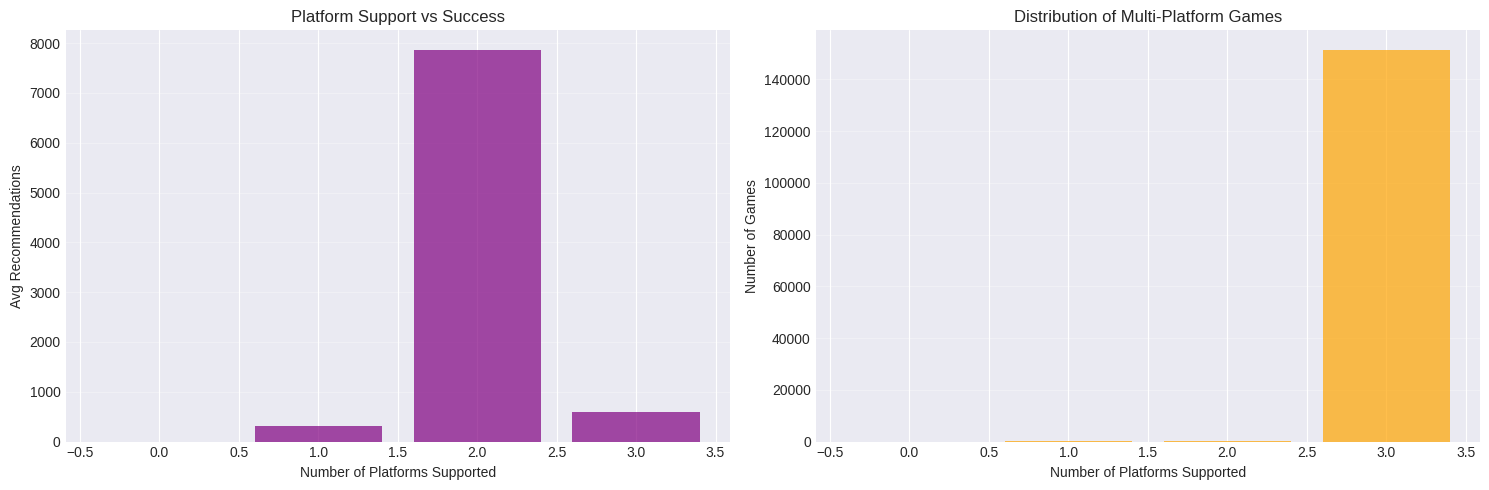

In [ ]:
def analyze_platform_impact(df):

    platform_stats = df.groupby('platform_count').agg({
        'recommendations_total': ['mean', 'median', 'count'],
        'total_reviews': 'mean',
        'total_playtime_hours': 'mean'
    })

    return platform_stats

platform_analysis = analyze_platform_impact(df_main)
print("\n🎮 Platform Support Impact:")
print(platform_analysis)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

platform_means = df_main.groupby('platform_count')['recommendations_total'].mean()
axes[0].bar(platform_means.index, platform_means.values, color='purple', alpha=0.7)
axes[0].set_xlabel('Number of Platforms Supported')
axes[0].set_ylabel('Avg Recommendations')
axes[0].set_title('Platform Support vs Success')
axes[0].grid(axis='y', alpha=0.3)

platform_counts = df_main['platform_count'].value_counts().sort_index()
axes[1].bar(platform_counts.index, platform_counts.values, color='orange', alpha=0.7)
axes[1].set_xlabel('Number of Platforms Supported')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Distribution of Multi-Platform Games')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{visualisasi_path}platform_impact.png', dpi=300, bbox_inches='tight')
plt.show()


###Build Complete Recommendation Function

In [ ]:
def generate_recommendations(prediction_metrics, input_features, df_historical):

    recommendations = {
        'current_predictions': prediction_metrics,
        'suggestions': []
    }

    # Identify primary genre(s)
    current_genres = [k.replace('genre_', '').replace('_', ' ').title()
                     for k, v in input_features.items()
                     if k.startswith('genre_') and v == 1]

    if not current_genres:
        current_genres = ['Unknown']

    primary_genre = current_genres[0]
    genre_count = len(current_genres)

    recommendations['primary_genre'] = primary_genre
    recommendations['current_genres'] = current_genres
    recommendations['genre_count'] = genre_count

    # 1. PRICE RECOMMENDATION for this genre
    genre_price_info = genre_price_data[genre_price_data['genre'] == primary_genre]

    if len(genre_price_info) > 0:
        optimal_price_range = genre_price_info.iloc[0]['optimal_price_range']
        median_price = genre_price_info.iloc[0]['median_price']
        current_price = input_features.get('mat_final_price', 0)

        # Parse optimal range
        if optimal_price_range == '$0-30':
            suggested_price_min, suggested_price_max = 5, 30
        elif optimal_price_range == '$30-60':
            suggested_price_min, suggested_price_max = 30, 60
        elif optimal_price_range == '$60-90':
            suggested_price_min, suggested_price_max = 60, 90
        elif optimal_price_range == '$90-150':
            suggested_price_min, suggested_price_max = 90, 150
        else:
            suggested_price_min, suggested_price_max = 15, 25

        price_suggestion = {
            'type': 'Price Optimization',
            'icon': '💰',
            'current_value': f"${current_price:.2f}",
            'suggested_value': f"${suggested_price_min}-${suggested_price_max}",
            'reason': f"For {primary_genre} games, the optimal price range is {optimal_price_range} (median: ${median_price:.2f})",
            'impact': 'High' if abs(current_price - median_price) > 10 else 'Medium'
        }

        if current_price < suggested_price_min or current_price > suggested_price_max:
            recommendations['suggestions'].append(price_suggestion)

    # 2. GENRE COMBINATION RECOMMENDATION
    if genre_count == 1:
        # Single genre - suggest combinations
        genre_combo_info = genre_combination_data[genre_combination_data['genre'] == primary_genre]

        if len(genre_combo_info) > 0:
            best_companions = genre_combo_info.iloc[0]['best_companions']
            single_avg = genre_combo_info.iloc[0]['single_genre_avg']
            multi_avg = genre_combo_info.iloc[0]['multi_genre_avg']

            if len(best_companions) > 0 and multi_avg > single_avg:
                companion_list = ', '.join(best_companions[:2])  # Top 2 companions
                improvement_pct = ((multi_avg / max(single_avg, 1)) - 1) * 100

                recommendations['suggestions'].append({
                    'type': 'Genre Combination',
                    'icon': '🎮',
                    'current_value': f"{primary_genre} only",
                    'suggested_value': f"Add: {companion_list}",
                    'reason': f"Games combining {primary_genre} with {companion_list} perform {improvement_pct:.1f}% better on average",
                    'impact': 'High' if improvement_pct > 50 else 'Medium'
                })
    else:
        # Multiple genres - check if combination is optimal
        genre_combo_info = genre_combination_data[genre_combination_data['genre'] == primary_genre]

        if len(genre_combo_info) > 0:
            best_companions = genre_combo_info.iloc[0]['best_companions']

            # Check if current companions are in top performers
            other_current_genres = [g for g in current_genres if g != primary_genre]
            missing_good_companions = [c for c in best_companions[:2] if c not in current_genres]

            if missing_good_companions:
                recommendations['suggestions'].append({
                    'type': 'Genre Optimization',
                    'icon': '🎮',
                    'current_value': ', '.join(current_genres),
                    'suggested_value': f"Consider adding: {', '.join(missing_good_companions)}",
                    'reason': f"These genres have shown strong synergy with {primary_genre}",
                    'impact': 'Medium'
                })

    # 3. PLATFORM RECOMMENDATION for this genre
    genre_platform_info = genre_platform_data[genre_platform_data['genre'] == primary_genre]

    if len(genre_platform_info) > 0:
        best_platform_count = genre_platform_info.iloc[0]['best_platform_count']
        improvement = genre_platform_info.iloc[0]['improvement_multiplatform']
        current_platform_count = input_features.get('platform_count', 1)

        if current_platform_count < best_platform_count:
            platform_names = []
            if best_platform_count >= 1:
                platform_names.append('Windows')
            if best_platform_count >= 2:
                platform_names.append('Mac')
            if best_platform_count >= 3:
                platform_names.append('Linux')

            current_platforms = []
            if input_features.get('mat_supports_windows', 0):
                current_platforms.append('Windows')
            if input_features.get('mat_supports_mac', 0):
                current_platforms.append('Mac')
            if input_features.get('mat_supports_linux', 0):
                current_platforms.append('Linux')

            missing_platforms = [p for p in platform_names if p not in current_platforms]

            if missing_platforms and improvement > 0:
                recommendations['suggestions'].append({
                    'type': 'Platform Support',
                    'icon': '🖥️',
                    'current_value': ', '.join(current_platforms) if current_platforms else 'Not specified',
                    'suggested_value': ', '.join(platform_names),
                    'reason': f"For {primary_genre} games, supporting {best_platform_count} platform(s) shows {improvement:.1f}% better performance",
                    'impact': 'High' if improvement > 30 else 'Medium'
                })

    # 4. CATEGORY/FEATURES RECOMMENDATION based on genre
    category_analysis_local = analyze_category_combinations(df_main)
    top_categories = category_analysis_local.head(5)['category'].str.lower().str.replace(' ', '_').tolist()

    current_categories = [k.replace('cat_', '') for k, v in input_features.items()
                         if k.startswith('cat_') and v == 1]

    missing_top_categories = [c for c in top_categories if c not in current_categories]

    if missing_top_categories:
        recommendations['suggestions'].append({
            'type': 'Game Features',
            'icon': '✨',
            'current_value': ', '.join(current_categories[:3]) if current_categories else 'None specified',
            'suggested_value': f"Add: {', '.join(missing_top_categories[:2])}",
            'reason': f"These features are highly valued across all genres including {primary_genre}",
            'impact': 'Medium'
        })

    # 5. ACHIEVEMENT RECOMMENDATION
    achievement_count = input_features.get('mat_achievement_count', 0)

    # Analyze average achievement count for this genre
    genre_games = df_main[df_main[f'genre_{primary_genre.lower().replace(" ", "_")}'] == 1] if f'genre_{primary_genre.lower().replace(" ", "_")}' in df_main.columns else df_main
    avg_achievements = genre_games[genre_games['mat_achievement_count'] > 0]['mat_achievement_count'].median()

    if not np.isnan(avg_achievements) and achievement_count < avg_achievements * 0.7:
        recommendations['suggestions'].append({
            'type': 'Achievements',
            'icon': '🏆',
            'current_value': f"{achievement_count} achievements",
            'suggested_value': f"{int(avg_achievements)} achievements (median for {primary_genre})",
            'reason': f"Most successful {primary_genre} games have around {int(avg_achievements)} achievements",
            'impact': 'Medium'
        })

    return recommendations


###Test Complete Pipeline with Recommendations

In [ ]:
test_game_rpg = {
    'mat_final_price': 39.99,
    'mat_achievement_count': 25,
    'is_free': 0,
    'mat_supports_windows': 1,
    'mat_supports_mac': 0,
    'mat_supports_linux': 0,
    'platform_count': 1,
    'genre_rpg': 1,  # Only RPG
    'cat_single_player': 1,
    'has_achievements': 1,
    'is_multiplatform': 0,
    'price_category_encoded': 3,
    'dev_avg_popularity': 55.0,
    'dev_game_count': 3,
}

print("Testing with RPG game:")
print(f"  Genre: RPG only")
print(f"  Price: ${test_game_rpg['mat_final_price']}")
print(f"  Platforms: Windows only")
print(f"  Achievements: {test_game_rpg['mat_achievement_count']}")

try:
    # Get prediction
    result = predict_game_success(test_game_rpg, best_model, scaler, model_type)

    print(f"\n📈 CORE PREDICTIONS:")
    print(f"  • Total Recommendations: {result['recommendations']:,}")
    print(f"  • Total Playtime: {result['playtime_hours']:,} hours")
    print(f"  • Total Reviews (3 months): {result['total_reviews']:,}")
    print(f"  • Positive Votes: {result['votes_up']:,}")

    print(f"\n👥 PLAYER ESTIMATES:")
    print(f"  • First Month Players: {result['player_count_min']:,} - {result['player_count_max']:,}")
    print(f"  • Peak Concurrent Players: {result['peak_player']:,}")

    print(f"\n💬 ENGAGEMENT METRICS:")
    print(f"  • Positive Review Ratio: {result['positive_review_ratio']}%")
    print(f"  • Engagement Score: {result['engagement_score']} / 100")

    # Get genre-specific recommendations
    recommendations = generate_recommendations(result, test_game_rpg, df_main)

    print("\n" + "=" * 80)
    print(" GENRE-SPECIFIC RECOMMENDATIONS")
    print("=" * 80)
    print(f"\nPrimary Genre: {recommendations['primary_genre']}")
    print(f"Current Genres: {', '.join(recommendations['current_genres'])}\n")

    if recommendations['suggestions']:
        for i, rec in enumerate(recommendations['suggestions'], 1):
            print(f"{i}. {rec['icon']} {rec['type'].upper()}")
            print(f"   Current: {rec['current_value']}")
            print(f"   Suggested: {rec['suggested_value']}")
            print(f"   Reason: {rec['reason']}")
            print(f"   Impact: {rec['impact']}\n")
    else:
        print("✨ No specific recommendations. Current configuration looks good!")

except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

Testing with RPG game:
  Genre: RPG only
  Price: $39.99
  Platforms: Windows only
  Achievements: 25

📈 CORE PREDICTIONS:
  • Total Recommendations: 11
  • Total Playtime: 11 hours
  • Total Reviews (3 months): 4
  • Positive Votes: 8

👥 PLAYER ESTIMATES:
  • First Month Players: 116 - 249
  • Peak Concurrent Players: 29

💬 ENGAGEMENT METRICS:
  • Positive Review Ratio: 100.0%
  • Engagement Score: 85.5 / 100

 GENRE-SPECIFIC RECOMMENDATIONS

Primary Genre: Rpg
Current Genres: Rpg

1. 💰 PRICE OPTIMIZATION
   Current: $39.99
   Suggested: $15-$25
   Reason: For Rpg games, the optimal price range is $150+ (median: $699.00)
   Impact: High

2. 🖥️ PLATFORM SUPPORT
   Current: Windows
   Suggested: Windows, Mac, Linux
   Reason: For Rpg games, supporting 3 platform(s) shows 384.7% better performance
   Impact: High

3. ✨ GAME FEATURES
   Current: single_player
   Suggested: Add: steam_trading_cards, online_co_op
   Reason: These features are highly valued across all genres including Rpg
  

###Create Formatted Output Function

In [ ]:
def create_game_report(input_features, model, scaler, model_type, df_historical):

    # Get predictions
    predictions = predict_game_success(input_features, model, scaler, model_type)

    # Get recommendations
    recs = generate_recommendations(predictions, input_features, df_historical)

    # Format report
    report = f"""
{'='*80}
                    🎮 GAME SUCCESS PREDICTION REPORT
{'='*80}

PRIMARY GENRE: {recs['primary_genre']}
ALL GENRES: {', '.join(recs['current_genres'])}

{'='*80}
📈 CORE PREDICTIONS
{'='*80}

Multi-Output Model Predictions:
  • Total Recommendations: {predictions['recommendations']:,}
  • Total Playtime: {predictions['playtime_hours']:,} hours
  • Total Reviews (3 months): {predictions['total_reviews']:,}
  • Positive Votes: {predictions['votes_up']:,}

{'='*80}
👥 PLAYER ESTIMATES
{'='*80}

  • First Month Players: {predictions['player_count_min']:,} - {predictions['player_count_max']:,}
  • Best Estimate: {predictions['player_count_estimate']:,}
  • Peak Concurrent Players: {predictions['peak_player']:,}

{'='*80}
💬 ENGAGEMENT METRICS
{'='*80}

  • Positive Review Ratio: {predictions['positive_review_ratio']}%
  • Avg Playtime per Player: {predictions['avg_playtime_per_player']:.1f} hours
  • Engagement Score: {predictions['engagement_score']} / 100

{'='*80}
💡 GENRE-SPECIFIC RECOMMENDATIONS FOR {recs['primary_genre'].upper()}
{'='*80}
"""

    if recs['suggestions']:
        for i, rec in enumerate(recs['suggestions'], 1):
            report += f"""
{i}. {rec['icon']} {rec['type'].upper()}
   Current: {rec['current_value']}
   Suggested: {rec['suggested_value']}
   Reason: {rec['reason']}
   Impact: {rec['impact']}
"""
    else:
        report += "\n✨ No specific recommendations. Current configuration looks optimal for this genre!\n"

    report += f"\n{'='*80}\n"

    return report

###Interactive Prediction Interface

In [ ]:
def interactive_game_predictor():

    print("\n" + "="*80)
    print("🎮 GAME SUCCESS PREDICTOR - INTERACTIVE MODE")
    print("="*80)

    # Get user input
    print("\nPlease enter game details:\n")

    game_input = {}

    # Basic info
    print("📝 BASIC INFORMATION:")
    game_input['mat_final_price'] = float(input("  Price (USD): $") or "19.99")
    game_input['is_free'] = 1 if game_input['mat_final_price'] == 0 else 0
    game_input['mat_achievement_count'] = int(input("  Number of Achievements: ") or "30")
    game_input['has_achievements'] = 1 if game_input['mat_achievement_count'] > 0 else 0

    # Platform support
    print("\n🖥️ PLATFORM SUPPORT:")
    windows = input("  Support Windows? (y/n): ").lower() == 'y'
    mac = input("  Support Mac? (y/n): ").lower() == 'y'
    linux = input("  Support Linux? (y/n): ").lower() == 'y'

    game_input['mat_supports_windows'] = 1 if windows else 0
    game_input['mat_supports_mac'] = 1 if mac else 0
    game_input['mat_supports_linux'] = 1 if linux else 0
    game_input['platform_count'] = sum([windows, mac, linux])
    game_input['is_multiplatform'] = 1 if game_input['platform_count'] > 1 else 0

    # Genre selection
    print("\n🎮 GENRE (Select all that apply):")
    print("  1. Action  2. RPG  3. Strategy  4. Adventure  5. Indie")
    print("  6. Simulation  7. Sports  8. Puzzle  9. Horror  10. Casual")

    genre_selection = input("  Enter numbers separated by comma (e.g., 1,2,5): ")

    genre_map = {
        '1': 'action', '2': 'rpg', '3': 'strategy', '4': 'adventure', '5': 'indie',
        '6': 'simulation', '7': 'sports', '8': 'puzzle', '9': 'horror', '10': 'casual'
    }

    for num in genre_selection.split(','):
        num = num.strip()
        if num in genre_map:
            game_input[f'genre_{genre_map[num]}'] = 1

    # Categories
    print("\n✨ FEATURES (Select all that apply):")
    print("  1. Single-player  2. Multiplayer  3. Co-op  4. Achievements")
    print("  5. Controller Support  6. Cloud Saves  7. Workshop  8. Trading Cards")

    category_selection = input("  Enter numbers separated by comma: ")

    category_map = {
        '1': 'single_player', '2': 'multiplayer', '3': 'co_op', '4': 'achievements',
        '5': 'full_controller_support', '6': 'cloud_saves', '7': 'workshop',
        '8': 'steam_trading_cards'
    }

    for num in category_selection.split(','):
        num = num.strip()
        if num in category_map:
            game_input[f'cat_{category_map[num]}'] = 1

    # Developer info
    print("\n👨‍💻 DEVELOPER INFORMATION:")
    game_input['dev_game_count'] = int(input("  Number of previous games: ") or "3")
    game_input['dev_avg_popularity'] = float(input("  Average popularity of previous games (0-100): ") or "60")

    # Set price category
    if game_input['mat_final_price'] == 0:
        game_input['price_category_encoded'] = 0  # Free
    elif game_input['mat_final_price'] <= 10:
        game_input['price_category_encoded'] = 1  # Budget
    elif game_input['mat_final_price'] <= 30:
        game_input['price_category_encoded'] = 2  # Mid-tier
    elif game_input['mat_final_price'] <= 60:
        game_input['price_category_encoded'] = 3  # Premium
    else:
        game_input['price_category_encoded'] = 4  # AAA

    return game_input

###Batch Prediction for Multiple Games

In [ ]:
def batch_predict_games(games_list, model, scaler, model_type, df_historical):

    results = []

    for i, game in enumerate(games_list):
        print(f"Processing game {i+1}/{len(games_list)}...", end='\r')

        try:
            prediction = predict_game_success(game, model, scaler, model_type)

            result = {
                'game_id': i + 1,
                'category': prediction['success_category'],
                'recommendations': prediction['recommendations'],
                'reviews': prediction['total_reviews'],
                'player_estimate': prediction['player_count_estimate'],
                'peak_player': prediction['peak_player'],
                'positive_ratio': prediction['positive_review_ratio']
            }

            results.append(result)

        except Exception as e:
            print(f"\nError processing game {i+1}: {e}")
            continue

    print("\n✅ Batch prediction completed!")
    return pd.DataFrame(results)

###Scenario Analysis - Compare Different Configurations

In [ ]:
def scenario_analysis(base_game, scenarios, model, scaler, model_type):

    results = []

    # Baseline
    print("Analyzing baseline...")
    baseline = predict_game_success(base_game, model, scaler, model_type)
    results.append({
        'scenario': 'Baseline',
        'recommendations': baseline['recommendations'],
        'reviews': baseline['total_reviews'],
        'players': baseline['player_count_estimate']
    })

    # Test scenarios
    for scenario_name, modifications in scenarios:
        print(f"Analyzing scenario: {scenario_name}...")

        # Apply modifications
        test_game = base_game.copy()
        test_game.update(modifications)

        prediction = predict_game_success(test_game, model, scaler, model_type)

        results.append({
            'scenario': scenario_name,
            'recommendations': prediction['recommendations'],
            'reviews': prediction['total_reviews'],
            'players': prediction['player_count_estimate']
        })

    comparison = pd.DataFrame(results)

    return comparison

###Test Scenario Analysis

In [ ]:
# Base game configuration
base_config = {
    'mat_final_price': 19.99,
    'mat_achievement_count': 30,
    'is_free': 0,
    'mat_supports_windows': 1,
    'mat_supports_mac': 0,
    'mat_supports_linux': 0,
    'platform_count': 1,
    'genre_indie': 1,
    'genre_rpg': 1,
    'cat_single_player': 1,
    'has_achievements': 1,
    'is_multiplatform': 0,
    'price_category_encoded': 2,
    'dev_avg_popularity': 55.0,
    'dev_game_count': 3,
}

# Different scenarios to test
test_scenarios = [
    ('Add Mac Support', {
        'mat_supports_mac': 1,
        'platform_count': 2,
        'is_multiplatform': 1
    }),
    ('Full Multi-Platform', {
        'mat_supports_mac': 1,
        'mat_supports_linux': 1,
        'platform_count': 3,
        'is_multiplatform': 1
    }),
    ('Lower Price to $14.99', {
        'mat_final_price': 14.99,
        'price_category_encoded': 1
    }),
    ('Add Multiplayer', {
        'cat_multiplayer': 1,
        'cat_co_op': 1
    }),
    ('More Achievements', {
        'mat_achievement_count': 60
    }),
    ('All Improvements', {
        'mat_supports_mac': 1,
        'mat_supports_linux': 1,
        'platform_count': 3,
        'is_multiplatform': 1,
        'mat_final_price': 14.99,
        'price_category_encoded': 1,
        'cat_multiplayer': 1,
        'cat_co_op': 1,
        'mat_achievement_count': 60
    })
]

try:
    comparison_results = scenario_analysis(base_config, test_scenarios, best_model, scaler, model_type)

    print("\n📊 SCENARIO COMPARISON RESULTS:")
    print(comparison_results.to_string(index=False))

except Exception as e:
    print(f"❌ Error in scenario analysis: {e}")

Analyzing baseline...
Analyzing scenario: Add Mac Support...
Analyzing scenario: Full Multi-Platform...
Analyzing scenario: Lower Price to $14.99...
Analyzing scenario: Add Multiplayer...
Analyzing scenario: More Achievements...
Analyzing scenario: All Improvements...

📊 SCENARIO COMPARISON RESULTS:
             scenario  recommendations  reviews  players
             Baseline               11        4      170
      Add Mac Support               11        4      218
  Full Multi-Platform               11        4      266
Lower Price to $14.99               11        4      177
      Add Multiplayer               11        4      170
    More Achievements               13        4      197
     All Improvements               12        4      301


###Save Prediction Pipeline

In [ ]:
try:
    # Try to access existing data
    if 'genre_price_data' not in locals():
        genre_price_data = pd.read_csv(f'{model_path}genre_price_optimization.csv')
        print("✅ Reloaded: genre_price_data")

    if 'genre_combination_data' not in locals():
        genre_combination_data = pd.read_csv(f'{model_path}genre_combinations.csv')
        print("✅ Reloaded: genre_combination_data")

    if 'genre_platform_data' not in locals():
        genre_platform_data = pd.read_csv(f'{model_path}genre_platform_preferences.csv')
        print("✅ Reloaded: genre_platform_data")

    if 'price_analysis' not in locals():
        price_analysis = analyze_optimal_pricing(df_main)
        print("✅ Recreated: price_analysis")

    if 'category_analysis' not in locals():
        category_analysis = analyze_category_combinations(df_main)
        print("✅ Recreated: category_analysis")

    if 'platform_analysis' not in locals():
        platform_analysis = analyze_platform_impact(df_main)
        print("✅ Recreated: platform_analysis")

except Exception as e:
    print(f"⚠️ Warning: Some analysis data missing - {e}")
    print("Please run Cell 6-9 first to generate analysis data")

# Save all analysis results (if they exist)
try:
    genre_price_data.to_csv(f'{model_path}genre_price_optimization.csv', index=False)
    print("✅ Saved: results/genre_price_optimization.csv")
except:
    print("⚠️ Skipped: genre_price_optimization.csv (not available)")

try:
    genre_combination_data.to_csv(f'{model_path}genre_combinations.csv', index=False)
    print("✅ Saved: results/genre_combinations.csv")
except:
    print("⚠️ Skipped: genre_combinations.csv (not available)")

try:
    genre_platform_data.to_csv(f'{model_path}genre_platform_preferences.csv', index=False)
    print("✅ Saved: results/genre_platform_preferences.csv")
except:
    print("⚠️ Skipped: genre_platform_preferences.csv (not available)")

try:
    price_analysis.to_csv(f'{model_path}price_optimization_analysis.csv')
    print("✅ Saved: results/price_optimization_analysis.csv")
except:
    print("⚠️ Skipped: price_optimization_analysis.csv (not available)")

try:
    category_analysis.to_csv(f'{model_path}category_impact_analysis.csv', index=False)
    print("✅ Saved: results/category_impact_analysis.csv")
except:
    print("⚠️ Skipped: category_impact_analysis.csv (not available)")

try:
    platform_analysis.to_csv(f'{model_path}platform_impact_analysis.csv')
    print("✅ Saved: results/platform_impact_analysis.csv")
except:
    print("⚠️ Skipped: platform_impact_analysis.csv (not available)")

# Save prediction functions as a module
prediction_module_code = """
# Game Success Prediction Module
# Auto-generated from FASE 4

import pandas as pd
import numpy as np
import joblib
from tensorflow import keras

def load_prediction_system():
    '''Load all necessary components for prediction'''
    scaler = joblib.load('models/scaler.pkl')
    model = keras.models.load_model('models/neural_network_model.h5')
    return model, scaler

def predict_game(features_dict):
    '''Main prediction function - returns complete metrics'''
    model, scaler = load_prediction_system()

    # Load feature names
    feature_names = pd.read_csv('data/X_features.csv', nrows=0).columns.tolist()

    # Create feature vector
    feature_df = pd.DataFrame([features_dict], columns=feature_names)
    for col in feature_names:
        if col not in feature_df.columns:
            feature_df[col] = 0
    feature_df = feature_df[feature_names]

    # Scale and predict
    features_scaled = scaler.transform(feature_df)
    predictions = model.predict(features_scaled, verbose=0)

    # Return results
    return {
        'recommendations': int(predictions[0, 0]),
        'playtime_hours': int(predictions[0, 1]),
        'total_reviews': int(predictions[0, 2]),
        'votes_up': int(predictions[0, 3])
    }
"""

with open('src/prediction_module.py', 'w') as f:
    f.write(prediction_module_code)

print("✅ Saved: src/prediction_module.py")

✅ Saved: results/genre_price_optimization.csv
✅ Saved: results/genre_combinations.csv
✅ Saved: results/genre_platform_preferences.csv
✅ Saved: results/price_optimization_analysis.csv
✅ Saved: results/category_impact_analysis.csv
✅ Saved: results/platform_impact_analysis.csv
✅ Saved: src/prediction_module.py


#**DEPLOYMENT & INTERFACE**

##1. SAVE MODEL & PREPROCESSING OBJECTS

In [ ]:
model_path= '/content/drive/MyDrive/project_ai/models/'
proces_path = '/content/drive/MyDrive/project_ai/pre-processing/'

###Save All Models and Preprocessing Objects

In [ ]:
# Create deployment folder
import joblib
import json
os.makedirs('deployment', exist_ok=True)
os.makedirs('deployment/models', exist_ok=True)
os.makedirs('deployment/config', exist_ok=True)

# Load models from Fase 3
try:
    scaler = joblib.load(f'{model_path}scaler.pkl')
    best_model = keras.models.load_model(f'{model_path}neural_network_model.h5')
    model_type = 'neural_network'
    print(" Loaded Neural Network model")
except:
    try:
        scaler = joblib.load(f'{model_path}scaler.pkl')
        best_model = joblib.load(f'{model_path}xgboost_model.pkl')
        model_type = 'xgboost'
        print(" Loaded XGBoost model")
    except:
        scaler = joblib.load(f'{model_path}scaler.pkl')
        best_model = joblib.load(f'{model_path}random_forest_model.pkl')
        model_type = 'random_forest'
        print(" Loaded Random Forest model")

# Copy to deployment folder
if model_type == 'neural_network':
    best_model.save('deployment/models/best_model.h5')
else:
    joblib.dump(best_model, 'deployment/models/best_model.pkl')

joblib.dump(scaler, 'deployment/models/scaler.pkl')
print(" Models copied to deployment folder")

# Load and save genre analysis data
genre_price_data = pd.read_csv(f'{model_path}genre_price_optimization.csv')
genre_combination_data = pd.read_csv(f'{model_path}genre_combinations.csv')
genre_platform_data = pd.read_csv(f'{model_path}genre_platform_preferences.csv')

genre_price_data.to_csv('deployment/config/genre_price_data.csv', index=False)
genre_combination_data.to_csv('deployment/config/genre_combination_data.csv', index=False)
genre_platform_data.to_csv('deployment/config/genre_platform_data.csv', index=False)
print(" Genre analysis data saved")

# Load feature names
feature_names = pd.read_csv(f'{proces_path}X_features.csv', nrows=0).columns.tolist()
with open('deployment/config/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(" Feature names saved")

 Loaded XGBoost model
 Models copied to deployment folder
 Genre analysis data saved
 Feature names saved


###Create Configuration File

In [ ]:
config = {
    "model_info": {
        "model_type": model_type,
        "model_path": "deployment/models/best_model.h5" if model_type == 'neural_network' else "deployment/models/best_model.pkl",
        "scaler_path": "deployment/models/scaler.pkl",
        "feature_names_path": "deployment/config/feature_names.json",
        "version": "1.0.0",
        "last_updated": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    },

    "prediction_thresholds": {
        "low_recommendations": 100,
        "medium_recommendations": 500,
        "high_recommendations": 2000,
        "low_reviews": 50,
        "medium_reviews": 200,
        "high_reviews": 1000
    },

    "recommendation_thresholds": {
        "price_difference_high": 10,  # USD
        "price_difference_medium": 5,
        "platform_improvement_high": 30,  # Percentage
        "platform_improvement_medium": 15,
        "genre_improvement_high": 50,  # Percentage
        "genre_improvement_medium": 25
    },

    "default_values": {
        "positive_review_ratio": 0.75,
        "days_since_release": 365,
        "dev_avg_popularity": 50.0,
        "dev_game_count": 3,
        "engagement_per_review": 1.0,
        "avg_weighted_vote_score": 0.5
    },

    "genre_list": [
        "action", "rpg", "strategy", "adventure", "indie",
        "simulation", "sports", "puzzle", "horror", "casual",
        "shooter", "racing", "fighting", "platformer"
    ],

    "platform_list": ["windows", "mac", "linux"],

    "category_list": [
        "single_player", "multiplayer", "co_op", "achievements",
        "full_controller_support", "cloud_saves", "workshop",
        "steam_trading_cards", "pvp", "online_co_op"
    ],

    "data_paths": {
        "genre_price": "deployment/config/genre_price_data.csv",
        "genre_combination": "deployment/config/genre_combination_data.csv",
        "genre_platform": "deployment/config/genre_platform_data.csv"
    }
}

# Save config
with open('deployment/config/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Configuration file created: deployment/config/config.json")
print("\n📄 Configuration Summary:")
print(f"   Model Type: {config['model_info']['model_type']}")
print(f"   Version: {config['model_info']['version']}")
print(f"   Last Updated: {config['model_info']['last_updated']}")

✅ Configuration file created: deployment/config/config.json

📄 Configuration Summary:
   Model Type: xgboost
   Version: 1.0.0
   Last Updated: 2025-12-22 17:33:21


##2. BUILD PREDICTION FUNCTION

###Create Complete Prediction Module

In [ ]:
prediction_module = """

import pandas as pd
import numpy as np
import joblib
import json
from tensorflow import keras
import warnings

warnings.filterwarnings('ignore')


class GameSuccessPredictor:
    '''
    Complete prediction system for game success
    '''

    def __init__(self, config_path='deployment/config/config.json'):
        '''Initialize predictor with configuration'''

        # Load configuration
        with open(config_path, 'r') as f:
            self.config = json.load(f)

        # Load model
        model_type = self.config['model_info']['model_type']
        model_path = self.config['model_info']['model_path']

        if model_type == 'neural_network':
            self.model = keras.models.load_model(model_path)
        else:
            self.model = joblib.load(model_path)

        self.model_type = model_type

        # Load scaler
        self.scaler = joblib.load(self.config['model_info']['scaler_path'])

        # Load feature names
        with open(self.config['model_info']['feature_names_path'], 'r') as f:
            self.feature_names = json.load(f)

        # Load genre analysis data
        self.genre_price_data = pd.read_csv(self.config['data_paths']['genre_price'])
        self.genre_combination_data = pd.read_csv(self.config['data_paths']['genre_combination'])
        self.genre_platform_data = pd.read_csv(self.config['data_paths']['genre_platform'])

        print("✅ GameSuccessPredictor initialized successfully!")


    def create_complete_features(self, input_dict):
        '''Create complete feature vector with intelligent defaults'''

        # Initialize with zeros
        complete_features = {feat: 0 for feat in self.feature_names}

        # Update with provided features
        complete_features.update(input_dict)

        # Apply intelligent defaults
        defaults = self.config['default_values']

        if 'positive_review_ratio' not in input_dict:
            complete_features['positive_review_ratio'] = defaults['positive_review_ratio']

        if 'days_since_release' not in input_dict:
            complete_features['days_since_release'] = defaults['days_since_release']

        if 'years_since_release' not in input_dict:
            complete_features['years_since_release'] = defaults['days_since_release'] / 365.25

        if 'dev_avg_popularity' not in input_dict:
            complete_features['dev_avg_popularity'] = defaults['dev_avg_popularity']

        if 'dev_game_count' not in input_dict:
            complete_features['dev_game_count'] = defaults['dev_game_count']

        if 'engagement_per_review' not in input_dict:
            complete_features['engagement_per_review'] = defaults['engagement_per_review']

        if 'avg_weighted_vote_score' not in input_dict:
            complete_features['avg_weighted_vote_score'] = defaults['avg_weighted_vote_score']

        # Auto-calculate counts
        genre_features = [k for k in complete_features.keys() if k.startswith('genre_') and complete_features[k] == 1]
        if 'genre_count' in self.feature_names:
            complete_features['genre_count'] = len(genre_features)

        cat_features = [k for k in complete_features.keys() if k.startswith('cat_') and complete_features[k] == 1]
        if 'category_count' in self.feature_names:
            complete_features['category_count'] = len(cat_features)

        return complete_features


    def predict(self, game_features):
        '''
        Make prediction for a game

        Args:
            game_features: dict with game features

        Returns:
            dict with predictions and derived metrics
        '''

        # Create complete feature vector
        complete_features = self.create_complete_features(game_features)

        # Create DataFrame
        feature_df = pd.DataFrame([complete_features])[self.feature_names]

        # Scale features
        features_scaled = self.scaler.transform(feature_df)

        # Predict
        if self.model_type == 'neural_network':
            predictions = self.model.predict(features_scaled, verbose=0)
        else:
            predictions = self.model.predict(features_scaled)
            if len(predictions.shape) == 1:
                predictions = np.column_stack([predictions] * 4)

        # Extract predictions
        recommendations = max(0, predictions[0, 0])
        playtime_hours = max(0, predictions[0, 1])
        reviews = max(0, predictions[0, 2])
        votes_up = max(0, predictions[0, 3])

        # Calculate derived metrics
        platform_count = game_features.get('platform_count', 1)
        is_free = game_features.get('is_free', 0)

        base_players = recommendations * 15
        platform_multiplier = 1 + (platform_count - 1) * 0.3
        free_multiplier = 2.0 if is_free else 1.0

        player_count_estimate = base_players * platform_multiplier * free_multiplier
        player_count_min = int(player_count_estimate * 0.7)
        player_count_max = int(player_count_estimate * 1.5)
        peak_player = int(player_count_estimate * 0.18)

        positive_ratio = min(votes_up / max(reviews, 1), 1.0) if reviews > 0 else 0.75
        avg_playtime = playtime_hours / max(reviews, 1) if reviews > 0 else playtime_hours / max(recommendations, 1)
        engagement_score = min((votes_up / max(reviews, 1)) * 50, 100)

        return {
            'recommendations': int(recommendations),
            'playtime_hours': int(playtime_hours),
            'total_reviews': int(reviews),
            'votes_up': int(votes_up),
            'player_count_min': player_count_min,
            'player_count_max': player_count_max,
            'player_count_estimate': int(player_count_estimate),
            'peak_player': peak_player,
            'positive_review_ratio': round(positive_ratio * 100, 1),
            'avg_playtime_per_player': round(avg_playtime, 1),
            'engagement_score': round(engagement_score, 1)
        }


    def generate_recommendations(self, predictions, game_features):
        '''Generate genre-specific recommendations'''

        recommendations = {'suggestions': []}

        # Identify primary genre
        current_genres = [k.replace('genre_', '').replace('_', ' ').title()
                         for k, v in game_features.items()
                         if k.startswith('genre_') and v == 1]

        if not current_genres:
            return recommendations

        primary_genre = current_genres[0]
        recommendations['primary_genre'] = primary_genre
        recommendations['current_genres'] = current_genres

        # Price recommendation
        genre_price_info = self.genre_price_data[self.genre_price_data['genre'] == primary_genre]

        if len(genre_price_info) > 0:
            optimal_range = genre_price_info.iloc[0]['optimal_price_range']
            median_price = genre_price_info.iloc[0]['median_price']
            current_price = game_features.get('mat_final_price', 0)

            if abs(current_price - median_price) > self.config['recommendation_thresholds']['price_difference_high']:
                recommendations['suggestions'].append({
                    'type': 'Price Optimization',
                    'current': f"${current_price:.2f}",
                    'suggested': f"{optimal_range} (median: ${median_price:.2f})",
                    'impact': 'High'
                })

        # Genre combination
        if len(current_genres) == 1:
            genre_combo = self.genre_combination_data[self.genre_combination_data['genre'] == primary_genre]

            if len(genre_combo) > 0:
                companions = genre_combo.iloc[0]['best_companions']
                if isinstance(companions, str):
                    companions = eval(companions)

                if len(companions) > 0:
                    recommendations['suggestions'].append({
                        'type': 'Genre Combination',
                        'current': f"{primary_genre} only",
                        'suggested': f"Add: {', '.join(companions[:2])}",
                        'impact': 'High'
                    })

        # Platform recommendation
        genre_platform = self.genre_platform_data[self.genre_platform_data['genre'] == primary_genre]

        if len(genre_platform) > 0:
            best_count = genre_platform.iloc[0]['best_platform_count']
            current_count = game_features.get('platform_count', 1)

            if current_count < best_count:
                recommendations['suggestions'].append({
                    'type': 'Platform Support',
                    'current': f"{current_count} platform(s)",
                    'suggested': f"{best_count} platform(s)",
                    'impact': 'High' if best_count - current_count >= 2 else 'Medium'
                })

        return recommendations


def create_game_input(price, genres, platforms, categories, achievements=30,
                     dev_game_count=3, dev_avg_popularity=60.0):
    '''
    Helper function to create game input easily
    '''

    game_input = {
        'mat_final_price': price,
        'mat_initial_price': price,
        'mat_achievement_count': achievements,
        'is_free': 1 if price == 0 else 0,
        'has_achievements': 1 if achievements > 0 else 0,
        'dev_game_count': dev_game_count,
        'dev_avg_popularity': dev_avg_popularity,
    }

    # Platform support
    platform_map = {
        'windows': 'mat_supports_windows',
        'mac': 'mat_supports_mac',
        'linux': 'mat_supports_linux'
    }

    for platform in platforms:
        key = platform_map.get(platform.lower())
        if key:
            game_input[key] = 1

    game_input['platform_count'] = len(platforms)
    game_input['is_multiplatform'] = 1 if len(platforms) > 1 else 0

    # Genres
    for genre in genres:
        game_input[f'genre_{genre.lower()}'] = 1

    # Categories
    for category in categories:
        game_input[f'cat_{category.lower()}'] = 1

    # Price category
    if price == 0:
        game_input['price_category_encoded'] = 0
    elif price <= 10:
        game_input['price_category_encoded'] = 1
    elif price <= 30:
        game_input['price_category_encoded'] = 2
    elif price <= 60:
        game_input['price_category_encoded'] = 3
    else:
        game_input['price_category_encoded'] = 4

    return game_input
"""

# Save prediction module
with open('deployment/predictor.py', 'w') as f:
    f.write(prediction_module)

##3. BUILD CLI INTERFACE

###Create CLI Application

In [ ]:
cli_app = """#!/usr/bin/env python3
# =====================================================
# GAME SUCCESS PREDICTOR - CLI APPLICATION
# =====================================================

import sys
import os

# Add deployment folder to path
sys.path.insert(0, os.path.dirname(__file__))

from predictor import GameSuccessPredictor, create_game_input
import json


def print_banner():
    '''Print application banner'''
    print("\n" + "=" * 80)
    print(" " * 20 + "🎮 GAME SUCCESS PREDICTOR 🎮")
    print(" " * 25 + "AI-Powered Game Analytics")
    print("=" * 80 + "\n")


def print_menu():
    '''Print main menu'''
    print("\n" + "=" * 80)
    print("MAIN MENU")
    print("=" * 80)
    print("1. Quick Prediction (Simplified Input)")
    print("2. Advanced Prediction (Detailed Input)")
    print("3. Batch Prediction (Multiple Games)")
    print("4. Load Example Games")
    print("5. View Configuration")
    print("6. Exit")
    print("=" * 80)


def quick_prediction(predictor):
    '''Quick prediction with simplified input'''

    print("\n" + "=" * 80)
    print("QUICK PREDICTION MODE")
    print("=" * 80)

    try:
        # Get basic info
        print("\n📝 BASIC INFORMATION:")
        price = float(input("  Price (USD): $") or "19.99")

        # Genre
        print("\n🎮 SELECT GENRE (choose 1-2):")
        print("  1. Action  2. RPG  3. Strategy  4. Adventure")
        print("  5. Indie   6. Simulation  7. Sports  8. Puzzle")

        genre_nums = input("  Enter numbers (e.g., 1,2):").strip()
        genre_map = {
            '1': 'action', '2': 'rpg', '3': 'strategy', '4': 'adventure',
            '5': 'indie', '6': 'simulation', '7': 'sports', '8': 'puzzle'
        }

        genres = [genre_map[n.strip()] for n in genre_nums.split(',') if n.strip() in genre_map]

        # Platform
        print("\n🖥️ SELECT PLATFORMS:")
        print("  1. Windows only  2. Windows + Mac  3. All platforms")

        platform_choice = input("  Enter choice: ").strip()
        if platform_choice == '3':
            platforms = ['windows', 'mac', 'linux']
        elif platform_choice == '2':
            platforms = ['windows', 'mac']
        else:
            platforms = ['windows']

        # Achievements
        achievements = int(input("\n🏆 Number of Achievements (default 30):") or "30")

        # Create game input
        game_input = create_game_input(
            price=price,
            genres=genres if genres else ['action'],
            platforms=platforms,
            categories=['single_player', 'achievements'],
            achievements=achievements
        )

        # Make prediction
        print("\n⏳ Analyzing game...")
        predictions = predictor.predict(game_input)

        # Display results
        display_prediction_results(predictions, predictor, game_input)

    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()


def advanced_prediction(predictor):
    '''Advanced prediction with detailed input'''

    print("\n" + "=" * 80)
    print("ADVANCED PREDICTION MODE")
    print("=" * 80)
    print("Enter detailed game information for more accurate predictions")

    try:
        game_input = {}

        # SECTION 1: BASIC INFORMATION
        print("\n" + "=" * 80)
        print("📝 SECTION 1: BASIC INFORMATION")
        print("=" * 80)

        game_name = input("  Game Name (for reference): ").strip() or "Unnamed Game"

        price = float(input("  Price (USD, 0 for free): $") or "19.99")
        game_input['mat_final_price'] = price
        game_input['mat_initial_price'] = price
        game_input['is_free'] = 1 if price == 0 else 0

        # Price category
        if price == 0:
            game_input['price_category_encoded'] = 0
        elif price <= 10:
            game_input['price_category_encoded'] = 1
        elif price <= 30:
            game_input['price_category_encoded'] = 2
        elif price <= 60:
            game_input['price_category_encoded'] = 3
        else:
            game_input['price_category_encoded'] = 4

        print(f"\n  ✅ Price Category: {'Free' if price == 0 else 'Budget' if price <= 10 else 'Mid-tier' if price <= 30 else 'Premium' if price <= 60 else 'AAA'}")

        # SECTION 2: GENRES
        print("\n" + "=" * 80)
        print("🎮 SECTION 2: GENRES")
        print("=" * 80)
        print("Select primary genres for your game (1-3 recommended)")

        print("\n  1. Action       2. RPG          3. Strategy     4. Adventure")
        print("  5. Indie        6. Simulation   7. Sports       8. Puzzle")
        print("  9. Horror      10. Casual      11. Shooter     12. Racing")
        print(" 13. Fighting    14. Platformer")

        genre_nums = input("\n  Enter numbers separated by comma (e.g., 1,2,5):").strip()

        genre_map = {
            '1': 'action', '2': 'rpg', '3': 'strategy', '4': 'adventure',
            '5': 'indie', '6': 'simulation', '7': 'sports', '8': 'puzzle',
            '9': 'horror', '10': 'casual', '11': 'shooter', '12': 'racing',
            '13': 'fighting', '14': 'platformer'
        }

        selected_genres = []
        for num in genre_nums.split(','):
            num = num.strip()
            if num in genre_map:
                genre = genre_map[num]
                game_input[f'genre_{genre}'] = 1
                selected_genres.append(genre.title())

        if selected_genres:
            print(f"  ✅ Selected Genres: {', '.join(selected_genres)}")
        else:
            print("  ⚠️ No genres selected, using Action as default")
            game_input['genre_action'] = 1
            selected_genres = ['Action']

        # SECTION 3: PLATFORMS
        print("\n" + "=" * 80)
        print("🖥️ SECTION 3: PLATFORM SUPPORT")
        print("=" * 80)

        windows = input("  Support Windows? (Y/n):").strip().lower() != 'n'
        mac = input("  Support Mac? (y/N):").strip().lower() == 'y'
        linux = input("  Support Linux? (y/N):").strip().lower() == 'y'

        game_input['mat_supports_windows'] = 1 if windows else 0
        game_input['mat_supports_mac'] = 1 if mac else 0
        game_input['mat_supports_linux'] = 1 if linux else 0

        platform_count = sum([windows, mac, linux])
        game_input['platform_count'] = platform_count
        game_input['is_multiplatform'] = 1 if platform_count > 1 else 0

        platforms_selected = []
        if windows: platforms_selected.append('Windows')
        if mac: platforms_selected.append('Mac')
        if linux: platforms_selected.append('Linux')

        print(f"  ✅ Platforms: {', '.join(platforms_selected) if platforms_selected else 'None'}")

        # SECTION 4: GAME FEATURES/CATEGORIES
        print("\n" + "=" * 80)
        print("✨ SECTION 4: GAME FEATURES")
        print("=" * 80)
        print("Select features your game will have")

        print("\n  1. Single-player       2. Multiplayer       3. Co-op")
        print("  4. Achievements        5. Controller        6. Cloud Saves")
        print("  7. Workshop/Mods       8. Trading Cards     9. PvP")
        print(" 10. Online Co-op")

        category_nums = input("\n  Enter numbers separated by comma:").strip()

        category_map = {
            '1': 'single_player', '2': 'multiplayer', '3': 'co_op',
            '4': 'achievements', '5': 'full_controller_support', '6': 'cloud_saves',
            '7': 'workshop', '8': 'steam_trading_cards', '9': 'pvp',
            '10': 'online_co_op'
        }

        selected_categories = []
        for num in category_nums.split(','):
            num = num.strip()
            if num in category_map:
                cat = category_map[num]
                game_input[f'cat_{cat}'] = 1
                selected_categories.append(cat.replace('_', ' ').title())

        if selected_categories:
            print(f"  ✅ Features: {', '.join(selected_categories)}")

        # SECTION 5: ACHIEVEMENTS
        print("\n" + "=" * 80)
        print("🏆 SECTION 5: ACHIEVEMENTS")
        print("=" * 80)

        has_ach = input("  Will game have achievements? (Y/n):").strip().lower() != 'n'

        if has_ach:
            ach_count = int(input("  Number of achievements (recommended: 30-50):") or "40")
            game_input['mat_achievement_count'] = ach_count
            game_input['has_achievements'] = 1
            print(f"  ✅ {ach_count} achievements planned")
        else:
            game_input['mat_achievement_count'] = 0
            game_input['has_achievements'] = 0
            print("  ✅ No achievements")

        # SECTION 6: DEVELOPER INFORMATION
        print("\n" + "=" * 80)
        print("👨‍💻 SECTION 6: DEVELOPER INFORMATION")
        print("=" * 80)

        dev_game_count = int(input("  Number of previous games released (0 if first game):") or "3")
        game_input['dev_game_count'] = dev_game_count

        if dev_game_count > 0:
            print("\n  Rate your previous games' average success:")
            print("  1. Low (0-30)   2. Medium (30-60)   3. High (60-80)   4. Very High (80-100)")
            dev_success = input("  Enter choice (default 2):").strip() or "2"

            success_map = {'1': 25.0, '2': 50.0, '3': 70.0, '4': 85.0}
            game_input['dev_avg_popularity'] = success_map.get(dev_success, 50.0)
            print(f"  ✅ Developer reputation: {game_input['dev_avg_popularity']}/100")
        else:
            game_input['dev_avg_popularity'] = 40.0  # First-time developer
            print("  ✅ First-time developer")

        # SECTION 7: ADDITIONAL DETAILS (Optional)
        print("\n" + "=" * 80)
        print("📊 SECTION 7: ADDITIONAL DETAILS (Optional)")
        print("=" * 80)

        add_details = input("  Add additional details? (y/N):").strip().lower() == 'y'

        if add_details:
            # Discount
            has_discount = input("\n  Launch discount planned? (y/N):").strip().lower() == 'y'
            if has_discount:
                discount = int(input("  Discount percentage (0-90):") or "20")
                game_input['mat_discount_percent'] = min(discount, 90)
            else:
                game_input['mat_discount_percent'] = 0

        # CONFIRMATION
        print("\n" + "=" * 80)
        print("📋 GAME CONFIGURATION SUMMARY")
        print("=" * 80)
        print(f"  Name: {game_name}")
        print(f"  Price: ${game_input['mat_final_price']:.2f}")
        print(f"  Genres: {', '.join(selected_genres)}")
        print(f"  Platforms: {', '.join(platforms_selected)}")
        print(f"  Features: {len(selected_categories)} features")
        print(f"  Achievements: {game_input['mat_achievement_count']}")
        print(f"  Developer Experience: {dev_game_count} previous games")
        print("=" * 80)

        confirm = input("\n  Proceed with prediction? (Y/n):").strip().lower() != 'n'

        if not confirm:
            print("\n  ❌ Prediction cancelled")
            return

        # Make prediction
        print("\n⏳ Analyzing your game configuration...")
        print("   This may take a few seconds...")

        predictions = predictor.predict(game_input)

        # Display results
        print("\n" + "=" * 80)
        print(f"🎮 PREDICTION RESULTS: {game_name.upper()}")
        print("=" * 80)

        display_prediction_results(predictions, predictor, game_input, game_name)

    except KeyboardInterrupt:
        print("\n\n  ❌ Cancelled by user")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()


def display_prediction_results(predictions, predictor, game_input, game_name=None):
    '''Display formatted prediction results'''

    print("\n" + "=" * 80)
    print("CORE PREDICTIONS")
    print("=" * 80)

    print(f"  • Total Recommendations: {predictions['recommendations']:,}")
    print(f"  • Total Playtime: {predictions['playtime_hours']:,} hours")
    print(f"  • Total Reviews (3 months): {predictions['total_reviews']:,}")
    print(f"  • Positive Votes: {predictions['votes_up']:,}")

    print("\n" + "=" * 80)
    print("👥 PLAYER ESTIMATES")
    print("=" * 80)

    print(f"  • First Month Players: {predictions['player_count_min']:,} - {predictions['player_count_max']:,}")
    print(f"  • Best Estimate: {predictions['player_count_estimate']:,}")
    print(f"  • Peak Concurrent Players: {predictions['peak_player']:,}")

    print("\n" + "=" * 80)
    print("💬 ENGAGEMENT METRICS")
    print("=" * 80)

    print(f"  • Positive Review Ratio: {predictions['positive_review_ratio']}% ")
    print(f"  • Avg Playtime per Player: {predictions['avg_playtime_per_player']:.1f} hours")
    print(f"  • Engagement Score: {predictions['engagement_score']}/100")

    # Interpretation
    print("\n" + "=" * 80)
    print("📊 INTERPRETATION")
    print("=" * 80)

    # Success level based on recommendations
    if predictions['recommendations'] >= 2000:
        success_level = "🔥 EXCELLENT"
        success_desc = "Your game shows strong potential for success!"
    elif predictions['recommendations'] >= 500:
        success_level = "✅ GOOD"
        success_desc = "Your game should perform well in the market."
    elif predictions['recommendations'] >= 100:
        success_level = "👍 MODERATE"
        success_desc = "Your game has decent potential with room for improvement."
    else:
        success_level = "⚠️ NEEDS IMPROVEMENT"
        success_desc = "Consider optimizing based on recommendations below."

    print(f"  Success Level: {success_level}")
    print(f"  {success_desc}")

    # Revenue estimate (rough)
    if predictions['player_count_estimate'] > 0 and game_input.get('mat_final_price', 0) > 0:
        est_revenue = predictions['player_count_estimate'] * game_input['mat_final_price']
        print(f"\n  💰 Estimated Revenue (1st month): ${est_revenue:,.0f}")
        print(f"     (Based on {predictions['player_count_estimate']:,} players × ${game_input['mat_final_price']:.2f})")

    # Recommendations
    recommendations = predictor.generate_recommendations(predictions, game_input)

    if recommendations.get('suggestions'):
        print("\n" + "=" * 80)
        print("💡 RECOMMENDATIONS TO IMPROVE SUCCESS")
        print("=" * 80)
        print(f"\nBased on {recommendations.get('primary_genre', 'your')} genre analysis:")

        for i, rec in enumerate(recommendations['suggestions'], 1):
            print(f"\n{i}. {rec['type'].upper()}")
            print(f"   Current: {rec['current']}")
            print(f"   Suggested: {rec['suggested']}")
            print(f"   Expected Impact: {rec['impact']}")
    else:
        print("\n" + "=" * 80)
        print("✨ RECOMMENDATIONS")
        print("=" * 80)
        print("\n  Your game configuration looks well-optimized!")
        print("  No major changes recommended.")

    print("\n" + "=" * 80)

    # Save option
    save = input("\nSave results to file? (y/n):").strip().lower()
    if save == 'y':
        import pandas as pd
        filename = f"prediction_{game_name.replace(' ', '_') if game_name else 'game'}_{int(pd.Timestamp.now().timestamp())}.json"

        export_data = {
            'game_name': game_name,
            'input': {k: v for k, v in game_input.items() if not k.startswith('genre_') and not k.startswith('cat_')},
            'predictions': predictions,
            'recommendations': recommendations
        }

        with open(filename, 'w') as f:
            json.dump(export_data, f, indent=2)

        print(f"✅ Results saved to: {filename}")


def load_examples(predictor):
    '''Load and predict example games'''

    print("\n" + "=" * 80)
    print("EXAMPLE GAMES")
    print("=" * 80)

    examples = [
        {
            'name': 'Budget RPG',
            'input': create_game_input(14.99, ['rpg', 'indie'], ['windows'],
                                      ['single_player', 'achievements'], 30, 2, 45.0)
        },
        {
            'name': 'Premium Action Game',
            'input': create_game_input(49.99, ['action', 'shooter'], ['windows', 'mac', 'linux'],
                                      ['multiplayer', 'pvp', 'achievements'], 75, 10, 80.0)
        },
        {
            'name': 'Casual Puzzle',
            'input': create_game_input(9.99, ['puzzle', 'casual'], ['windows', 'mac'],
                                      ['single_player'], 20, 3, 50.0)
        }
    ]

    print("\nSelect an example:")
    for i, ex in enumerate(examples, 1):
        print(f"{i}. {ex['name']}")

    try:
        choice = int(input("\nEnter choice:")) - 1

        if 0 <= choice < len(examples):
            example = examples[choice]
            print(f"\n⏳ Analyzing {example['name']}...")

            predictions = predictor.predict(example['input'])

            print("\n" + "=" * 80)
            print(f"📊 RESULTS: {example['name'].upper()}")
            print("=" * 80)

            print(f"\n Recommendations: {predictions['recommendations']:,}")
            print(f"   Reviews: {predictions['total_reviews']:,}")
            print(f"   Players (estimate): {predictions['player_count_estimate']:,}")
            print(f"   Engagement Score: {predictions['engagement_score']}/100")
        else:
            print("❌ Invalid choice")

    except Exception as e:
        print(f"❌ Error: {e}")


def view_config(predictor):
    '''View current configuration'''

    print("\n" + "=" * 80)
    print("CONFIGURATION")
    print("=" * 80)

    print(f"\nModel Type: {predictor.config['model_info']['model_type']}")
    print(f"Version: {predictor.config['model_info']['version']}")
    print(f"Last Updated: {predictor.config['model_info']['last_updated']}")

    print(f"\nAvailable Genres: {', '.join(predictor.config['genre_list'])}")
    print(f"Available Platforms: {', '.join(predictor.config['platform_list'])}")
    print(f"\nFeatures: {len(predictor.feature_names)} features")


def main():
    '''Main CLI application'''

    print_banner()

    # Initialize predictor
    print("⏳ Loading prediction system...")
    try:
        predictor = GameSuccessPredictor()
    except Exception as e:
        print(f"❌ Failed to initialize predictor: {e}")
        return

    while True:
        print_menu()

        try:
            choice = input("\nEnter your choice (1-6):").strip()

            if choice == '1':
                quick_prediction(predictor)

            elif choice == '2':
                advanced_prediction(predictor)

            elif choice == '3':
                print("\n⚠️ Batch mode: Use predictor.predict() in a loop")
                print("   See predictor.py for details")

            elif choice == '4':
                load_examples(predictor)

            elif choice == '5':
                view_config(predictor)

            elif choice == '6':
                print("\n👋 Thank you for using Game Success Predictor!")
                print("=" * 80 + "\n")
                break

            else:
                print("\n❌ Invalid choice. Please enter 1-6.")

        except KeyboardInterrupt:
            print("\n\n👋 Exiting...")
            break
        except Exception as e:
            print(f"\n❌ Error: {e}")


if __name__ == "__main__":
    main()
"""

# Save CLI app
with open('deployment/game_predictor_cli.py', 'w') as f:
    f.write(cli_app)

# Make executable (Unix/Linux/Mac)
import stat
try:
    os.chmod('deployment/game_predictor_cli.py', stat.S_IRWXU | stat.S_IRGRP | stat.S_IXGRP | stat.S_IROTH | stat.S_IXOTH)
    print("✅ CLI application created: deployment/game_predictor_cli.py (executable)")
except:
    print("✅ CLI application created: deployment/game_predictor_cli.py")

✅ CLI application created: deployment/game_predictor_cli.py (executable)


###Create README for Deployment

In [ ]:
readme = """# Game Success Predictor - Deployment Package

## 🎮 Overview

AI-powered system for predicting game success metrics including recommendations, player counts, and engagement.

## 📁 Package Structure

```
deployment/
├── game_predictor_cli.py   # Main CLI application
├── predictor.py             # Core prediction module
├── models/
│   ├── best_model.h5       # Trained model
│   └── scaler.pkl          # Feature scaler
└── config/
    ├── config.json         # Configuration file
    ├── feature_names.json  # Feature list
    ├── genre_price_data.csv
    ├── genre_combination_data.csv
    └── genre_platform_data.csv
```

## 🚀 Quick Start

### Running the CLI

```bash
# Navigate to deployment folder
cd deployment

# Run CLI application
python game_predictor_cli.py
```

### Using in Python

```python
from predictor import GameSuccessPredictor, create_game_input

# Initialize predictor
predictor = GameSuccessPredictor()

# Create game input
game = create_game_input(
    price=19.99,
    genres=['rpg', 'adventure'],
    platforms=['windows', 'mac', 'linux'],
    categories=['single_player', 'achievements'],
    achievements=50
)

# Make prediction
predictions = predictor.predict(game)
print(f"Expected recommendations: {predictions['recommendations']:,}")
print(f"Expected players: {predictions['player_count_estimate']:,}")

# Get recommendations
recs = predictor.generate_recommendations(predictions, game)
```

## 📊 Output Metrics

### Core Predictions
- Total Recommendations
- Total Playtime Hours
- Total Reviews (3 months)
- Positive Votes

### Derived Metrics
- Player Count Estimates (min/max/best)
- Peak Concurrent Players
- Positive Review Ratio
- Engagement Score

### Recommendations
- Price Optimization (genre-specific)
- Genre Combinations
- Platform Support
- Feature Suggestions

## 🎯 Example Usage

### Example 1: Budget RPG
```python
game = create_game_input(
    price=14.99,
    genres=['rpg', 'indie'],
    platforms=['windows'],
    categories=['single_player', 'achievements'],
    achievements=30,
    dev_game_count=2,
    dev_avg_popularity=45.0
)
```

### Example 2: Premium Action
```python
game = create_game_input(
    price=49.99,
    genres=['action', 'shooter'],
    platforms=['windows', 'mac', 'linux'],
    categories=['multiplayer', 'pvp', 'achievements'],
    achievements=75,
    dev_game_count=10,
    dev_avg_popularity=80.0
)
```

## ⚙️ Configuration

Edit `config/config.json` to adjust:
- Prediction thresholds
- Recommendation thresholds
- Default values
- Available genres/platforms/categories

## 📝 Requirements

- Python 3.8+
- pandas
- numpy
- scikit-learn
- tensorflow (or keras)
- joblib

Install dependencies:
```bash
pip install pandas numpy scikit-learn tensorflow joblib
```

## 🔧 Advanced Usage

### Batch Prediction

```python
games = [game1, game2, game3]
results = []

for game in games:
    prediction = predictor.predict(game)
    results.append(prediction)
```

### Custom Configuration

```python
# Load custom config
predictor = GameSuccessPredictor(config_path='custom_config.json')
```

## 📞 Support

For issues or questions, refer to the main project documentation.

## 📄 License

Internal use only. All rights reserved.
"""

with open('deployment/README.md', 'w') as f:
    f.write(readme)

print("✅ README created: deployment/README.md")

✅ README created: deployment/README.md


##4. TESTING & VALIDATION

###Create Test Suite

In [ ]:
test_suite = """
# =====================================================
# TEST SUITE FOR GAME SUCCESS PREDICTOR
# =====================================================

import sys
sys.path.insert(0, '.')

from predictor import GameSuccessPredictor, create_game_input
import pandas as pd
import numpy as np


class TestGamePredictor:
    '''Test suite for game predictor'''

    def __init__(self):
        self.predictor = GameSuccessPredictor()
        self.test_results = []


    def test_basic_functionality(self):
        '''Test 1: Basic prediction functionality'''

        print("\\n" + "=" * 80)
        print("TEST 1: Basic Functionality")
        print("=" * 80)

        try:
            game = create_game_input(
                price=19.99,
                genres=['action'],
                platforms=['windows'],
                categories=['single_player'],
                achievements=30
            )

            predictions = self.predictor.predict(game)

            # Verify all required keys present
            required_keys = ['recommendations', 'playtime_hours', 'total_reviews', 'votes_up',
                           'player_count_estimate', 'engagement_score']

            missing_keys = [k for k in required_keys if k not in predictions]

            if missing_keys:
                print(f"❌ FAILED: Missing keys: {missing_keys}")
                return False

            # Verify values are reasonable
            if predictions['recommendations'] < 0 or predictions['total_reviews'] < 0:
                print("❌ FAILED: Negative values detected")
                return False

            print("✅ PASSED: Basic functionality working")
            print(f"   Recommendations: {predictions['recommendations']:,}")
            print(f"   Reviews: {predictions['total_reviews']:,}")
            return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_free_vs_paid(self):
        '''Test 2: Free vs Paid games'''

        print("\\n" + "=" * 80)
        print("TEST 2: Free vs Paid Games")
        print("=" * 80)

        try:
            # Free game
            free_game = create_game_input(
                price=0,
                genres=['casual'],
                platforms=['windows'],
                categories=['single_player'],
                achievements=20
            )

            free_pred = self.predictor.predict(free_game)

            # Paid game
            paid_game = create_game_input(
                price=29.99,
                genres=['casual'],
                platforms=['windows'],
                categories=['single_player'],
                achievements=20
            )

            paid_pred = self.predictor.predict(paid_game)

            print(f"\\nFree Game:")
            print(f"   Recommendations: {free_pred['recommendations']:,}")
            print(f"   Players: {free_pred['player_count_estimate']:,}")

            print(f"\\nPaid Game:")
            print(f"   Recommendations: {paid_pred['recommendations']:,}")
            print(f"   Players: {paid_pred['player_count_estimate']:,}")

            # Free games typically have more players due to 2x multiplier
            if free_pred['player_count_estimate'] > paid_pred['player_count_estimate']:
                print("\\n✅ PASSED: Free game has more players (expected)")
            else:
                print("\\n⚠️ WARNING: Paid game has more players (unusual)")

            return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_platform_impact(self):
        '''Test 3: Platform support impact'''

        print("\\n" + "=" * 80)
        print("TEST 3: Platform Support Impact")
        print("=" * 80)

        try:
            # Single platform
            single_platform = create_game_input(
                price=19.99,
                genres=['rpg'],
                platforms=['windows'],
                categories=['single_player'],
                achievements=40
            )

            single_pred = self.predictor.predict(single_platform)

            # Multi-platform
            multi_platform = create_game_input(
                price=19.99,
                genres=['rpg'],
                platforms=['windows', 'mac', 'linux'],
                categories=['single_player'],
                achievements=40
            )

            multi_pred = self.predictor.predict(multi_platform)

            print(f"\\nSingle Platform (Windows):")
            print(f"   Players: {single_pred['player_count_estimate']:,}")

            print(f"\\nMulti-Platform (Win+Mac+Linux):")
            print(f"   Players: {multi_pred['player_count_estimate']:,}")

            improvement = ((multi_pred['player_count_estimate'] / single_pred['player_count_estimate']) - 1) * 100
            print(f"\\n   Improvement: +{improvement:.1f}%")

            if multi_pred['player_count_estimate'] > single_pred['player_count_estimate']:
                print("\\n✅ PASSED: Multi-platform shows improvement")
            else:
                print("\\n❌ FAILED: Multi-platform should have more players")
                return False

            return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_genre_variations(self):
        '''Test 4: Different genres'''

        print("\\n" + "=" * 80)
        print("TEST 4: Genre Variations")
        print("=" * 80)

        test_genres = [
            (['action'], 'Action'),
            (['rpg'], 'RPG'),
            (['indie', 'puzzle'], 'Indie Puzzle'),
            (['strategy'], 'Strategy')
        ]

        try:
            results = []

            for genres, name in test_genres:
                game = create_game_input(
                    price=19.99,
                    genres=genres,
                    platforms=['windows', 'mac'],
                    categories=['single_player'],
                    achievements=30
                )

                pred = self.predictor.predict(game)

                results.append({
                    'genre': name,
                    'recommendations': pred['recommendations'],
                    'players': pred['player_count_estimate']
                })

            print("\\nGenre Comparison:")
            for r in results:
                print(f"   {r['genre']:15} | Recs: {r['recommendations']:6,} | Players: {r['players']:8,}")

            print("\\n✅ PASSED: All genres processed successfully")
            return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_price_sensitivity(self):
        '''Test 5: Price sensitivity'''

        print("\\n" + "=" * 80)
        print("TEST 5: Price Sensitivity")
        print("=" * 80)

        prices = [9.99, 19.99, 29.99, 49.99, 59.99]

        try:
            results = []

            for price in prices:
                game = create_game_input(
                    price=price,
                    genres=['action', 'rpg'],
                    platforms=['windows'],
                    categories=['single_player', 'multiplayer'],
                    achievements=50
                )

                pred = self.predictor.predict(game)

                results.append({
                    'price': price,
                    'recommendations': pred['recommendations'],
                    'players': pred['player_count_estimate']
                })

            print("\\nPrice Sensitivity Analysis:")
            print(f"{'Price':>8} | {'Recommendations':>15} | {'Players':>10}")
            print("-" * 40)
            for r in results:
                print(f"${r['price']:6.2f} | {r['recommendations']:15,} | {r['players']:10,}")

            print("\\n✅ PASSED: Price variations tested")
            return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_edge_cases(self):
        '''Test 6: Edge cases'''

        print("\\n" + "=" * 80)
        print("TEST 6: Edge Cases")
        print("=" * 80)

        edge_cases = [
            ("No genres", create_game_input(19.99, [], ['windows'], ['single_player'], 30)),
            ("No categories", create_game_input(19.99, ['action'], ['windows'], [], 30)),
            ("Very expensive", create_game_input(99.99, ['simulation'], ['windows'], ['single_player'], 50)),
            ("Many achievements", create_game_input(19.99, ['rpg'], ['windows'], ['single_player'], 150)),
            ("No achievements", create_game_input(19.99, ['casual'], ['windows'], ['single_player'], 0))
        ]

        passed = 0
        failed = 0

        for name, game in edge_cases:
            try:
                pred = self.predictor.predict(game)
                print(f"\\n✅ {name}: Recommendations = {pred['recommendations']:,}")
                passed += 1
            except Exception as e:
                print(f"\\n❌ {name}: Failed - {e}")
                failed += 1

        print(f"\\n{passed}/{len(edge_cases)} edge cases passed")

        if failed == 0:
            print("✅ PASSED: All edge cases handled")
            return True
        else:
            print(f"⚠️ WARNING: {failed} edge cases failed")
            return False


    def test_recommendations(self):
        '''Test 7: Recommendation system'''

        print("\\n" + "=" * 80)
        print("TEST 7: Recommendation System")
        print("=" * 80)

        try:
            # Game that should trigger recommendations
            game = create_game_input(
                price=59.99,  # High price
                genres=['indie'],  # Single genre
                platforms=['windows'],  # Single platform
                categories=['single_player'],
                achievements=15  # Few achievements
            )

            pred = self.predictor.predict(game)
            recs = self.predictor.generate_recommendations(pred, game)

            if 'suggestions' in recs and len(recs['suggestions']) > 0:
                print(f"\\n✅ Generated {len(recs['suggestions'])} recommendations:")

                for i, rec in enumerate(recs['suggestions'], 1):
                    print(f"\\n   {i}. {rec['type']}")
                    print(f"      Current: {rec['current']}")
                    print(f"      Suggested: {rec['suggested']}")
                    print(f"      Impact: {rec['impact']}")

                print("\\n✅ PASSED: Recommendation system working")
                return True
            else:
                print("\\n⚠️ WARNING: No recommendations generated")
                return True

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def test_consistency(self):
        '''Test 8: Prediction consistency'''

        print("\\n" + "=" * 80)
        print("TEST 8: Prediction Consistency")
        print("=" * 80)

        try:
            game = create_game_input(
                price=19.99,
                genres=['action', 'rpg'],
                platforms=['windows', 'mac'],
                categories=['single_player', 'multiplayer'],
                achievements=40
            )

            # Make 5 predictions with same input
            predictions = []
            for _ in range(5):
                pred = self.predictor.predict(game)
                predictions.append(pred['recommendations'])

            # Check if all predictions are identical
            if len(set(predictions)) == 1:
                print(f"\\n✅ PASSED: Predictions are consistent")
                print(f"   All 5 predictions: {predictions[0]:,} recommendations")
                return True
            else:
                print(f"\\n❌ FAILED: Inconsistent predictions: {predictions}")
                return False

        except Exception as e:
            print(f"❌ FAILED: {e}")
            return False


    def run_all_tests(self):
        '''Run complete test suite'''

        print("\\n" + "=" * 80)
        print("🧪 RUNNING COMPLETE TEST SUITE")
        print("=" * 80)

        tests = [
            ("Basic Functionality", self.test_basic_functionality),
            ("Free vs Paid", self.test_free_vs_paid),
            ("Platform Impact", self.test_platform_impact),
            ("Genre Variations", self.test_genre_variations),
            ("Price Sensitivity", self.test_price_sensitivity),
            ("Edge Cases", self.test_edge_cases),
            ("Recommendations", self.test_recommendations),
            ("Consistency", self.test_consistency)
        ]

        results = []

        for test_name, test_func in tests:
            try:
                passed = test_func()
                results.append((test_name, passed))
            except Exception as e:
                print(f"\\n❌ {test_name} crashed: {e}")
                results.append((test_name, False))

        # Summary
        print("\\n" + "=" * 80)
        print("📊 TEST SUMMARY")
        print("=" * 80)

        passed_count = sum(1 for _, p in results if p)
        total_count = len(results)

        for test_name, passed in results:
            status = "✅ PASSED" if passed else "❌ FAILED"
            print(f"{status}: {test_name}")

        print("\\n" + "=" * 80)
        print(f"TOTAL: {passed_count}/{total_count} tests passed ({passed_count/total_count*100:.1f}%)")
        print("=" * 80)

        return passed_count == total_count


if __name__ == "__main__":
    tester = TestGamePredictor()
    success = tester.run_all_tests()

    if success:
        print("\\n🎉 ALL TESTS PASSED!")
    else:
        print("\\n⚠️ SOME TESTS FAILED - Review output above")
"""

with open('deployment/test_suite.py', 'w') as f:
    f.write(test_suite)

print("✅ Test suite created: deployment/test_suite.py")

✅ Test suite created: deployment/test_suite.py


###Create Quick Start Guide

In [ ]:
quickstart = """# Quick Start Guide

## Installation

1. Ensure Python 3.8+ is installed
2. Install dependencies:
   ```bash
   pip install pandas numpy scikit-learn tensorflow joblib
   ```

## Running the CLI

```bash
cd deployment
python game_predictor_cli.py
```

## First Prediction

1. Select "1. Quick Prediction"
2. Enter game details:
   - Price: $19.99
   - Genre: 1,2 (Action + RPG)
   - Platform: 3 (All platforms)
   - Achievements: 50

3. View results and recommendations

## Running Tests

```bash
cd deployment
python test_suite.py
```

## Using in Code

```python
from predictor import GameSuccessPredictor, create_game_input

# Initialize
predictor = GameSuccessPredictor()

# Create game
game = create_game_input(
    price=29.99,
    genres=['rpg', 'adventure'],
    platforms=['windows', 'mac', 'linux'],
    categories=['single_player', 'achievements'],
    achievements=50
)

# Predict
result = predictor.predict(game)
print(f"Expected players: {result['player_count_estimate']:,}")

# Get recommendations
recs = predictor.generate_recommendations(result, game)
```

## Common Issues

### Issue: Module not found
**Solution**: Ensure you're in the deployment folder

### Issue: Model file not found
**Solution**: Check that models/ folder exists with model files

### Issue: TensorFlow errors
**Solution**: Install tensorflow: `pip install tensorflow`

## Next Steps

- Customize config/config.json
- Add your own game examples
- Integrate with your workflow
"""

with open('deployment/QUICKSTART.md', 'w') as f:
    f.write(quickstart)

print("✅ Quick start guide created: deployment/QUICKSTART.md")


✅ Quick start guide created: deployment/QUICKSTART.md


###Test Deployment Package

In [ ]:
print("\nRunning basic validation tests...")

try:
    # Test if predictor can be imported
    import sys
    sys.path.insert(0, 'deployment')

    from predictor import GameSuccessPredictor, create_game_input

    print("✅ Predictor module imports successfully")

    # Test initialization
    predictor = GameSuccessPredictor(config_path='deployment/config/config.json')
    print("✅ Predictor initializes successfully")

    # Test basic prediction
    test_game = create_game_input(
        price=19.99,
        genres=['action'],
        platforms=['windows'],
        categories=['single_player'],
        achievements=30
    )

    result = predictor.predict(test_game)
    print("✅ Basic prediction works")
    print(f"   Test result: {result['recommendations']:,} recommendations")

    # Test recommendations
    recs = predictor.generate_recommendations(result, test_game)
    print("✅ Recommendation system works")

    print("\n🎉 Deployment package validation: PASSED")

except Exception as e:
    print(f"\n❌ Deployment package validation: FAILED")
    print(f"   Error: {e}")
    import traceback
    traceback.print_exc()


Running basic validation tests...
✅ Predictor module imports successfully
✅ GameSuccessPredictor initialized successfully!
✅ Predictor initializes successfully
✅ Basic prediction works
   Test result: 3 recommendations
✅ Recommendation system works

🎉 Deployment package validation: PASSED
